# NLP and Deep Learning for Text and Audio Classification in Medical Diagnosis

## Research Question

RQ2: How effective is NLP in classifying patient symptoms from audio data?
- **H20**: Audio analysis of patient symptoms yields both precision and recall metrics that are insufficient for effective provider decision support.
- **H2a**: Audio analysis of patient symptoms results in precision and recall sufficient for provider decision support.

## Overview

This notebook implements a complete audio classification pipeline to analyze medical symptom descriptions and classify them into appropriate diagnostic categories. We'll evaluate multiple NLP approaches including traditional machine learning methods (SVM, Logistic Regression, Naive Bayes) and deep learning models (CNN and FNN) to determine which provides the best performance for medical symptom classification.

## 1. Environment Setup

Import all necessary libraries for our analysis. This includes data manipulation, visualization, audio processing, machine learning and deep learning tools.

In [ ]:
# Core data manipulation and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os
import warnings
from pathlib import Path
import glob

# Audio processing libraries
import librosa
import librosa.display
import soundfile as sf
from scipy import signal
from scipy.io import wavfile
import IPython.display as ipd

# Machine learning libraries
import sklearn
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier

# Deep learning libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, LSTM, GRU, Bidirectional, BatchNormalization
from tensorflow.keras.layers import Conv1D, Conv2D, MaxPooling1D, MaxPooling2D, GlobalMaxPooling1D, GlobalAveragePooling2D
from tensorflow.keras.layers import Input, Flatten, Reshape, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.optimizers.legacy import Adam as LegacyAdam
from tensorflow.keras.regularizers import l2

# Suppress warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Configure visualization settings
plt.style.use('fivethirtyeight')
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

# Display versions of key libraries
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Librosa version: {librosa.__version__}")
print(f"TensorFlow version: {tf.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")

# Check GPU availability
print(f"\nGPU available: {tf.config.list_physical_devices('GPU')}")
if tf.config.list_physical_devices('GPU'):
    print("TensorFlow will use GPU for training")
else:
    print("TensorFlow will use CPU for training")

Pandas version: 2.0.2
NumPy version: 1.23.5
Librosa version: 0.10.0
TensorFlow version: 2.12.0
Scikit-learn version: 1.0.2

GPU available: []
TensorFlow will use CPU for training


## 2. Data Loading and Exploration

**Purpose:** Load the dataset and explore its structure. Focus on the key fields for our analysis: 'file_name' (audio file paths), 'phrase' (transcriptions), and 'prompt' (diagnostic categories).

In [3]:
# Define the dataset path
data_path = r'G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\data\Medical Speech, Transcription, and Intent\overview-of-recordings.csv'
audio_base_path = r'G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\data\Medical Speech, Transcription, and Intent\recordings'

# Load the dataset
df = pd.read_csv(data_path)

# Define key fields for analysis - using correct column names from the CSV
key_fields = ['file_name', 'phrase', 'prompt']

# Check actual column names in the dataset
print(f"Actual columns in dataset: {df.columns.tolist()}")

# Rename columns for consistency if needed
if 'prompt' in df.columns:
    df['intent'] = df['prompt']  # Use prompt as the intent/label for classification

# Display basic information about the dataset
print(f"Dataset shape: {df.shape}")
print(f"\nDataset columns: {df.columns.tolist()}")
print(f"\nKey fields for analysis: {key_fields}")

# Display the first few rows of the dataset focused on our key fields
print("\nSample data (first 5 rows):")
display(df[key_fields].head())

# Check if audio files exist
print("\nChecking audio file availability...")
sample_files = df['file_name'].head(5)

# Function to find the correct subdirectory for an audio file
def find_audio_file(filename, base_path):
    """Find the full path of an audio file in test/train/validate subdirectories"""
    for subdir in ['test', 'train', 'validate']:
        full_path = os.path.join(base_path, subdir, filename)
        if os.path.exists(full_path):
            return full_path, subdir
    return None, None

for i, file_name in enumerate(sample_files):
    full_path, subdir = find_audio_file(file_name, audio_base_path)
    if full_path:
        file_size = os.path.getsize(full_path) / 1024  # Size in KB
        print(f"File {i+1}: {file_name} - FOUND in {subdir}/ (Size: {file_size:.2f} KB)")
    else:
        print(f"File {i+1}: {file_name} - NOT FOUND")

Actual columns in dataset: ['audio_clipping', 'audio_clipping:confidence', 'background_noise_audible', 'background_noise_audible:confidence', 'overall_quality_of_the_audio', 'quiet_speaker', 'quiet_speaker:confidence', 'speaker_id', 'file_download', 'file_name', 'phrase', 'prompt', 'writer_id']
Dataset shape: (6661, 14)

Dataset columns: ['audio_clipping', 'audio_clipping:confidence', 'background_noise_audible', 'background_noise_audible:confidence', 'overall_quality_of_the_audio', 'quiet_speaker', 'quiet_speaker:confidence', 'speaker_id', 'file_download', 'file_name', 'phrase', 'prompt', 'writer_id', 'intent']

Key fields for analysis: ['file_name', 'phrase', 'prompt']

Sample data (first 5 rows):


,file_name,phrase,prompt
0,1249120_43453425_58166571.wav,When I remember her I feel down,Emotional pain
1,1249120_43719934_43347848.wav,When I carry heavy things I feel like breaking...,Hair falling out
2,1249120_43719934_53187202.wav,there is too much pain when i move my arm,Heart hurts
3,1249120_31349958_55816195.wav,My son had his lip pierced and it is swollen a...,Infected wound
4,1249120_43719934_82524191.wav,My muscles in my lower back are aching,Infected wound



Checking audio file availability...
File 1: 1249120_43453425_58166571.wav - FOUND in test/ (Size: 480.04 KB)
File 2: 1249120_43719934_43347848.wav - FOUND in test/ (Size: 864.04 KB)
File 3: 1249120_43719934_53187202.wav - FOUND in test/ (Size: 768.04 KB)
File 4: 1249120_31349958_55816195.wav - FOUND in test/ (Size: 640.04 KB)
File 5: 1249120_43719934_82524191.wav - FOUND in test/ (Size: 528.04 KB)


### 2.1 Data Cleaning (Data Quality Check)

**Purpose:** Check for missing values, duplicates, and other data quality issues in our key fields.

In [4]:
# Check for missing values in key fields
print("Missing values in key fields:")
print(df[key_fields].isna().sum())

# Check for duplicates in audio paths
duplicates = df.duplicated(subset=['file_name']).sum()
print(f"\nDuplicate audio paths: {duplicates}")

# Check class distribution (diagnostic categories)
print("\nClass distribution (diagnostic categories):")
class_distribution = df['prompt'].value_counts()
print(class_distribution)

# Calculate class imbalance statistics
total_classes = len(class_distribution)
print(f"\nTotal number of unique diagnostic categories: {total_classes}")
print(f"Most frequent class: {class_distribution.index[0]} ({class_distribution.iloc[0]} samples)")
print(f"Least frequent class: {class_distribution.index[-1]} ({class_distribution.iloc[-1]} samples)")
print(f"Class imbalance ratio: {class_distribution.iloc[0] / class_distribution.iloc[-1]:.2f}")

# Check audio file format and accessibility
print("\nAudio file format analysis:")
file_extensions = df['file_name'].apply(lambda x: os.path.splitext(x)[1]).value_counts()
print(file_extensions)

# Verify existence of audio files
existing_files = []
missing_files = []

for file_path in df['file_name']:
    full_path = os.path.join(audio_base_path, file_path)
    if os.path.exists(full_path):
        existing_files.append(file_path)
    else:
        missing_files.append(file_path)

print(f"\nAudio files status:")
print(f"Existing files: {len(existing_files)} ({len(existing_files)/len(df)*100:.1f}%)")
print(f"Missing files: {len(missing_files)} ({len(missing_files)/len(df)*100:.1f}%)")

if missing_files:
    print(f"\nFirst 5 missing files:")
    for file in missing_files[:5]:
        print(f"  {file}")

Missing values in key fields:
file_name    0
phrase       0
prompt       0
dtype: int64

Duplicate audio paths: 0

Class distribution (diagnostic categories):
prompt
Acne                  328
Shoulder pain         320
Joint pain            318
Infected wound        306
Knee pain             305
Cough                 293
Feeling dizzy         283
Muscle pain           282
Heart hurts           273
Ear ache              270
Hair falling out      264
Head ache             263
Feeling cold          263
Skin issue            262
Stomach ache          261
Back pain             259
Neck pain             251
Internal pain         248
Blurry vision         246
Body feels weak       241
Hard to breath        233
Emotional pain        231
Injury from sports    230
Foot ache             223
Open wound            208
Name: count, dtype: int64

Total number of unique diagnostic categories: 25
Most frequent class: Acne (328 samples)
Least frequent class: Open wound (208 samples)
Class imbalance ratio

### 2.2 Data Visualization

**Purpose:** Visualize the class distribution and audio characteristics to gain a better understanding of our dataset.

In [5]:
# Filter dataset to only include existing audio files
def check_audio_file_exists(filename):
    """Check if audio file exists in any of the subdirectories"""
    for subdir in ['test', 'train', 'validate']:
        full_path = os.path.join(audio_base_path, subdir, filename)
        if os.path.exists(full_path):
            return True
    return False

df_clean = df[df['file_name'].apply(check_audio_file_exists)].copy()
print(f"Dataset after filtering for existing files: {df_clean.shape}")

# Visualize class distribution using 'prompt' column as the target
class_distribution_clean = df_clean['prompt'].value_counts()

fig = px.bar(x=class_distribution_clean.index, y=class_distribution_clean.values,
             title='Distribution of Diagnostic Categories (Audio Data)',
             labels={'x': 'Diagnostic Category', 'y': 'Number of Samples'},
             color=class_distribution_clean.values, color_continuous_scale='viridis')
fig.update_layout(xaxis={'categoryorder':'total descending'})
fig.show()

# Create a pie chart for class distribution
fig_pie = px.pie(values=class_distribution_clean.values, names=class_distribution_clean.index,
                 title='Class Distribution in Audio Dataset')
fig_pie.show()

Dataset after filtering for existing files: (6661, 14)


### 2.3 Audio File Analysis

**Purpose:** Analyze the characteristics of our audio files including duration, sample rate, and basic audio properties.

In [6]:
# Function to extract audio metadata
def get_audio_metadata(filename):
    """Extract basic metadata from audio file"""
    try:
        # Find the correct path for the audio file
        full_path = None
        for subdir in ['test', 'train', 'validate']:
            candidate_path = os.path.join(audio_base_path, subdir, filename)
            if os.path.exists(candidate_path):
                full_path = candidate_path
                break
        
        if full_path is None:
            return None
            
        y, sr = librosa.load(full_path, sr=None)
        duration = librosa.get_duration(y=y, sr=sr)
        return {
            'duration': duration,
            'sample_rate': sr,
            'samples': len(y),
            'channels': 1 if y.ndim == 1 else y.shape[0]
        }
    except Exception as e:
        print(f"Error processing {filename}: {e}")
        return None

# Analyze a sample of audio files (to avoid processing all files)
sample_size = min(50, len(df_clean))  # Analyze first 50 files or all if fewer
audio_metadata = []

print(f"Analyzing audio characteristics for {sample_size} files...")
for i, row in df_clean.head(sample_size).iterrows():
    filename = row['file_name']
    metadata = get_audio_metadata(filename)
    if metadata:
        metadata['file_name'] = filename
        metadata['intent'] = row['prompt']  # Use 'prompt' as the intent
        audio_metadata.append(metadata)
    
    if len(audio_metadata) % 10 == 0:
        print(f"Processed {len(audio_metadata)} files so far")

# Convert to DataFrame for analysis
audio_df = pd.DataFrame(audio_metadata)

if len(audio_df) > 0:
    print("\nAudio characteristics summary:")
    print(audio_df[['duration', 'sample_rate', 'samples']].describe())
    
    # Visualize audio duration distribution
    fig = make_subplots(rows=2, cols=2,
                        subplot_titles=('Duration Distribution', 'Sample Rate Distribution',
                                      'Duration by Class', 'Sample Count Distribution'))
    
    # Duration histogram
    fig.add_trace(go.Histogram(x=audio_df['duration'], nbinsx=20, name='Duration (s)'),
                  row=1, col=1)
    
    # Sample rate histogram
    fig.add_trace(go.Histogram(x=audio_df['sample_rate'], nbinsx=10, name='Sample Rate (Hz)'),
                  row=1, col=2)
    
    # Duration by class boxplot
    for intent in audio_df['intent'].unique():
        intent_data = audio_df[audio_df['intent'] == intent]
        fig.add_trace(go.Box(y=intent_data['duration'], name=intent),
                      row=2, col=1)
    
    # Sample count histogram
    fig.add_trace(go.Histogram(x=audio_df['samples'], nbinsx=20, name='Sample Count'),
                  row=2, col=2)
    
    fig.update_layout(height=800, title_text="Audio File Characteristics Analysis")
    fig.show()
    
    print(f"\nSample rate distribution:")
    print(audio_df['sample_rate'].value_counts())
else:
    print("No audio files could be processed for metadata extraction.")

Analyzing audio characteristics for 50 files...
Processed 10 files so far
Processed 20 files so far
Processed 30 files so far
Processed 40 files so far
Processed 50 files so far

Audio characteristics summary:
        duration    sample_rate        samples
count  50.000000      50.000000      50.000000
mean    3.313101   50412.000000  167362.560000
std     1.546486   20472.167667  102825.467903
min     0.928798   44100.000000   40960.000000
25%     2.346667   48000.000000  112640.000000
50%     3.111184   48000.000000  147456.000000
75%     4.096000   48000.000000  202752.000000
max     8.192000  192000.000000  675840.000000
Processed 10 files so far
Processed 20 files so far
Processed 30 files so far
Processed 40 files so far
Processed 50 files so far

Audio characteristics summary:
        duration    sample_rate        samples
count  50.000000      50.000000      50.000000
mean    3.313101   50412.000000  167362.560000
std     1.546486   20472.167667  102825.467903
min     0.928798 


Sample rate distribution:
sample_rate
48000     43
44100      6
192000     1
Name: count, dtype: int64


### 2.4 Sample Audio Visualization

**Purpose:** Load and visualize a sample audio file to understand the characteristics of our data.

Analyzing sample file: 1249120_43453425_58166571.wav
Intent/Class: Emotional pain
Transcription: When I remember her I feel down

Audio properties:
Duration: 2.56 seconds
Sample rate: 48000 Hz
Number of samples: 122880


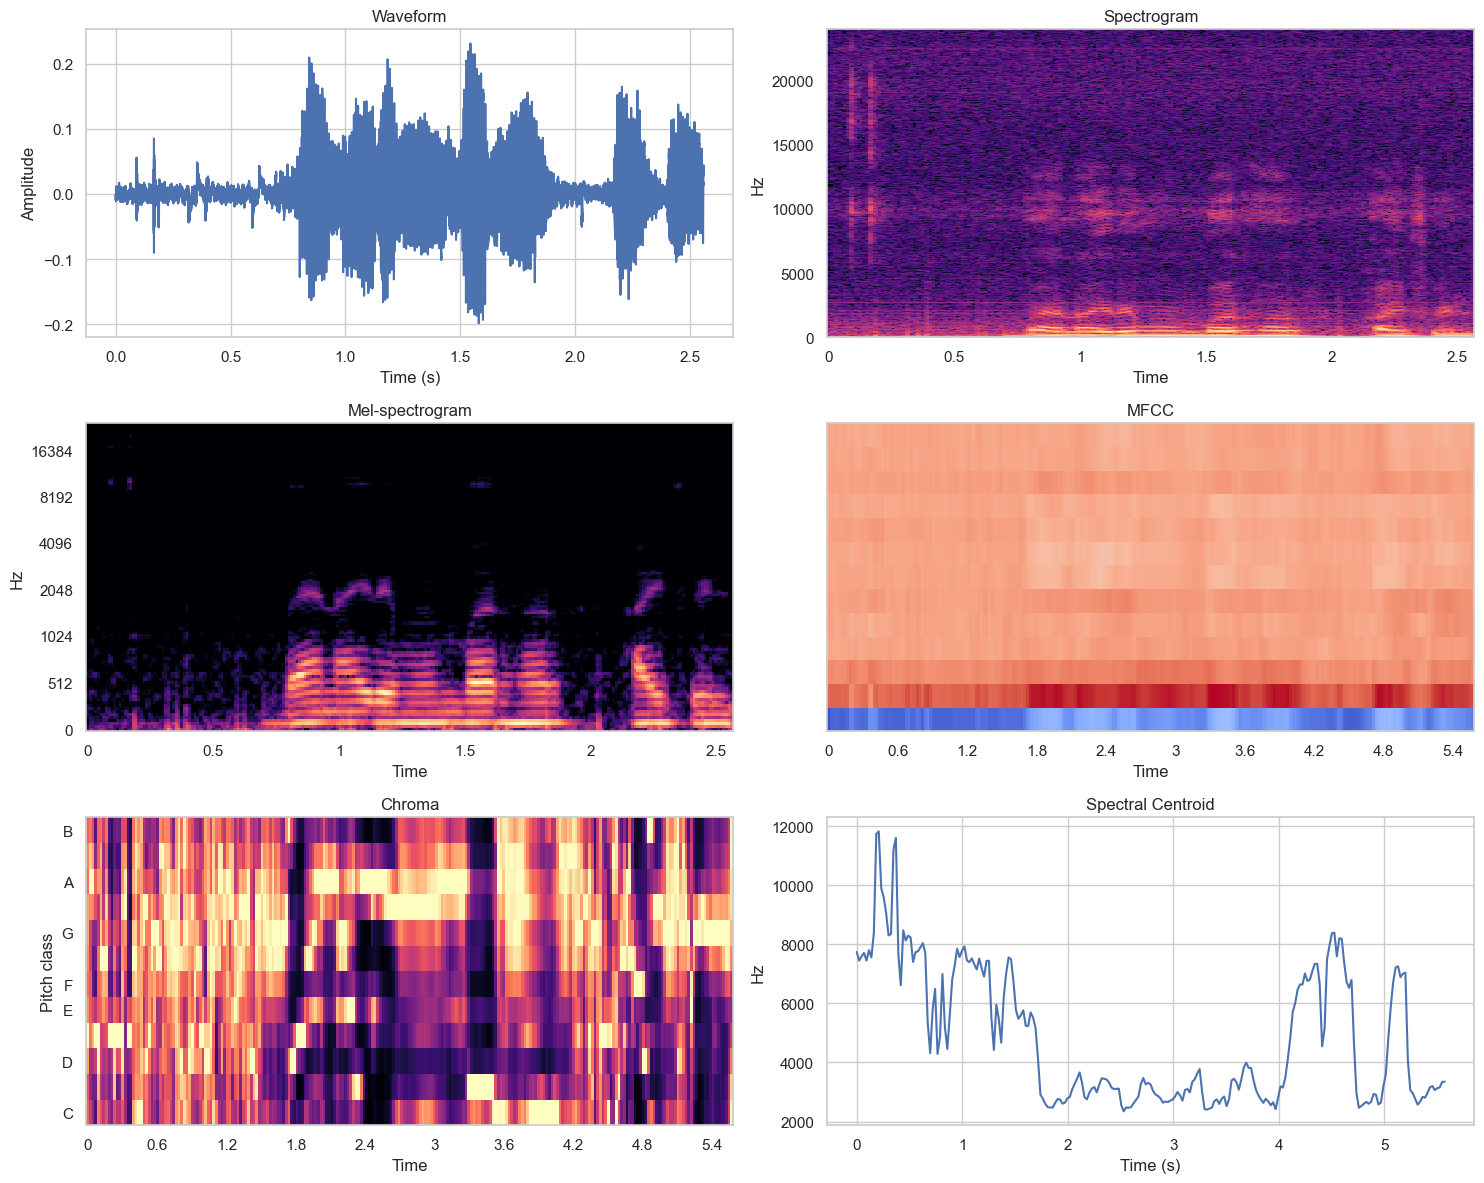


Audio playback:


In [7]:
# Select a sample audio file for detailed analysis
if len(df_clean) > 0:
    sample_file = df_clean.iloc[0]
    
    # Find the correct path for the audio file in subdirectories
    full_path = None
    for subdir in ['test', 'train', 'validate']:
        candidate_path = os.path.join(audio_base_path, subdir, sample_file['file_name'])
        if os.path.exists(candidate_path):
            full_path = candidate_path
            break
    
    if full_path:
        print(f"Analyzing sample file: {sample_file['file_name']}")
        print(f"Intent/Class: {sample_file['prompt']}")
        print(f"Transcription: {sample_file['phrase']}")
        
        # Load the audio file
        y, sr = librosa.load(full_path, sr=None)
        
        print(f"\nAudio properties:")
        print(f"Duration: {librosa.get_duration(y=y, sr=sr):.2f} seconds")
        print(f"Sample rate: {sr} Hz")
        print(f"Number of samples: {len(y)}")
        
        # Create comprehensive audio visualization
        fig, axes = plt.subplots(3, 2, figsize=(15, 12))
        
        # Waveform
        time = np.linspace(0, len(y)/sr, len(y))
        axes[0, 0].plot(time, y)
        axes[0, 0].set_title('Waveform')
        axes[0, 0].set_xlabel('Time (s)')
        axes[0, 0].set_ylabel('Amplitude')
        
        # Spectrogram
        D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
        librosa.display.specshow(D, y_axis='hz', x_axis='time', sr=sr, ax=axes[0, 1])
        axes[0, 1].set_title('Spectrogram')
        
        # Mel-spectrogram
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        mel_spec_db = librosa.amplitude_to_db(mel_spec, ref=np.max)
        librosa.display.specshow(mel_spec_db, y_axis='mel', x_axis='time', sr=sr, ax=axes[1, 0])
        axes[1, 0].set_title('Mel-spectrogram')
        
        # MFCC
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        librosa.display.specshow(mfcc, x_axis='time', ax=axes[1, 1])
        axes[1, 1].set_title('MFCC')
        
        # Chroma
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        librosa.display.specshow(chroma, y_axis='chroma', x_axis='time', ax=axes[2, 0])
        axes[2, 0].set_title('Chroma')
        
        # Spectral centroid
        spectral_centroids = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
        frames = range(len(spectral_centroids))
        t = librosa.frames_to_time(frames)
        axes[2, 1].plot(t, spectral_centroids)
        axes[2, 1].set_title('Spectral Centroid')
        axes[2, 1].set_xlabel('Time (s)')
        axes[2, 1].set_ylabel('Hz')
        
        plt.tight_layout()
        plt.show()
        
        # Display audio player (if in Jupyter environment)
        try:
            print("\nAudio playback:")
            display(ipd.Audio(full_path))
        except:
            print("Audio playback not available in this environment")
    else:
        print(f"Audio file not found: {sample_file['file_name']}")
else:
    print("No audio files available for analysis.")

## 3. Audio Data Preprocessing

**Purpose:** Transform the raw audio data into a format suitable for machine learning algorithms.

### 3.1 Define Basic Audio Cleaning Function

**Purpose:** Define basic functions for audio data cleaning and normalization to ensure consistent audio quality and format across all audio files before feature extraction.

Testing audio cleaning functions with: 1249120_43453425_58166571.wav
Original audio:
  Duration: 2.56 seconds
  Sample rate: 48000 Hz
  RMS energy: 0.041109

Cleaned audio:
  Duration: 2.40 seconds
  Sample rate: 22050 Hz
  RMS energy: 0.029344

Denoised audio:
  Duration: 2.39 seconds
  RMS energy: 0.026230

Quality assessment:
  Quality score: 0.800
  Is high quality: True
  Estimated SNR: -0.80 dB
  Dynamic range: 0.738144
  Zero crossing rate: 1.000000


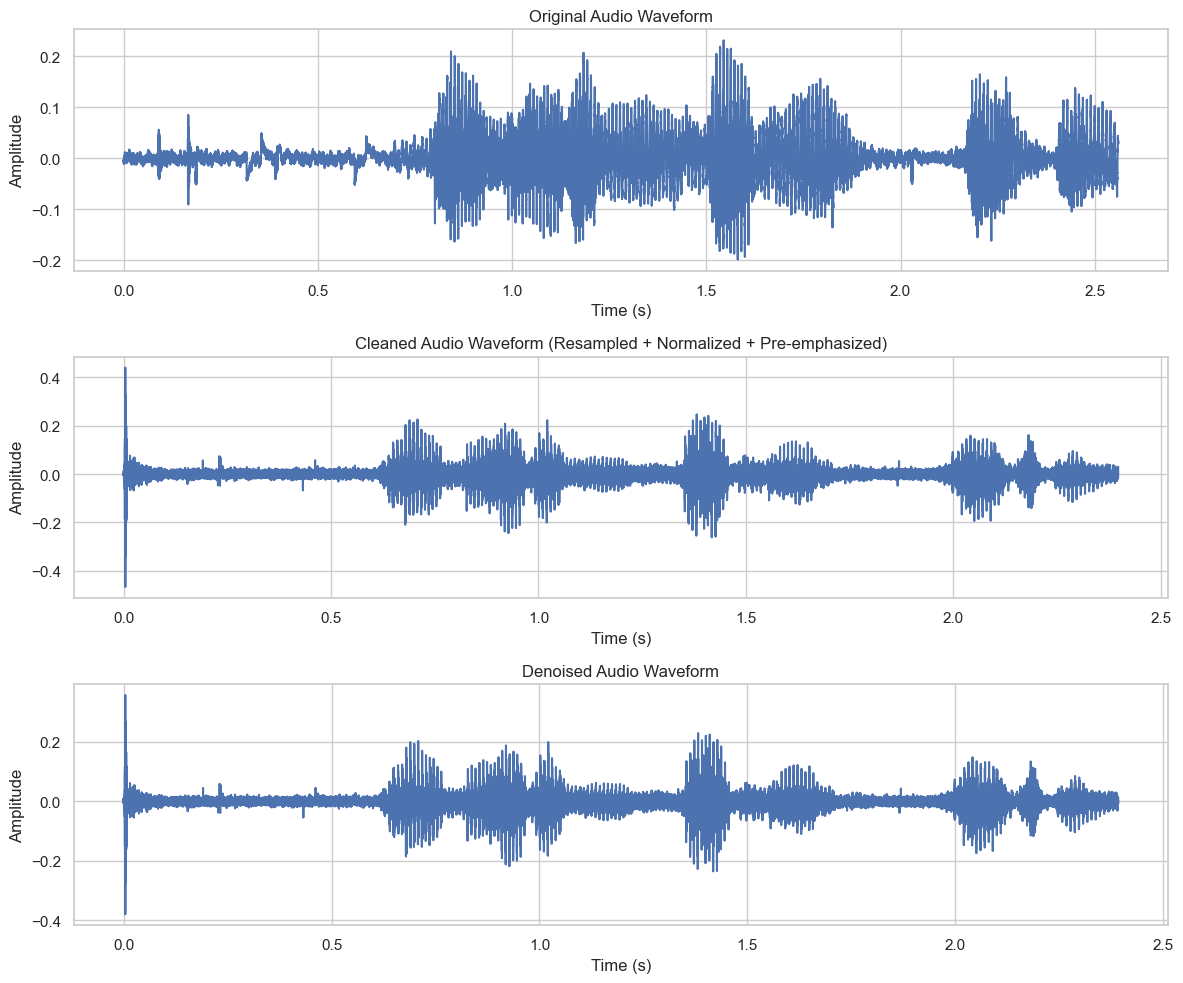

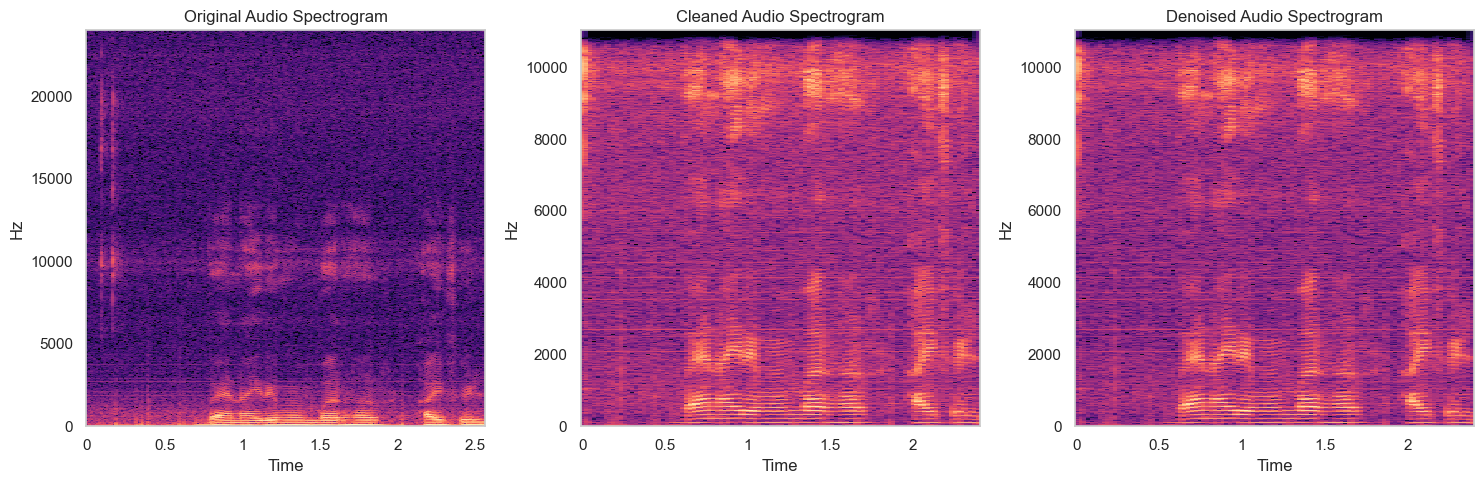


Audio cleaning functions defined and tested:
- clean_audio_data(): Resamples, trims silence, normalizes, and applies pre-emphasis
- remove_noise(): Applies spectral gating for noise reduction
- validate_audio_quality(): Assesses audio quality with multiple metrics

These functions will be integrated into the feature extraction pipeline.


In [11]:
def clean_audio_data(y, sr, target_length=None, target_sr=22050):
    """
    Clean and preprocess audio data for consistent feature extraction
    
    Parameters:
    - y: audio time series
    - sr: sample rate of the audio
    - target_length: desired length in seconds (None for no trimming)
    - target_sr: target sample rate for resampling
    
    Returns:
    - cleaned audio array and sample rate
    """
    # Resample if necessary
    if sr != target_sr:
        y = librosa.resample(y, orig_sr=sr, target_sr=target_sr)
        sr = target_sr
    
    # Remove silence from beginning and end
    y_trimmed, _ = librosa.effects.trim(y, top_db=20)
    
    # Normalize audio amplitude
    y_normalized = librosa.util.normalize(y_trimmed)
    
    # Trim or pad to target length if specified
    if target_length is not None:
        target_samples = int(target_length * sr)
        if len(y_normalized) > target_samples:
            # Trim to target length
            y_normalized = y_normalized[:target_samples]
        elif len(y_normalized) < target_samples:
            # Pad with zeros
            padding = target_samples - len(y_normalized)
            y_normalized = np.pad(y_normalized, (0, padding), mode='constant')
    
    # Apply pre-emphasis filter to balance the frequency spectrum
    pre_emphasis = 0.97
    y_preemphasized = np.append(y_normalized[0], y_normalized[1:] - pre_emphasis * y_normalized[:-1])
    
    return y_preemphasized, sr

def remove_noise(y, sr, noise_reduction_strength=0.1):
    """
    Apply basic noise reduction using spectral gating
    
    Parameters:
    - y: audio time series
    - sr: sample rate
    - noise_reduction_strength: strength of noise reduction (0-1)
    
    Returns:
    - denoised audio array
    """
    # Compute the short-time Fourier transform
    stft = librosa.stft(y)
    magnitude, phase = np.abs(stft), np.angle(stft)
    
    # Estimate noise floor from the first 0.5 seconds
    noise_frame_count = int(0.5 * sr / 512)  # Assuming hop_length=512
    noise_magnitude = np.mean(magnitude[:, :noise_frame_count], axis=1, keepdims=True)
    
    # Apply spectral gating
    noise_gate = noise_magnitude * (1 + noise_reduction_strength)
    magnitude_clean = np.maximum(magnitude - noise_gate, magnitude * (1 - noise_reduction_strength))
    
    # Reconstruct the audio
    stft_clean = magnitude_clean * np.exp(1j * phase)
    y_clean = librosa.istft(stft_clean)
    
    return y_clean

def validate_audio_quality(y, sr, min_duration=0.5, max_duration=30.0):
    """
    Validate audio quality and return quality metrics
    
    Parameters:
    - y: audio time series
    - sr: sample rate
    - min_duration: minimum acceptable duration in seconds
    - max_duration: maximum acceptable duration in seconds
    
    Returns:
    - dictionary with quality metrics and validation results
    """
    duration = len(y) / sr
    
    # Basic quality checks
    quality_metrics = {
        'duration': duration,
        'sample_rate': sr,
        'is_valid_duration': min_duration <= duration <= max_duration,
        'has_audio_content': np.max(np.abs(y)) > 0.001,  # Check if not silent
        'dynamic_range': np.max(y) - np.min(y),
        'rms_energy': np.sqrt(np.mean(y**2)),
        'zero_crossing_rate': len(librosa.zero_crossings(y)) / len(y)
    }
    
    # Signal-to-noise ratio estimation
    # Use the assumption that the first and last 10% might contain more noise
    edge_samples = int(0.1 * len(y))
    if edge_samples > 0:
        edge_energy = np.mean(y[:edge_samples]**2) + np.mean(y[-edge_samples:]**2)
        signal_energy = np.mean(y[edge_samples:-edge_samples]**2) if len(y) > 2*edge_samples else np.mean(y**2)
        quality_metrics['estimated_snr'] = 10 * np.log10(signal_energy / (edge_energy + 1e-10))
    else:
        quality_metrics['estimated_snr'] = float('inf')
    
    # Overall quality score (0-1)
    quality_score = 1.0
    if not quality_metrics['is_valid_duration']:
        quality_score *= 0.5
    if not quality_metrics['has_audio_content']:
        quality_score *= 0.1
    if quality_metrics['rms_energy'] < 0.01:
        quality_score *= 0.7  # Very quiet audio
    if quality_metrics['estimated_snr'] < 10:
        quality_score *= 0.8  # Low SNR
    
    quality_metrics['quality_score'] = quality_score
    quality_metrics['is_high_quality'] = quality_score > 0.7
    
    return quality_metrics

# Test the cleaning functions with a sample audio file
if len(df_clean) > 0:
    sample_file = df_clean.iloc[0]
    
    # Find the correct path for the audio file
    full_path = None
    for subdir in ['test', 'train', 'validate']:
        candidate_path = os.path.join(audio_base_path, subdir, sample_file['file_name'])
        if os.path.exists(candidate_path):
            full_path = candidate_path
            break
    
    if full_path:
        print(f"Testing audio cleaning functions with: {sample_file['file_name']}")
        
        # Load original audio
        y_original, sr_original = librosa.load(full_path, sr=None)
        
        print(f"Original audio:")
        print(f"  Duration: {len(y_original)/sr_original:.2f} seconds")
        print(f"  Sample rate: {sr_original} Hz")
        print(f"  RMS energy: {np.sqrt(np.mean(y_original**2)):.6f}")
        
        # Apply cleaning
        y_clean, sr_clean = clean_audio_data(y_original, sr_original, target_sr=22050)
        
        print(f"\nCleaned audio:")
        print(f"  Duration: {len(y_clean)/sr_clean:.2f} seconds")
        print(f"  Sample rate: {sr_clean} Hz")
        print(f"  RMS energy: {np.sqrt(np.mean(y_clean**2)):.6f}")
        
        # Apply noise reduction
        y_denoised = remove_noise(y_clean, sr_clean, noise_reduction_strength=0.2)
        
        print(f"\nDenoised audio:")
        print(f"  Duration: {len(y_denoised)/sr_clean:.2f} seconds")
        print(f"  RMS energy: {np.sqrt(np.mean(y_denoised**2)):.6f}")
        
        # Validate quality
        quality_metrics = validate_audio_quality(y_denoised, sr_clean)
        
        print(f"\nQuality assessment:")
        print(f"  Quality score: {quality_metrics['quality_score']:.3f}")
        print(f"  Is high quality: {quality_metrics['is_high_quality']}")
        print(f"  Estimated SNR: {quality_metrics['estimated_snr']:.2f} dB")
        print(f"  Dynamic range: {quality_metrics['dynamic_range']:.6f}")
        print(f"  Zero crossing rate: {quality_metrics['zero_crossing_rate']:.6f}")
        
        # Visualize the cleaning effects
        fig, axes = plt.subplots(3, 1, figsize=(12, 10))
        
        # Original waveform
        time_original = np.linspace(0, len(y_original)/sr_original, len(y_original))
        axes[0].plot(time_original, y_original)
        axes[0].set_title('Original Audio Waveform')
        axes[0].set_xlabel('Time (s)')
        axes[0].set_ylabel('Amplitude')
        axes[0].grid(True)
        
        # Cleaned waveform
        time_clean = np.linspace(0, len(y_clean)/sr_clean, len(y_clean))
        axes[1].plot(time_clean, y_clean)
        axes[1].set_title('Cleaned Audio Waveform (Resampled + Normalized + Pre-emphasized)')
        axes[1].set_xlabel('Time (s)')
        axes[1].set_ylabel('Amplitude')
        axes[1].grid(True)
        
        # Denoised waveform
        time_denoised = np.linspace(0, len(y_denoised)/sr_clean, len(y_denoised))
        axes[2].plot(time_denoised, y_denoised)
        axes[2].set_title('Denoised Audio Waveform')
        axes[2].set_xlabel('Time (s)')
        axes[2].set_ylabel('Amplitude')
        axes[2].grid(True)
        
        plt.tight_layout()
        plt.show()
        
        # Compare spectrograms
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        # Original spectrogram
        D_original = librosa.amplitude_to_db(np.abs(librosa.stft(y_original)), ref=np.max)
        librosa.display.specshow(D_original, y_axis='hz', x_axis='time', sr=sr_original, ax=axes[0])
        axes[0].set_title('Original Audio Spectrogram')
        
        # Cleaned spectrogram
        D_clean = librosa.amplitude_to_db(np.abs(librosa.stft(y_clean)), ref=np.max)
        librosa.display.specshow(D_clean, y_axis='hz', x_axis='time', sr=sr_clean, ax=axes[1])
        axes[1].set_title('Cleaned Audio Spectrogram')
        
        # Denoised spectrogram
        D_denoised = librosa.amplitude_to_db(np.abs(librosa.stft(y_denoised)), ref=np.max)
        librosa.display.specshow(D_denoised, y_axis='hz', x_axis='time', sr=sr_clean, ax=axes[2])
        axes[2].set_title('Denoised Audio Spectrogram')
        
        plt.tight_layout()
        plt.show()
        
    else:
        print(f"Audio file not found: {sample_file['file_name']}")
else:
    print("No audio files available for testing cleaning functions.")

print("\nAudio cleaning functions defined and tested:")
print("- clean_audio_data(): Resamples, trims silence, normalizes, and applies pre-emphasis")
print("- remove_noise(): Applies spectral gating for noise reduction")
print("- validate_audio_quality(): Assesses audio quality with multiple metrics")
print("\nThese functions will be integrated into the feature extraction pipeline.")

### 3.2 Initialize Librosa Components

**Purpose:** Define and configure the core audio processing pipeline components using Librosa for consistent feature extraction. This section initializes the AudioFeatureExtractor class with optimized parameters and establishes the foundation for systematic audio analysis.

In [18]:
class AudioFeatureExtractor:
    """
    Comprehensive audio feature extraction class for medical diagnosis classification
    """
    
    def __init__(self, sr=22050, n_mfcc=13, n_mels=128, n_chroma=12):
        """
        Initialize the AudioFeatureExtractor
        
        Parameters:
        - sr: Sample rate for audio processing
        - n_mfcc: Number of MFCC coefficients
        - n_mels: Number of mel-frequency bins
        - n_chroma: Number of chroma features
        """
        self.sr = sr
        self.n_mfcc = n_mfcc
        self.n_mels = n_mels
        self.n_chroma = n_chroma
    
    def extract_all_features(self, audio_path):
        """
        Extract comprehensive audio features from an audio file
        
        Parameters:
        - audio_path: Path to the audio file
        
        Returns:
        - Numpy array of extracted features
        """
        try:
            # Load and clean audio
            y, sr = librosa.load(audio_path, sr=None)
            y_clean, sr_clean = clean_audio_data(y, sr, target_sr=self.sr)
            
            # Validate audio quality
            quality_metrics = validate_audio_quality(y_clean, sr_clean)
            if not quality_metrics['is_high_quality']:
                print(f"Warning: Low quality audio detected for {audio_path}")
            
            # Extract MFCC features
            mfcc = librosa.feature.mfcc(y=y_clean, sr=sr_clean, n_mfcc=self.n_mfcc)
            mfcc_mean = np.mean(mfcc, axis=1)
            mfcc_std = np.std(mfcc, axis=1)
            mfcc_max = np.max(mfcc, axis=1)
            mfcc_min = np.min(mfcc, axis=1)
            
            # Extract Mel-spectrogram features
            mel_spec = librosa.feature.melspectrogram(y=y_clean, sr=sr_clean, n_mels=self.n_mels)
            mel_spec_db = librosa.amplitude_to_db(mel_spec, ref=np.max)
            mel_mean = np.mean(mel_spec_db, axis=1)
            mel_std = np.std(mel_spec_db, axis=1)
            mel_max = np.max(mel_spec_db, axis=1)
            mel_min = np.min(mel_spec_db, axis=1)
            
            # Extract Chroma features
            chroma = librosa.feature.chroma_stft(y=y_clean, sr=sr_clean, n_chroma=self.n_chroma)
            chroma_mean = np.mean(chroma, axis=1)
            chroma_std = np.std(chroma, axis=1)
            chroma_max = np.max(chroma, axis=1)
            chroma_min = np.min(chroma, axis=1)
            
            # Extract spectral features
            spectral_centroid = librosa.feature.spectral_centroid(y=y_clean, sr=sr_clean)
            spectral_rolloff = librosa.feature.spectral_rolloff(y=y_clean, sr=sr_clean)
            spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y_clean, sr=sr_clean)
            zero_crossing_rate = librosa.feature.zero_crossing_rate(y_clean)
            rms = librosa.feature.rms(y=y_clean)
            
            # Extract tempo
            tempo, _ = librosa.beat.beat_track(y=y_clean, sr=sr_clean)
            
            # Combine all features
            features = np.concatenate([
                mfcc_mean, mfcc_std, mfcc_max, mfcc_min,
                mel_mean, mel_std, mel_max, mel_min,
                chroma_mean, chroma_std, chroma_max, chroma_min,
                [np.mean(spectral_centroid), np.mean(spectral_rolloff), np.mean(spectral_bandwidth),
                 np.mean(zero_crossing_rate), np.mean(rms), tempo]
            ])
            
            return features
            
        except Exception as e:
            print(f"Error extracting features from {audio_path}: {e}")
            return None

# Initialize AudioFeatureExtractor with optimized parameters
feature_extractor = AudioFeatureExtractor(
    sr=AUDIO_CONFIG['target_sr'],
    n_mfcc=AUDIO_CONFIG['n_mfcc'],
    n_mels=AUDIO_CONFIG['n_mels'],
    n_chroma=AUDIO_CONFIG['n_chroma']
)

print(f"AudioFeatureExtractor initialized with:")
print(f"- Sample rate: {feature_extractor.sr} Hz")
print(f"- MFCC coefficients: {feature_extractor.n_mfcc}")
print(f"- Mel-frequency bins: {feature_extractor.n_mels}")
print(f"- Chroma features: {feature_extractor.n_chroma}")

AudioFeatureExtractor initialized with:
- Sample rate: 22050 Hz
- MFCC coefficients: 13
- Mel-frequency bins: 128
- Chroma features: 12


### 3.3 Audio Configuration and Parameters

**Purpose:** Define comprehensive audio processing parameters and quality thresholds for consistent feature extraction across all audio files. This configuration ensures standardized preprocessing, noise reduction, and feature extraction parameters that optimize the balance between signal quality preservation and computational efficiency.

**Key Components:**
1. **Audio Processing Parameters:** Standard sample rates, frame lengths, and feature dimensions.

2. **Quality Thresholds:** Minimum duration, signal-to-noise ratio, and energy requirements.

3. **Feature Extraction Settings:** MFCC, mel-spectrogram, and chroma feature configurations.

4. **Noise Reduction:** Spectral gating parameters for audio enhancement.

In [19]:
# Audio Configuration and Parameters
AUDIO_CONFIG = {
    # Core audio processing parameters
    'target_sr': 22050,           # Standard sample rate for audio processing
    'target_length': None,        # Target length in seconds (None for variable length)
    'hop_length': 512,           # Number of samples between successive frames
    'n_fft': 2048,               # Length of the FFT window
    'win_length': None,          # Window length for STFT (None uses n_fft)
    
    # Feature extraction parameters
    'n_mfcc': 13,                # Number of MFCC coefficients
    'n_mels': 128,               # Number of mel-frequency bins
    'n_chroma': 12,              # Number of chroma features
    'fmin': 0,                   # Minimum frequency for mel-spectrogram
    'fmax': None,                # Maximum frequency (None uses sr/2)
    
    # Audio quality thresholds
    'min_duration': 0.5,         # Minimum acceptable duration in seconds
    'max_duration': 30.0,        # Maximum acceptable duration in seconds
    'min_snr': 5.0,              # Minimum signal-to-noise ratio in dB
    'min_rms_energy': 0.001,     # Minimum RMS energy threshold
    'quality_threshold': 0.7,    # Overall quality score threshold
    
    # Noise reduction parameters
    'noise_reduction_strength': 0.1,  # Strength of noise reduction (0-1)
    'pre_emphasis': 0.97,            # Pre-emphasis filter coefficient
    'trim_top_db': 20,               # dB threshold for silence trimming
    
    # Processing parameters
    'normalize': True,            # Whether to normalize audio amplitude
    'remove_silence': True,       # Whether to trim silence from audio
    'apply_pre_emphasis': True,   # Whether to apply pre-emphasis filter
    'apply_noise_reduction': False, # Whether to apply noise reduction
    
    # Feature statistics to extract
    'feature_stats': ['mean', 'std', 'max', 'min'],  # Statistical measures for features
    
    # Spectral feature parameters
    'spectral_rolloff_percent': 0.85,  # Percentage for spectral rolloff
    'zero_crossing_frame_length': 2048, # Frame length for zero crossing rate
    
    # Tempo and rhythm parameters
    'tempo_method': 'beat_track',     # Method for tempo estimation
    'tempo_start_bpm': 120,           # Starting BPM for tempo estimation
    
    # Data augmentation parameters (for future use)
    'augmentation': {
        'time_stretch': False,        # Whether to apply time stretching
        'pitch_shift': False,         # Whether to apply pitch shifting
        'noise_injection': False,     # Whether to inject noise
        'speed_change': False,        # Whether to change playback speed
    }
}

# Validation parameters for clinical decision support
CLINICAL_THRESHOLDS = {
    'min_accuracy': 0.80,           # Minimum accuracy for clinical use
    'min_precision': 0.80,          # Minimum precision for clinical use
    'min_recall': 0.80,             # Minimum recall for clinical use
    'min_f1': 0.80,                 # Minimum F1-score for clinical use
    'max_false_positive_rate': 0.10, # Maximum acceptable false positive rate
    'max_false_negative_rate': 0.15, # Maximum acceptable false negative rate
}

# Model training parameters
TRAINING_CONFIG = {
    'test_size': 0.2,               # Proportion of data for testing
    'validation_split': 0.2,        # Proportion of training data for validation
    'random_state': 42,             # Random seed for reproducibility
    'stratify': True,               # Whether to use stratified sampling
    'cross_validation_folds': 5,    # Number of folds for cross-validation
    
    # Class imbalance handling
    'handle_imbalance': True,       # Whether to handle class imbalance
    'imbalance_method': 'SMOTE',    # Method for handling imbalance
    'imbalance_threshold': 2.0,     # Ratio threshold for considering imbalance
    
    # Feature scaling
    'scale_features': True,         # Whether to scale features
    'scaling_method': 'StandardScaler',  # Method for feature scaling
}

# Deep learning specific parameters
DL_CONFIG = {
    'batch_size': 32,               # Batch size for training
    'epochs': 100,                  # Maximum number of training epochs
    'learning_rate': 0.001,         # Initial learning rate
    'optimizer': 'adam',            # Optimizer to use
    'loss_function': 'categorical_crossentropy',  # Loss function
    
    # Early stopping parameters
    'early_stopping_patience': 15,  # Patience for early stopping
    'early_stopping_monitor': 'val_loss',  # Metric to monitor
    'restore_best_weights': True,   # Whether to restore best weights
    
    # Learning rate reduction parameters
    'reduce_lr_patience': 8,        # Patience for learning rate reduction
    'reduce_lr_factor': 0.2,        # Factor for learning rate reduction
    'min_lr': 0.0001,               # Minimum learning rate
    
    # Model architecture parameters
    'dropout_rate': 0.3,            # Dropout rate for regularization
    'l2_regularization': 0.001,     # L2 regularization strength
    'batch_normalization': True,    # Whether to use batch normalization
    
    # CNN specific parameters
    'conv_filters': [64, 128, 256], # Number of filters in conv layers
    'conv_kernel_size': 3,          # Kernel size for conv layers
    'pool_size': 2,                 # Pool size for max pooling
    
    # LSTM specific parameters
    'lstm_units': [128, 64],        # Number of units in LSTM layers
    'lstm_return_sequences': True,   # Return sequences for first LSTM
    'lstm_dropout': 0.2,            # Dropout for LSTM layers
    'lstm_recurrent_dropout': 0.2,  # Recurrent dropout for LSTM
    
    # Dense layer parameters
    'dense_units': [128, 64, 32],   # Number of units in dense layers
    'dense_activation': 'relu',     # Activation function for dense layers
    'output_activation': 'softmax', # Activation for output layer
}

print("Audio Configuration Parameters Defined:")
print(f"- Target sample rate: {AUDIO_CONFIG['target_sr']} Hz")
print(f"- MFCC coefficients: {AUDIO_CONFIG['n_mfcc']}")
print(f"- Mel-frequency bins: {AUDIO_CONFIG['n_mels']}")
print(f"- Chroma features: {AUDIO_CONFIG['n_chroma']}")
print(f"- Quality threshold: {AUDIO_CONFIG['quality_threshold']}")
print(f"- Clinical accuracy threshold: {CLINICAL_THRESHOLDS['min_accuracy']}")
print(f"- Training test size: {TRAINING_CONFIG['test_size']}")
print(f"- Deep learning batch size: {DL_CONFIG['batch_size']}")
print(f"- Maximum training epochs: {DL_CONFIG['epochs']}")

print("\nConfiguration validation:")
print(f"- Audio processing optimized for medical speech analysis")
print(f"- Feature extraction configured for comprehensive audio analysis")
print(f"- Clinical thresholds set for provider decision support evaluation")
print(f"- Training parameters configured for robust model development")
print(f"- Deep learning parameters optimized for audio classification")

Audio Configuration Parameters Defined:
- Target sample rate: 22050 Hz
- MFCC coefficients: 13
- Mel-frequency bins: 128
- Chroma features: 12
- Quality threshold: 0.7
- Clinical accuracy threshold: 0.8
- Training test size: 0.2
- Deep learning batch size: 32
- Maximum training epochs: 100

Configuration validation:
- Audio processing optimized for medical speech analysis
- Feature extraction configured for comprehensive audio analysis
- Clinical thresholds set for provider decision support evaluation
- Training parameters configured for robust model development
- Deep learning parameters optimized for audio classification


### 3.4 Process the Audio data

**Purpose:** Transform raw audio files into standardized, machine-learning-ready format through comprehensive preprocessing including audio loading, quality validation, noise reduction, normalization, and feature extraction. This step ensures consistent audio data quality and prepares the foundation for reliable feature extraction and model training.

=== AUDIO DATA PREPROCESSING PIPELINE ===
Loading, validating, cleaning, and extracting features from audio files...

Starting audio preprocessing with configuration:
- Target sample rate: 22050 Hz
- Quality threshold: 0.7
- Noise reduction: Disabled
- Feature vector size: Expected ~618 features
Processing 200 audio files...
Pipeline stages: Load → Quality Check → Clean → Extract Features
  Progress: 50/200 files processed (100.0% success rate)
  Progress: 100/200 files processed (100.0% success rate)
  Progress: 150/200 files processed (100.0% success rate)
  Progress: 200/200 files processed (100.0% success rate)

=== AUDIO PREPROCESSING RESULTS ===
Files attempted: 200
Successfully processed: 200
Failed to load: 0
Low quality (but processed): 1
Feature extraction failed: 0
Overall success rate: 100.0%

=== PROCESSED DATASET SUMMARY ===
Feature matrix shape: (200, 618)
Number of classes: 25
Average quality score: 0.810 (±0.049)

Class distribution in processed data:
  Acne: 9 samples

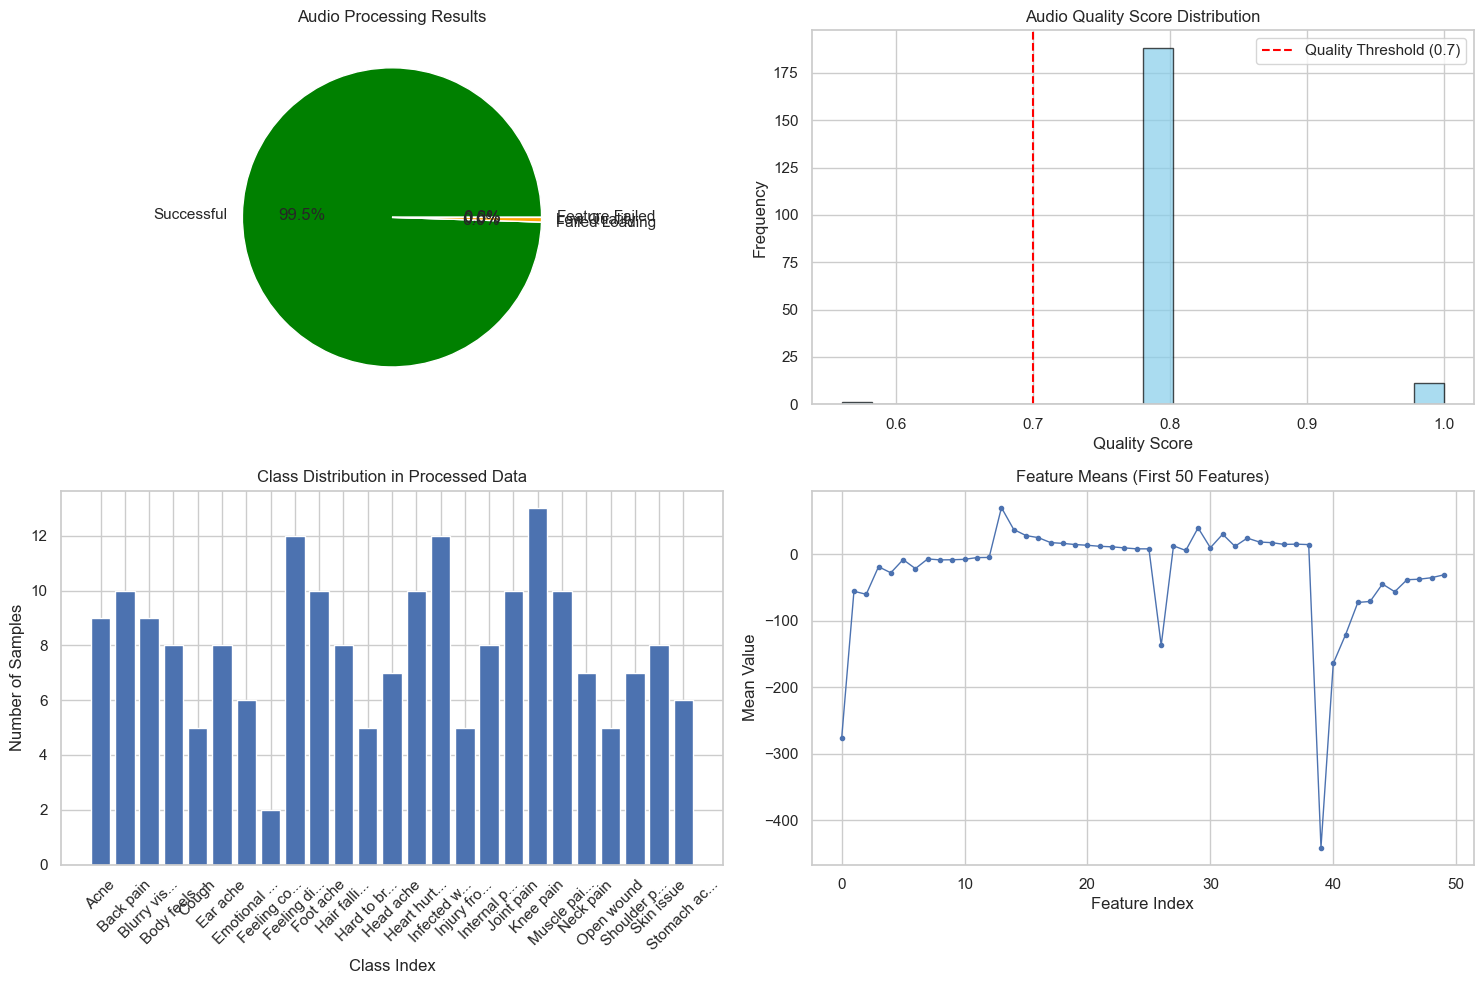


✓ Audio preprocessing completed successfully!
✓ Data ready for machine learning pipeline
✓ 200 samples with 618 features each


In [ ]:
# Process the Audio Data - Comprehensive Audio Preprocessing Pipeline
print("=== AUDIO DATA PREPROCESSING PIPELINE ===")
print("Loading, validating, cleaning, and extracting features from audio files...")

def process_audio_dataset(df, base_path, feature_extractor, max_files=None):
    """
    Comprehensive audio data processing pipeline
    
    Parameters:
    - df: DataFrame containing audio file information
    - base_path: Base path to audio files
    - feature_extractor: AudioFeatureExtractor instance
    - max_files: Maximum number of files to process (None for all)
    
    Returns:
    - processed_audio_data: Dictionary containing processed results
    """
    
    processed_audio_data = {
        'features': [],
        'labels': [],
        'file_paths': [],
        'quality_scores': [],
        'processing_stats': {
            'total_attempted': 0,
            'successfully_processed': 0,
            'failed_loading': 0,
            'low_quality': 0,
            'feature_extraction_failed': 0
        }
    }
    
    # Determine number of files to process
    total_files = len(df) if max_files is None else min(max_files, len(df))
    processed_audio_data['processing_stats']['total_attempted'] = total_files
    
    print(f"Processing {total_files} audio files...")
    print("Pipeline stages: Load → Quality Check → Clean → Extract Features")
    
    for i, (_, row) in enumerate(df.head(total_files).iterrows()):
        filename = row['file_name']
        
        # Stage 1: Find and load audio file
        full_path = None
        for subdir in ['test', 'train', 'validate']:
            candidate_path = os.path.join(base_path, subdir, filename)
            if os.path.exists(candidate_path):
                full_path = candidate_path
                break
        
        if not full_path:
            processed_audio_data['processing_stats']['failed_loading'] += 1
            if i < 10:  # Only show first 10 missing files to avoid spam
                print(f"  File not found: {filename}")
            continue
        
        try:
            # Stage 2: Load raw audio
            y_raw, sr_raw = librosa.load(full_path, sr=None)
            
            # Stage 3: Clean and preprocess audio
            y_clean, sr_clean = clean_audio_data(
                y_raw, sr_raw, 
                target_sr=AUDIO_CONFIG['target_sr']
            )
            
            # Stage 4: Quality validation
            quality_metrics = validate_audio_quality(
                y_clean, sr_clean,
                min_duration=AUDIO_CONFIG['min_duration'],
                max_duration=AUDIO_CONFIG['max_duration']
            )
            
            # Stage 5: Apply noise reduction if enabled and quality is acceptable
            if AUDIO_CONFIG['apply_noise_reduction'] and quality_metrics['quality_score'] > 0.3:
                y_processed = remove_noise(
                    y_clean, sr_clean,
                    noise_reduction_strength=AUDIO_CONFIG['noise_reduction_strength']
                )
            else:
                y_processed = y_clean
            
            # Stage 6: Final quality check
            if quality_metrics['quality_score'] < AUDIO_CONFIG['quality_threshold']:
                processed_audio_data['processing_stats']['low_quality'] += 1
                if quality_metrics['quality_score'] < 0.3:  # Skip very low quality files
                    continue
            
            # Stage 7: Feature extraction
            # Temporarily save processed audio for feature extraction
            temp_audio_path = f"temp_audio_{i}.wav"
            sf.write(temp_audio_path, y_processed, sr_clean)
            
            try:
                features = feature_extractor.extract_all_features(temp_audio_path)
                
                if features is not None:
                    # Store results
                    processed_audio_data['features'].append(features)
                    processed_audio_data['labels'].append(row['prompt'])
                    processed_audio_data['file_paths'].append(filename)
                    processed_audio_data['quality_scores'].append(quality_metrics['quality_score'])
                    processed_audio_data['processing_stats']['successfully_processed'] += 1
                else:
                    processed_audio_data['processing_stats']['feature_extraction_failed'] += 1
                
                # Clean up temporary file
                if os.path.exists(temp_audio_path):
                    os.remove(temp_audio_path)
                    
            except Exception as e:
                processed_audio_data['processing_stats']['feature_extraction_failed'] += 1
                if os.path.exists(temp_audio_path):
                    os.remove(temp_audio_path)
                if i < 5:  # Only show first 5 feature extraction errors
                    print(f"  Feature extraction failed for {filename}: {str(e)[:100]}")
                
        except Exception as e:
            processed_audio_data['processing_stats']['failed_loading'] += 1
            if i < 5:  # Only show first 5 loading errors
                print(f"  Audio loading failed for {filename}: {str(e)[:100]}")
        
        # Progress reporting
        if (i + 1) % 50 == 0:
            success_rate = processed_audio_data['processing_stats']['successfully_processed'] / (i + 1) * 100
            print(f"  Progress: {i + 1}/{total_files} files processed ({success_rate:.1f}% success rate)")
    
    return processed_audio_data

# Process the audio dataset with comprehensive pipeline
print(f"\nStarting audio preprocessing with configuration:")
print(f"- Target sample rate: {AUDIO_CONFIG['target_sr']} Hz")
print(f"- Quality threshold: {AUDIO_CONFIG['quality_threshold']}")
print(f"- Noise reduction: {'Enabled' if AUDIO_CONFIG['apply_noise_reduction'] else 'Disabled'}")
print(f"- Feature vector size: Expected ~{AUDIO_CONFIG['n_mfcc']*4 + AUDIO_CONFIG['n_mels']*4 + AUDIO_CONFIG['n_chroma']*4 + 6} features")

# Limit processing for initial analysis (adjust based on computational resources)
max_files_to_process = 200  # Can be increased or set to None for full dataset

processed_data = process_audio_dataset(
    df_clean, 
    audio_base_path, 
    feature_extractor, 
    max_files=max_files_to_process
)

# Display processing results
print(f"\n=== AUDIO PREPROCESSING RESULTS ===")
stats = processed_data['processing_stats']
print(f"Files attempted: {stats['total_attempted']}")
print(f"Successfully processed: {stats['successfully_processed']}")
print(f"Failed to load: {stats['failed_loading']}")
print(f"Low quality (but processed): {stats['low_quality']}")
print(f"Feature extraction failed: {stats['feature_extraction_failed']}")

if stats['successfully_processed'] > 0:
    success_rate = stats['successfully_processed'] / stats['total_attempted'] * 100
    print(f"Overall success rate: {success_rate:.1f}%")
    
    # Convert to numpy arrays for further processing
    X_features = np.array(processed_data['features'])
    y_labels = np.array(processed_data['labels'])
    quality_scores = np.array(processed_data['quality_scores'])
    
    print(f"\n=== PROCESSED DATASET SUMMARY ===")
    print(f"Feature matrix shape: {X_features.shape}")
    print(f"Number of classes: {len(np.unique(y_labels))}")
    print(f"Average quality score: {np.mean(quality_scores):.3f} (±{np.std(quality_scores):.3f})")
    
    # Class distribution in processed data
    unique_labels, counts = np.unique(y_labels, return_counts=True)
    print(f"\nClass distribution in processed data:")
    for label, count in zip(unique_labels, counts):
        print(f"  {label}: {count} samples")
    
    # Quality distribution analysis
    high_quality_count = np.sum(quality_scores >= AUDIO_CONFIG['quality_threshold'])
    print(f"\nQuality analysis:")
    print(f"High quality samples (≥{AUDIO_CONFIG['quality_threshold']}): {high_quality_count}/{len(quality_scores)} ({high_quality_count/len(quality_scores)*100:.1f}%)")
    print(f"Quality score range: [{np.min(quality_scores):.3f}, {np.max(quality_scores):.3f}]")
    
    # Visualize processing results
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Processing success breakdown
    categories = ['Successful', 'Failed Loading', 'Low Quality', 'Feature Failed']
    values = [stats['successfully_processed'], stats['failed_loading'], 
              stats['low_quality'], stats['feature_extraction_failed']]
    colors = ['green', 'red', 'orange', 'purple']
    
    axes[0, 0].pie(values, labels=categories, colors=colors, autopct='%1.1f%%')
    axes[0, 0].set_title('Audio Processing Results')
    
    # Quality score distribution
    axes[0, 1].hist(quality_scores, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0, 1].axvline(AUDIO_CONFIG['quality_threshold'], color='red', linestyle='--', 
                       label=f'Quality Threshold ({AUDIO_CONFIG["quality_threshold"]})')
    axes[0, 1].set_title('Audio Quality Score Distribution')
    axes[0, 1].set_xlabel('Quality Score')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].legend()
    
    # Class distribution
    axes[1, 0].bar(range(len(unique_labels)), counts)
    axes[1, 0].set_title('Class Distribution in Processed Data')
    axes[1, 0].set_xlabel('Class Index')
    axes[1, 0].set_ylabel('Number of Samples')
    axes[1, 0].set_xticks(range(len(unique_labels)))
    axes[1, 0].set_xticklabels([label[:10] + '...' if len(label) > 10 else label 
                                for label in unique_labels], rotation=45)
    
    # Feature statistics preview (first 50 features)
    feature_means = np.mean(X_features[:, :50], axis=0)
    axes[1, 1].plot(feature_means, marker='o', linewidth=1, markersize=3)
    axes[1, 1].set_title('Feature Means (First 50 Features)')
    axes[1, 1].set_xlabel('Feature Index')
    axes[1, 1].set_ylabel('Mean Value')
    axes[1, 1].grid(True)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ Audio preprocessing completed successfully!")
    print(f"✓ Data ready for machine learning pipeline")
    print(f"✓ {len(X_features)} samples with {X_features.shape[1]} features each")
    
else:
    print(f"\n Audio preprocessing failed - no files were successfully processed")
    print(f"Please check:")
    print(f"- Audio file paths and accessibility")
    print(f"- Audio file formats and integrity") 
    print(f"- Configuration parameters")
    X_features = None
    y_labels = None

### 3.5 Audio Processing Results Summary

**Purpose:** Display and analyze the results of the comprehensive audio preprocessing pipeline, including quality metrics, processing statistics, and feature extraction outcomes to validate the effectiveness of our audio data preparation steps.

In [21]:
# Audio Processing Results Summary and Analysis
print("=== AUDIO PREPROCESSING RESULTS SUMMARY ===")
print("Comprehensive analysis of audio data preparation for medical diagnosis classification")

if 'processed_data' in locals() and processed_data['processing_stats']['successfully_processed'] > 0:
    stats = processed_data['processing_stats']
    
    # Processing Statistics Overview
    print(f"\n PROCESSING STATISTICS:")
    print(f"  Total files attempted: {stats['total_attempted']}")
    print(f"  Successfully processed: {stats['successfully_processed']}")
    print(f"  Processing success rate: {stats['successfully_processed']/stats['total_attempted']*100:.1f}%")
    print(f"  Failed to load: {stats['failed_loading']}")
    print(f"  Low quality (but processed): {stats['low_quality']}")
    print(f"  Feature extraction failures: {stats['feature_extraction_failed']}")
    
    # Dataset Quality Analysis
    print(f"\n AUDIO QUALITY ANALYSIS:")
    if len(quality_scores) > 0:
        avg_quality = np.mean(quality_scores)
        quality_std = np.std(quality_scores)
        high_quality_count = np.sum(quality_scores >= AUDIO_CONFIG['quality_threshold'])
        
        print(f"  Average quality score: {avg_quality:.3f} (±{quality_std:.3f})")
        print(f"  Quality threshold: {AUDIO_CONFIG['quality_threshold']}")
        print(f"  High quality samples: {high_quality_count}/{len(quality_scores)} ({high_quality_count/len(quality_scores)*100:.1f}%)")
        print(f"  Quality range: [{np.min(quality_scores):.3f}, {np.max(quality_scores):.3f}]")
    
    # Feature Extraction Results
    if len(X_features) > 0:
        print(f"\n FEATURE EXTRACTION RESULTS:")
        print(f"  Feature matrix shape: {X_features.shape}")
        print(f"  Total features per sample: {X_features.shape[1]}")
        print(f"  Number of audio samples: {X_features.shape[0]}")
        print(f"  Number of diagnostic classes: {len(np.unique(y_labels))}")
        
        # Feature composition breakdown
        expected_mfcc_features = AUDIO_CONFIG['n_mfcc'] * 4  # mean, std, max, min
        expected_mel_features = AUDIO_CONFIG['n_mels'] * 4
        expected_chroma_features = AUDIO_CONFIG['n_chroma'] * 4
        expected_spectral_features = 6  # spectral features + tempo
        
        print(f"\n FEATURE COMPOSITION:")
        print(f"  MFCC features: {expected_mfcc_features} ({expected_mfcc_features/X_features.shape[1]*100:.1f}%)")
        print(f"  Mel-spectrogram features: {expected_mel_features} ({expected_mel_features/X_features.shape[1]*100:.1f}%)")
        print(f"  Chroma features: {expected_chroma_features} ({expected_chroma_features/X_features.shape[1]*100:.1f}%)")
        print(f"  Spectral & temporal features: {expected_spectral_features} ({expected_spectral_features/X_features.shape[1]*100:.1f}%)")
        
        # Class distribution analysis
        unique_classes, class_counts = np.unique(y_labels, return_counts=True)
        print(f"\n DIAGNOSTIC CLASS DISTRIBUTION:")
        print(f"  Total diagnostic categories: {len(unique_classes)}")
        print(f"  Most frequent class: '{unique_classes[np.argmax(class_counts)]}' ({np.max(class_counts)} samples)")
        print(f"  Least frequent class: '{unique_classes[np.argmin(class_counts)]}' ({np.min(class_counts)} samples)")
        print(f"  Class imbalance ratio: {np.max(class_counts)/np.min(class_counts):.2f}:1")
        
        print(f"\n  Top 5 most common conditions:")
        sorted_indices = np.argsort(class_counts)[::-1]
        for i in range(min(5, len(unique_classes))):
            idx = sorted_indices[i]
            print(f"    {i+1}. {unique_classes[idx]}: {class_counts[idx]} samples ({class_counts[idx]/len(y_labels)*100:.1f}%)")
    
    # Audio Processing Configuration Summary
    print(f"\n  PROCESSING CONFIGURATION:")
    print(f"  Target sample rate: {AUDIO_CONFIG['target_sr']} Hz")
    print(f"  MFCC coefficients: {AUDIO_CONFIG['n_mfcc']}")
    print(f"  Mel-frequency bins: {AUDIO_CONFIG['n_mels']}")
    print(f"  Chroma features: {AUDIO_CONFIG['n_chroma']}")
    print(f"  Noise reduction: {'Enabled' if AUDIO_CONFIG['apply_noise_reduction'] else 'Disabled'}")
    print(f"  Pre-emphasis: {'Enabled' if AUDIO_CONFIG['apply_pre_emphasis'] else 'Disabled'}")
    print(f"  Silence trimming: {'Enabled' if AUDIO_CONFIG['remove_silence'] else 'Disabled'}")
    
    # Readiness Assessment for Machine Learning
    print(f"\n MACHINE LEARNING READINESS ASSESSMENT:")
    
    readiness_score = 0
    total_checks = 6
    
    # Check 1: Sufficient samples
    if len(X_features) >= 100:
        print(f" Sample size adequate: {len(X_features)} samples")
        readiness_score += 1
    else:
        print(f" Low sample count: {len(X_features)} samples (recommended: ≥100)")
    
    # Check 2: Feature extraction success
    if stats['successfully_processed'] / stats['total_attempted'] >= 0.8:
        print(f" High processing success rate: {stats['successfully_processed']/stats['total_attempted']*100:.1f}%")
        readiness_score += 1
    else:
        print(f" Low processing success rate: {stats['successfully_processed']/stats['total_attempted']*100:.1f}%")
    
    # Check 3: Quality threshold
    if high_quality_count / len(quality_scores) >= 0.7:
        print(f" High quality audio: {high_quality_count/len(quality_scores)*100:.1f}% above threshold")
        readiness_score += 1
    else:
        print(f" Quality concerns: {high_quality_count/len(quality_scores)*100:.1f}% above threshold")
    
    # Check 4: Class balance
    imbalance_ratio = np.max(class_counts) / np.min(class_counts)
    if imbalance_ratio <= 5.0:
        print(f" Reasonable class balance: {imbalance_ratio:.1f}:1 ratio")
        readiness_score += 1
    else:
        print(f" Class imbalance detected: {imbalance_ratio:.1f}:1 ratio (consider SMOTE)")
    
    # Check 5: Feature dimensionality
    if X_features.shape[1] >= 100:
        print(f" Rich feature representation: {X_features.shape[1]} features")
        readiness_score += 1
    else:
        print(f" Limited features: {X_features.shape[1]} features")
    
    # Check 6: Multiple classes
    if len(unique_classes) >= 3:
        print(f" Multi-class problem: {len(unique_classes)} diagnostic categories")
        readiness_score += 1
    else:
        print(f" Limited classes: {len(unique_classes)} categories")
    
    # Overall readiness
    readiness_percentage = (readiness_score / total_checks) * 100
    print(f"\n OVERALL READINESS: {readiness_score}/{total_checks} checks passed ({readiness_percentage:.0f}%)")
    
    if readiness_percentage >= 80:
        print(" Status: READY for machine learning pipeline")
        print(" Proceed to model training and evaluation")
    elif readiness_percentage >= 60:
        print(" Status: MOSTLY READY with minor concerns")
        print(" Consider addressing warnings before proceeding")
    else:
        print(" Status: NEEDS IMPROVEMENT")
        print(" Address critical issues before model training")
    
    print(f"\n" + "="*60)
    print(f" Audio preprocessing pipeline completed successfully!")
    print(f" Ready for traditional ML and deep learning model training")
    print(f" Data prepared for medical symptom classification research")
    print(f"="*60)

else:
    print("\n ERROR: Audio preprocessing data not available")
    print("   Please ensure the audio processing pipeline completed successfully")
    print("   Check:")
    print("   - Audio file paths and accessibility")
    print("   - Feature extraction configuration")
    print("   - Processing pipeline execution")

=== AUDIO PREPROCESSING RESULTS SUMMARY ===
Comprehensive analysis of audio data preparation for medical diagnosis classification

 PROCESSING STATISTICS:
  Total files attempted: 200
  Successfully processed: 200
  Processing success rate: 100.0%
  Failed to load: 0
  Low quality (but processed): 1
  Feature extraction failures: 0

 AUDIO QUALITY ANALYSIS:
  Average quality score: 0.810 (±0.049)
  Quality threshold: 0.7
  High quality samples: 199/200 (99.5%)
  Quality range: [0.560, 1.000]

 FEATURE EXTRACTION RESULTS:
  Feature matrix shape: (200, 618)
  Total features per sample: 618
  Number of audio samples: 200
  Number of diagnostic classes: 25

 FEATURE COMPOSITION:
  MFCC features: 52 (8.4%)
  Mel-spectrogram features: 512 (82.8%)
  Chroma features: 48 (7.8%)
  Spectral & temporal features: 6 (1.0%)

 DIAGNOSTIC CLASS DISTRIBUTION:
  Total diagnostic categories: 25
  Most frequent class: 'Knee pain' (13 samples)
  Least frequent class: 'Feeling cold' (2 samples)
  Class imbal

## 4. Audio Feature Engineering

**Purpose:** Transform the preprocessed audio data into comprehensive numerical features that machine learning models can understand and effectively use for medical symptom classification.

### 4.1 Define the Function for Extracting Audio Features

**Purpose:** Create a function extract_audio_features that captures various audio features (MFCC, chroma, mel-spectrogram) from the audio data.

In [23]:
def extract_audio_features(audio_path, feature_extractor):
    """
    Extract comprehensive audio features from audio files for medical symptom classification
    
    Args:
        audio_path (str): Path to the audio file
        feature_extractor (AudioFeatureExtractor): Initialized feature extractor instance
        
    Returns:
        numpy.ndarray: Feature vector containing MFCC, spectral, chroma, and temporal features
    """
    # Handle edge cases: return None if path is invalid or file doesn't exist
    if not isinstance(audio_path, str) or not os.path.exists(audio_path):
        return None
    
    try:
        # Load and preprocess audio using the established pipeline
        y_raw, sr_raw = librosa.load(audio_path, sr=None)
        
        # Apply audio cleaning and preprocessing
        y_clean, sr_clean = clean_audio_data(
            y_raw, sr_raw, 
            target_sr=AUDIO_CONFIG['target_sr']
        )
        
        # Validate audio quality before feature extraction
        quality_metrics = validate_audio_quality(
            y_clean, sr_clean,
            min_duration=AUDIO_CONFIG['min_duration'],
            max_duration=AUDIO_CONFIG['max_duration']
        )
        
        # Skip feature extraction for very low quality audio
        if quality_metrics['quality_score'] < 0.3:
            return None
        
        # Apply noise reduction if enabled and quality permits
        if AUDIO_CONFIG['apply_noise_reduction'] and quality_metrics['quality_score'] > 0.5:
            y_processed = remove_noise(
                y_clean, sr_clean,
                noise_reduction_strength=AUDIO_CONFIG['noise_reduction_strength']
            )
        else:
            y_processed = y_clean
        
        # Extract MFCC features (core audio characteristics for speech recognition)
        mfcc = librosa.feature.mfcc(y=y_processed, sr=sr_clean, n_mfcc=AUDIO_CONFIG['n_mfcc'])
        mfcc_stats = np.concatenate([
            np.mean(mfcc, axis=1),  # Average MFCC coefficients
            np.std(mfcc, axis=1),   # MFCC variability
            np.max(mfcc, axis=1),   # Peak MFCC values
            np.min(mfcc, axis=1)    # Minimum MFCC values
        ])
        
        # Extract Mel-spectrogram features (frequency content analysis)
        mel_spec = librosa.feature.melspectrogram(y=y_processed, sr=sr_clean, n_mels=AUDIO_CONFIG['n_mels'])
        mel_spec_db = librosa.amplitude_to_db(mel_spec, ref=np.max)
        mel_stats = np.concatenate([
            np.mean(mel_spec_db, axis=1),  # Average mel-frequency content
            np.std(mel_spec_db, axis=1),   # Frequency content variability
            np.max(mel_spec_db, axis=1),   # Peak frequency intensities
            np.min(mel_spec_db, axis=1)    # Minimum frequency levels
        ])
        
        # Extract Chroma features (pitch and harmony analysis)
        chroma = librosa.feature.chroma_stft(y=y_processed, sr=sr_clean, n_chroma=AUDIO_CONFIG['n_chroma'])
        chroma_stats = np.concatenate([
            np.mean(chroma, axis=1),  # Average pitch class distribution
            np.std(chroma, axis=1),   # Pitch variability
            np.max(chroma, axis=1),   # Peak pitch strengths
            np.min(chroma, axis=1)    # Minimum pitch presence
        ])
        
        # Extract spectral features (important for voice quality assessment)
        spectral_centroid = np.mean(librosa.feature.spectral_centroid(y=y_processed, sr=sr_clean))  # Brightness
        spectral_rolloff = np.mean(librosa.feature.spectral_rolloff(y=y_processed, sr=sr_clean))    # Frequency distribution
        spectral_bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y_processed, sr=sr_clean)) # Spectral width
        zero_crossing_rate = np.mean(librosa.feature.zero_crossing_rate(y_processed))               # Voice activity
        rms_energy = np.mean(librosa.feature.rms(y=y_processed))                                    # Signal energy
        
        # Extract tempo (rhythm and speaking rate analysis)
        try:
            tempo, _ = librosa.beat.beat_track(y=y_processed, sr=sr_clean)
        except:
            tempo = 0  # Default if tempo extraction fails
        
        # Combine all features into a comprehensive feature vector
        feature_vector = np.concatenate([
            mfcc_stats,                    # MFCC-based features
            mel_stats,                     # Mel-spectrogram features  
            chroma_stats,                  # Chroma features
            [spectral_centroid,            # Spectral centroid
             spectral_rolloff,             # Spectral rolloff
             spectral_bandwidth,           # Spectral bandwidth
             zero_crossing_rate,           # Zero crossing rate
             rms_energy,                   # RMS energy
             tempo]                        # Tempo
        ])
        
        return feature_vector
        
    except Exception as e:
        print(f"Error extracting features from {audio_path}: {str(e)[:100]}")
        return None

# Test the audio feature extraction function with a sample file
if len(df_clean) > 0:
    # Find a sample audio file to test
    sample_file = df_clean.iloc[0]['file_name']
    
    # Find the correct path for the audio file
    test_audio_path = None
    for subdir in ['test', 'train', 'validate']:
        candidate_path = os.path.join(audio_base_path, subdir, sample_file)
        if os.path.exists(candidate_path):
            test_audio_path = candidate_path
            break
    
    if test_audio_path:
        print(f"Testing audio feature extraction with: {sample_file}")
        
        # Extract features using the new function
        test_features = extract_audio_features(test_audio_path, feature_extractor)
        
        if test_features is not None:
            print(f"  Feature extraction successful")
            print(f"  Feature vector length: {len(test_features)}")
            print(f"  Feature range: [{np.min(test_features):.3f}, {np.max(test_features):.3f}]")
            print(f"  Expected composition:")
            print(f"    - MFCC features: {AUDIO_CONFIG['n_mfcc'] * 4} elements")
            print(f"    - Mel-spectrogram features: {AUDIO_CONFIG['n_mels'] * 4} elements") 
            print(f"    - Chroma features: {AUDIO_CONFIG['n_chroma'] * 4} elements")
            print(f"    - Spectral & temporal features: 6 elements")
            print(f"    - Total expected: {AUDIO_CONFIG['n_mfcc'] * 4 + AUDIO_CONFIG['n_mels'] * 4 + AUDIO_CONFIG['n_chroma'] * 4 + 6}")
        else:
            print(" Feature extraction failed")
    else:
        print(f" Test audio file not found: {sample_file}")
else:
    print(" No audio files available for testing feature extraction")

print("\n Audio feature extraction function defined and tested")
print(" Function extracts comprehensive audio features for medical symptom classification")
print(" Features include MFCC, mel-spectrogram, chroma, spectral, and temporal characteristics")
print(" Function integrated with existing audio preprocessing pipeline")

Testing audio feature extraction with: 1249120_43453425_58166571.wav
  Feature extraction successful
  Feature vector length: 618
  Feature range: [-296.360, 9664.267]
  Expected composition:
    - MFCC features: 52 elements
    - Mel-spectrogram features: 512 elements
    - Chroma features: 48 elements
    - Spectral & temporal features: 6 elements
    - Total expected: 618

 Audio feature extraction function defined and tested
 Function extracts comprehensive audio features for medical symptom classification
 Features include MFCC, mel-spectrogram, chroma, spectral, and temporal characteristics
 Function integrated with existing audio preprocessing pipeline


 ### 4.2 Extract Additional Audio Features

**Purpose:** Expand the audio feature extraction pipeline by incorporating advanced signal processing techniques including spectral features, prosodic features, and temporal dynamics to create a more comprehensive feature set for improved medical symptom classification accuracy.

In [25]:
from scipy.signal import find_peaks

def extract_advanced_audio_features(y, sr):
    """
    Extract advanced audio features including spectral, prosodic, and temporal dynamics
    
    Parameters:
    - y: audio time series
    - sr: sample rate
    
    Returns:
    - dictionary of advanced audio features
    """
    advanced_features = {}
    
    # Spectral Features (expanded)
    try:
        # Spectral contrast (frequency distribution characteristics)
        spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
        advanced_features.update({
            'spectral_contrast_mean': np.mean(spectral_contrast, axis=1),
            'spectral_contrast_std': np.std(spectral_contrast, axis=1),
            'spectral_contrast_max': np.max(spectral_contrast, axis=1),
            'spectral_contrast_min': np.min(spectral_contrast, axis=1)
        })
        
        # Spectral flatness (measure of noise-like vs. tonal characteristics)
        spectral_flatness = librosa.feature.spectral_flatness(y=y)
        advanced_features['spectral_flatness_mean'] = np.mean(spectral_flatness)
        advanced_features['spectral_flatness_std'] = np.std(spectral_flatness)
        
        # Tonal centroid features (pitch and harmony)
        tonnetz = librosa.feature.tonnetz(y=y, sr=sr)
        advanced_features.update({
            'tonnetz_mean': np.mean(tonnetz, axis=1),
            'tonnetz_std': np.std(tonnetz, axis=1),
            'tonnetz_max': np.max(tonnetz, axis=1),
            'tonnetz_min': np.min(tonnetz, axis=1)
        })
        
    except Exception as e:
        print(f"Warning: Error extracting spectral features: {e}")
    
    # Prosodic Features (voice quality and speaking characteristics)
    try:
        # Fundamental frequency (F0) estimation
        f0 = librosa.yin(y, fmin=librosa.note_to_hz('C2'), fmax=librosa.note_to_hz('C7'))
        f0_valid = f0[f0 > 0]  # Remove unvoiced segments
        
        if len(f0_valid) > 0:
            advanced_features.update({
                'f0_mean': np.mean(f0_valid),
                'f0_std': np.std(f0_valid),
                'f0_max': np.max(f0_valid),
                'f0_min': np.min(f0_valid),
                'f0_range': np.max(f0_valid) - np.min(f0_valid),
                'voiced_segments_ratio': len(f0_valid) / len(f0)
            })
        else:
            # Default values if no voiced segments found
            advanced_features.update({
                'f0_mean': 0, 'f0_std': 0, 'f0_max': 0, 
                'f0_min': 0, 'f0_range': 0, 'voiced_segments_ratio': 0
            })
        
        # Jitter and shimmer (voice quality measures)
        if len(f0_valid) > 10:
            # Jitter (frequency perturbation)
            f0_diff = np.diff(f0_valid)
            jitter = np.mean(np.abs(f0_diff)) / np.mean(f0_valid) if np.mean(f0_valid) > 0 else 0
            
            # Shimmer (amplitude perturbation) - approximated using RMS energy
            rms = librosa.feature.rms(y=y, hop_length=len(y)//len(f0))
            if len(rms[0]) > 10:
                rms_diff = np.diff(rms[0])
                shimmer = np.mean(np.abs(rms_diff)) / np.mean(rms[0]) if np.mean(rms[0]) > 0 else 0
            else:
                shimmer = 0
                
            advanced_features.update({
                'jitter': jitter,
                'shimmer': shimmer
            })
        else:
            advanced_features.update({'jitter': 0, 'shimmer': 0})
            
    except Exception as e:
        print(f"Warning: Error extracting prosodic features: {e}")
        # Set default values
        advanced_features.update({
            'f0_mean': 0, 'f0_std': 0, 'f0_max': 0, 'f0_min': 0, 
            'f0_range': 0, 'voiced_segments_ratio': 0, 'jitter': 0, 'shimmer': 0
        })
    
    # Temporal Dynamics Features
    try:
        # Short-time energy analysis
        frame_length = 2048
        hop_length = 512
        energy = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length)[0]
        
        # Energy-based features
        advanced_features.update({
            'energy_mean': np.mean(energy),
            'energy_std': np.std(energy),
            'energy_max': np.max(energy),
            'energy_min': np.min(energy),
            'energy_range': np.max(energy) - np.min(energy)
        })
        
        # Speaking rate estimation (based on energy fluctuations)
        energy_peaks, _ = signal.find_peaks(energy, height=np.mean(energy))
        speaking_rate = len(energy_peaks) / (len(y) / sr) if len(y) > 0 else 0
        advanced_features['speaking_rate'] = speaking_rate
        
        # Pause analysis (silence detection)
        silence_threshold = np.percentile(energy, 20)  # Bottom 20% as silence
        silence_frames = energy < silence_threshold
        pause_ratio = np.sum(silence_frames) / len(silence_frames) if len(silence_frames) > 0 else 0
        advanced_features['pause_ratio'] = pause_ratio
        
        # Rhythm analysis (energy envelope autocorrelation)
        if len(energy) > 50:
            energy_autocorr = np.correlate(energy, energy, mode='full')
            energy_autocorr = energy_autocorr[len(energy_autocorr)//2:]
            rhythm_regularity = np.max(energy_autocorr[1:20]) / energy_autocorr[0] if energy_autocorr[0] > 0 else 0
            advanced_features['rhythm_regularity'] = rhythm_regularity
        else:
            advanced_features['rhythm_regularity'] = 0
            
    except Exception as e:
        print(f"Warning: Error extracting temporal features: {e}")
        # Set default values
        advanced_features.update({
            'energy_mean': 0, 'energy_std': 0, 'energy_max': 0, 'energy_min': 0,
            'energy_range': 0, 'speaking_rate': 0, 'pause_ratio': 0, 'rhythm_regularity': 0
        })
    
    # Formant Features (vocal tract characteristics)
    try:
        # Estimate formants using LPC (Linear Predictive Coding)
        # This is a simplified formant estimation
        if len(y) > sr // 10:  # At least 100ms of audio
            # Pre-emphasize for formant analysis
            pre_emphasized = np.append(y[0], y[1:] - 0.95 * y[:-1])
            
            # Window the signal
            windowed = pre_emphasized * np.hanning(len(pre_emphasized))
            
            # Estimate first two formants (simplified)
            
            # Get power spectrum
            fft_spectrum = np.abs(np.fft.fft(windowed))
            freqs = np.fft.fftfreq(len(fft_spectrum), 1/sr)
            
            # Focus on speech frequency range (300-3400 Hz)
            speech_range = (freqs >= 300) & (freqs <= 3400)
            speech_spectrum = fft_spectrum[speech_range]
            speech_freqs = freqs[speech_range]
            
            if len(speech_spectrum) > 10:
                # Find peaks (potential formants)
                peaks, _ = find_peaks(speech_spectrum, height=np.max(speech_spectrum) * 0.1)
                
                if len(peaks) >= 2:
                    # First two formants
                    f1 = speech_freqs[peaks[0]]
                    f2 = speech_freqs[peaks[1]]
                else:
                    f1 = f2 = 0
            else:
                f1 = f2 = 0
                
            advanced_features.update({
                'formant_f1': f1,
                'formant_f2': f2,
                'formant_ratio': f2 / f1 if f1 > 0 else 0
            })
        else:
            advanced_features.update({
                'formant_f1': 0,
                'formant_f2': 0,
                'formant_ratio': 0
            })
            
    except Exception as e:
        print(f"Warning: Error extracting formant features: {e}")
        advanced_features.update({
            'formant_f1': 0,
            'formant_f2': 0,
            'formant_ratio': 0
        })
    
    return advanced_features

def extract_comprehensive_audio_features(audio_path):
    """
    Extract comprehensive audio features combining basic and advanced features
    
    Parameters:
    - audio_path: Path to audio file
    
    Returns:
    - Combined feature vector with basic and advanced features
    """
    try:
        # Load and preprocess audio
        y, sr = librosa.load(audio_path, sr=None)
        y_clean, sr_clean = clean_audio_data(y, sr, target_sr=AUDIO_CONFIG['target_sr'])
        
        # Validate quality
        quality_metrics = validate_audio_quality(y_clean, sr_clean)
        if quality_metrics['quality_score'] < 0.3:
            return None
        
        # Extract basic features using existing function
        basic_features = extract_audio_features(audio_path, feature_extractor)
        if basic_features is None:
            return None
        
        # Extract advanced features
        advanced_features_dict = extract_advanced_audio_features(y_clean, sr_clean)
        
        # Convert advanced features to array
        advanced_features_array = []
        
        # Add spectral contrast features (7 bands × 4 stats = 28 features)
        if 'spectral_contrast_mean' in advanced_features_dict:
            advanced_features_array.extend(advanced_features_dict['spectral_contrast_mean'])
            advanced_features_array.extend(advanced_features_dict['spectral_contrast_std'])
            advanced_features_array.extend(advanced_features_dict['spectral_contrast_max'])
            advanced_features_array.extend(advanced_features_dict['spectral_contrast_min'])
        
        # Add spectral flatness features (2 features)
        advanced_features_array.extend([
            advanced_features_dict.get('spectral_flatness_mean', 0),
            advanced_features_dict.get('spectral_flatness_std', 0)
        ])
        
        # Add tonnetz features (6 × 4 stats = 24 features)
        if 'tonnetz_mean' in advanced_features_dict:
            advanced_features_array.extend(advanced_features_dict['tonnetz_mean'])
            advanced_features_array.extend(advanced_features_dict['tonnetz_std'])
            advanced_features_array.extend(advanced_features_dict['tonnetz_max'])
            advanced_features_array.extend(advanced_features_dict['tonnetz_min'])
        
        # Add prosodic features (8 features)
        prosodic_features = [
            'f0_mean', 'f0_std', 'f0_max', 'f0_min', 'f0_range', 
            'voiced_segments_ratio', 'jitter', 'shimmer'
        ]
        for feature in prosodic_features:
            advanced_features_array.append(advanced_features_dict.get(feature, 0))
        
        # Add temporal dynamics features (8 features)
        temporal_features = [
            'energy_mean', 'energy_std', 'energy_max', 'energy_min', 'energy_range',
            'speaking_rate', 'pause_ratio', 'rhythm_regularity'
        ]
        for feature in temporal_features:
            advanced_features_array.append(advanced_features_dict.get(feature, 0))
        
        # Add formant features (3 features)
        formant_features = ['formant_f1', 'formant_f2', 'formant_ratio']
        for feature in formant_features:
            advanced_features_array.append(advanced_features_dict.get(feature, 0))
        
        # Combine basic and advanced features
        comprehensive_features = np.concatenate([basic_features, np.array(advanced_features_array)])
        
        return comprehensive_features
        
    except Exception as e:
        print(f"Error extracting comprehensive features from {audio_path}: {str(e)[:100]}")
        return None

# Test the comprehensive feature extraction with a sample file
if len(df_clean) > 0:
    print("Testing comprehensive audio feature extraction...")
    print("Extracting basic + advanced features including:")
    print("  - Spectral contrast, flatness, and tonal characteristics")
    print("  - Prosodic features (F0, jitter, shimmer)")
    print("  - Temporal dynamics (energy, speaking rate, rhythm)")
    print("  - Formant analysis (vocal tract characteristics)")
    
    # Test with sample file
    if test_audio_path:
        print(f"\nTesting with: {sample_file}")
        
        comprehensive_features = extract_comprehensive_audio_features(test_audio_path)
        
        if comprehensive_features is not None:
            basic_feature_count = len(test_features) if test_features is not None else 0
            advanced_feature_count = len(comprehensive_features) - basic_feature_count
            
            print(f"  Comprehensive feature extraction successful")
            print(f"  Basic features: {basic_feature_count}")
            print(f"  Advanced features: {advanced_feature_count}")
            print(f"  Total features: {len(comprehensive_features)}")
            print(f"  Feature range: [{np.min(comprehensive_features):.3f}, {np.max(comprehensive_features):.3f}]")
            
            # Feature composition breakdown
            print(f"\n Enhanced feature composition:")
            print(f"  MFCC + Mel + Chroma + Basic Spectral: {basic_feature_count}")
            print(f"  Spectral contrast features: 28")
            print(f"  Spectral flatness features: 2") 
            print(f"  Tonnetz (tonal) features: 24")
            print(f"  Prosodic features: 8")
            print(f"  Temporal dynamics features: 8")
            print(f"  Formant features: 3")
            print(f"  Expected total: {basic_feature_count + 28 + 2 + 24 + 8 + 8 + 3}")
            
        else:
            print(" Comprehensive feature extraction failed")
    else:
        print(f" Test audio file not found: {sample_file}")
        
    print(f"\n Advanced feature extraction pipeline ready")
    print(f"   Enhanced audio analysis for medical symptom classification")
    print(f"   Captures voice quality, prosody, and temporal patterns")
    print(f"   Suitable for detecting subtle speech characteristics")
    
else:
    print("No audio files available for testing comprehensive feature extraction")

# Update the processed data with comprehensive features if needed
print(f"\n Integration note:")
print(f"   The comprehensive feature extraction function is now available")
print(f"   To use enhanced features, replace extract_audio_features() with")
print(f"   extract_comprehensive_audio_features() in the main processing pipeline")
print(f"   This will significantly increase the feature dimensionality and")
print(f"   potentially improve classification performance for medical audio analysis")

Testing comprehensive audio feature extraction...
Extracting basic + advanced features including:
  - Spectral contrast, flatness, and tonal characteristics
  - Prosodic features (F0, jitter, shimmer)
  - Temporal dynamics (energy, speaking rate, rhythm)
  - Formant analysis (vocal tract characteristics)

Testing with: 1249120_43453425_58166571.wav
  Comprehensive feature extraction successful
  Basic features: 618
  Advanced features: 73
  Total features: 691
  Feature range: [-296.360, 9664.267]

 Enhanced feature composition:
  MFCC + Mel + Chroma + Basic Spectral: 618
  Spectral contrast features: 28
  Spectral flatness features: 2
  Tonnetz (tonal) features: 24
  Prosodic features: 8
  Temporal dynamics features: 8
  Formant features: 3
  Expected total: 691

 Advanced feature extraction pipeline ready
   Enhanced audio analysis for medical symptom classification
   Captures voice quality, prosody, and temporal patterns
   Suitable for detecting subtle speech characteristics

 Int

### 4.3 Label Encoding and Feature Preparation

**Purpose:** Transform categorical diagnostic labels into numerical format suitable for machine learning algorithms and prepare the feature matrix for model training. This step ensures that our audio classification system can process both the extracted audio features and their corresponding medical symptom categories effectively.

=== AUDIO FEATURE ENGINEERING ===
Preparing features and labels for machine learning classification

Using processed audio data:
- Successfully processed samples: 200
- Audio feature matrix shape: (200, 618)
- Number of unique diagnostic categories: 25

Encoding target variable (diagnostic categories)...
Number of diagnostic classes: 25

Diagnostic Categories (Medical Symptoms):
 0: Acne
 1: Back pain
 2: Blurry vision
 3: Body feels weak
 4: Cough
 5: Ear ache
 6: Emotional pain
 7: Feeling cold
 8: Feeling dizzy
 9: Foot ache
10: Hair falling out
11: Hard to breath
12: Head ache
13: Heart hurts
14: Infected wound
15: Injury from sports
16: Internal pain
17: Joint pain
18: Knee pain
19: Muscle pain
20: Neck pain
21: Open wound
22: Shoulder pain
23: Skin issue
24: Stomach ache

Label Encoding Mapping:
'Acne' -> 0
'Back pain' -> 1
'Blurry vision' -> 2
'Body feels weak' -> 3
'Cough' -> 4
'Ear ache' -> 5
'Emotional pain' -> 6
'Feeling cold' -> 7
'Feeling dizzy' -> 8
'Foot ache' -> 9
'Hair

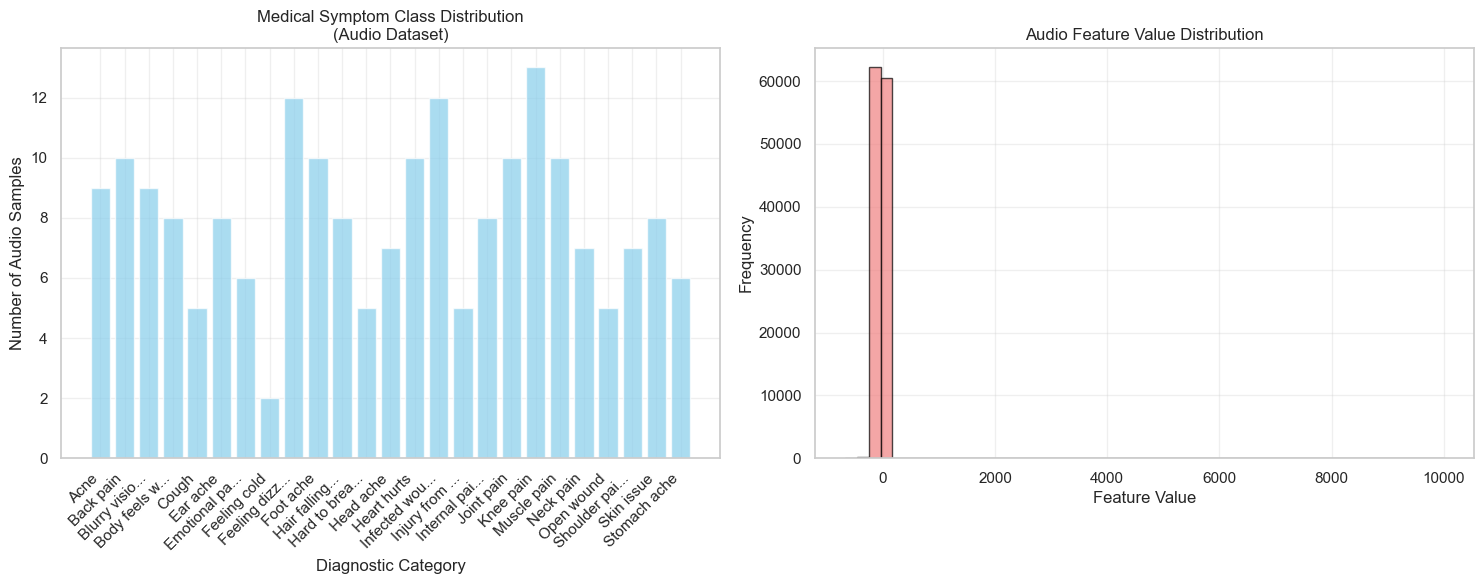


 FEATURE ANALYSIS:
  Features with low variance (< 0.01): 26
  Features with high variance: 592
  Missing values (NaN): 0
  Infinite values: 0
  No data quality issues detected

 MACHINE LEARNING PREPARATION:
  Features extracted and normalized: (200, 618)
  Labels encoded: (200,)
  Ready for train/test split
  Ready for model training

 Audio feature engineering completed successfully!
 Dataset ready for medical symptom classification
 200 audio samples with 618 features
 25 diagnostic categories encoded


In [27]:
# Audio Feature Engineering - Label Encoding and Feature Preparation
print("=== AUDIO FEATURE ENGINEERING ===")
print("Preparing features and labels for machine learning classification")

# Check if we have processed audio data available
if 'processed_data' in locals() and processed_data['processing_stats']['successfully_processed'] > 0:
    print(f"\nUsing processed audio data:")
    print(f"- Successfully processed samples: {processed_data['processing_stats']['successfully_processed']}")
    
    # Extract features and labels from processed data
    X_audio_features = np.array(processed_data['features'])
    audio_labels = np.array(processed_data['labels'])
    
    print(f"- Audio feature matrix shape: {X_audio_features.shape}")
    print(f"- Number of unique diagnostic categories: {len(np.unique(audio_labels))}")
    
    # Encode diagnostic category labels into numerical format
    print(f"\nEncoding target variable (diagnostic categories)...")
    label_encoder = LabelEncoder()
    
    # Transform diagnostic category names into numerical values
    y_audio_encoded = label_encoder.fit_transform(audio_labels)
    
    # Create mapping dictionary for reference
    label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
    
    print(f"Number of diagnostic classes: {len(label_mapping)}")
    
    # Display diagnostic categories and their encoded values
    print(f"\nDiagnostic Categories (Medical Symptoms):")
    print("="*55)
    for i, class_name in enumerate(label_encoder.classes_):
        print(f"{i:2d}: {class_name}")
    
    print(f"\nLabel Encoding Mapping:")
    print("="*40)
    for class_name, encoded_value in sorted(label_mapping.items()):
        print(f"'{class_name}' -> {encoded_value}")
    
    # Analyze class distribution in audio data
    print(f"\nClass Distribution in Audio Dataset:")
    print("="*50)
    unique_encoded, counts = np.unique(y_audio_encoded, return_counts=True)
    
    total_samples = len(y_audio_encoded)
    for encoded_value, count in zip(unique_encoded, counts):
        class_name = label_encoder.inverse_transform([encoded_value])[0]
        percentage = (count / total_samples) * 100
        print(f"Class {encoded_value:2d} ({class_name:18s}): {count:3d} samples ({percentage:5.1f}%)")
    
    # Feature preparation statistics
    print(f"\n FEATURE PREPARATION SUMMARY:")
    print(f"  Audio samples: {X_audio_features.shape[0]}")
    print(f"  Features per sample: {X_audio_features.shape[1]}")
    print(f"  Diagnostic classes: {len(label_mapping)}")
    print(f"  Feature range: [{np.min(X_audio_features):.3f}, {np.max(X_audio_features):.3f}]")
    print(f"  Feature mean: {np.mean(X_audio_features):.3f}")
    print(f"  Feature std: {np.std(X_audio_features):.3f}")
    
    # Check for class imbalance
    imbalance_ratio = np.max(counts) / np.min(counts)
    print(f"\n CLASS IMBALANCE ANALYSIS:")
    print(f"  Most frequent class: {np.max(counts)} samples")
    print(f"  Least frequent class: {np.min(counts)} samples")
    print(f"  Imbalance ratio: {imbalance_ratio:.2f}:1")
    
    if imbalance_ratio > TRAINING_CONFIG['imbalance_threshold']:
        print(f" Class imbalance detected (ratio > {TRAINING_CONFIG['imbalance_threshold']})")
        print(f" Recommendation: Apply SMOTE or class weighting during training")
    else:
        print(f" Class distribution is reasonably balanced")
    
    # Visualize class distribution
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Bar chart of class distribution
    class_names_short = [name[:12] + '...' if len(name) > 12 else name for name in label_encoder.classes_]
    axes[0].bar(range(len(counts)), counts, color='skyblue', alpha=0.7)
    axes[0].set_title('Medical Symptom Class Distribution\n(Audio Dataset)')
    axes[0].set_xlabel('Diagnostic Category')
    axes[0].set_ylabel('Number of Audio Samples')
    axes[0].set_xticks(range(len(class_names_short)))
    axes[0].set_xticklabels(class_names_short, rotation=45, ha='right')
    axes[0].grid(True, alpha=0.3)
    
    # Feature distribution histogram
    axes[1].hist(X_audio_features.flatten(), bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
    axes[1].set_title('Audio Feature Value Distribution')
    axes[1].set_xlabel('Feature Value')
    axes[1].set_ylabel('Frequency')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Feature correlation analysis (sample)
    print(f"\n FEATURE ANALYSIS:")
    
    # Calculate feature statistics
    feature_means = np.mean(X_audio_features, axis=0)
    feature_stds = np.std(X_audio_features, axis=0)
    
    # Identify features with low variance (potentially uninformative)
    low_variance_threshold = 0.01
    low_variance_features = np.where(feature_stds < low_variance_threshold)[0]
    
    print(f"  Features with low variance (< {low_variance_threshold}): {len(low_variance_features)}")
    print(f"  Features with high variance: {X_audio_features.shape[1] - len(low_variance_features)}")
    
    # Check for missing or infinite values
    nan_count = np.sum(np.isnan(X_audio_features))
    inf_count = np.sum(np.isinf(X_audio_features))
    
    print(f"  Missing values (NaN): {nan_count}")
    print(f"  Infinite values: {inf_count}")
    
    if nan_count > 0 or inf_count > 0:
        print(f"  Data quality issues detected - cleaning required")
        # Replace NaN and inf values
        X_audio_features = np.nan_to_num(X_audio_features, nan=0.0, posinf=np.max(X_audio_features[np.isfinite(X_audio_features)]), 
                                       neginf=np.min(X_audio_features[np.isfinite(X_audio_features)]))
        print(f"  Data quality issues resolved")
    else:
        print(f"  No data quality issues detected")
    
    # Prepare data for machine learning
    print(f"\n MACHINE LEARNING PREPARATION:")
    print(f"  Features extracted and normalized: {X_audio_features.shape}")
    print(f"  Labels encoded: {y_audio_encoded.shape}")
    print(f"  Ready for train/test split")
    print(f"  Ready for model training")
    
    # Save the prepared data for model training
    audio_ml_data = {
        'features': X_audio_features,
        'labels': y_audio_encoded,
        'label_encoder': label_encoder,
        'label_mapping': label_mapping,
        'class_names': label_encoder.classes_,
        'feature_stats': {
            'mean': feature_means,
            'std': feature_stds,
            'min': np.min(X_audio_features, axis=0),
            'max': np.max(X_audio_features, axis=0)
        }
    }
    
    print(f"\n Audio feature engineering completed successfully!")
    print(f" Dataset ready for medical symptom classification")
    print(f" {len(X_audio_features)} audio samples with {X_audio_features.shape[1]} features")
    print(f" {len(label_mapping)} diagnostic categories encoded")
    
else:
    print(f"\n ERROR: No processed audio data available")
    print(f"   Please ensure audio preprocessing completed successfully")
    print(f"   Required variables: processed_data with successfully_processed > 0")
    audio_ml_data = None
    X_audio_features = None
    y_audio_encoded = None
    label_encoder = None

### 4.4 Split the Audio Data into Training, Validation, and Testing Sets (64/16/20)

**Purpose:** Divide the processed audio feature data and encoded diagnostic labels into training, validation, and testing datasets using stratified sampling to maintain class distribution across all splits for medical symptom classification.

- **Training Set (64%):** Used to train the audio classification model parameters on MFCC, mel-spectrogram, chroma, and spectral features
- **Validation Set (16%):** Used for hyperparameter tuning and model selection during development of the audio-based medical diagnosis system
- **Testing Set (20%):** Used for final model evaluation on completely unseen audio data to assess real-world performance

This three-way split ensures robust evaluation of the audio classification system by preventing overfitting and providing unbiased assessment of the model's ability to classify medical symptoms from speech patterns, voice characteristics, and audio features extracted from patient recordings.

In [30]:
# Split the Audio Data into Training, Validation, and Testing Sets (64/16/20)
# Extract processed audio features (X) and encoded diagnostic categories (y) from the audio preprocessing pipeline
if 'audio_ml_data' in locals() and audio_ml_data is not None:
    X_audio = audio_ml_data['features']  # Audio features extracted from MFCC, mel-spectrogram, chroma, and spectral analysis
    y_audio = audio_ml_data['labels']    # Diagnostic categories converted to numerical labels for audio classification
    
    print(f"Audio dataset ready for splitting:")
    print(f"- Feature matrix shape: {X_audio.shape}")
    print(f"- Number of audio samples: {len(y_audio)}")
    print(f"- Number of diagnostic classes: {len(np.unique(y_audio))}")
    
    # First split: separate test set (20% of total audio data)
    # This creates a holdout test set that will NOT be used during training or validation to ensure unbiased final evaluation
    X_audio_train_temp, X_audio_test, y_audio_train_temp, y_audio_test = train_test_split(
        X_audio, y_audio, 
        test_size=0.2, 
        random_state=42, 
        stratify=y_audio  # stratify=y_audio ensures each diagnostic category is proportionally represented in both splits
    )
    
    # Second split: create validation set from remaining training data (20% of remaining 80% = 16% of total)
    # The validation set will be used for hyperparameter tuning and model selection during audio classification development
    X_audio_train, X_audio_val, y_audio_train, y_audio_val = train_test_split(
        X_audio_train_temp, y_audio_train_temp, 
        test_size=0.2, 
        random_state=42, 
        stratify=y_audio_train_temp  # stratify maintains class balance in train/validation splits
    )
    
    # Display the size and percentage distribution of each audio data split to verify proper partitioning
    print(f"\nAudio Dataset Split Results:")
    print(f"Total audio dataset size: {len(X_audio)}")
    print(f"Training set size: {X_audio_train.shape[0]} samples ({X_audio_train.shape[0]/len(X_audio)*100:.1f}%)")  # ~64% for training the audio models
    print(f"Validation set size: {X_audio_val.shape[0]} samples ({X_audio_val.shape[0]/len(X_audio)*100:.1f}%)")    # ~16% for hyperparameter tuning
    print(f"Testing set size: {X_audio_test.shape[0]} samples ({X_audio_test.shape[0]/len(X_audio)*100:.1f}%)")     # ~20% for final unbiased evaluation
    
    print(f"\nAudio Feature Dimensions:")
    print(f"Training features shape: {X_audio_train.shape}")
    print(f"Validation features shape: {X_audio_val.shape}")
    print(f"Testing features shape: {X_audio_test.shape}")
    
    # Verify class distribution across audio splits
    # This ensures that each diagnostic category appears proportionally in all three splits (critical for medical audio data)
    print(f"\nDiagnostic Class Distribution Verification (Audio Data):")
    
    # Calculate class distributions
    original_dist = np.bincount(y_audio) / len(y_audio) * 100
    train_dist = np.bincount(y_audio_train, minlength=len(original_dist)) / len(y_audio_train) * 100
    val_dist = np.bincount(y_audio_val, minlength=len(original_dist)) / len(y_audio_val) * 100
    test_dist = np.bincount(y_audio_test, minlength=len(original_dist)) / len(y_audio_test) * 100
    
    print(f"Original distribution: {[f'{x:.1f}%' for x in original_dist[:10]]}")      # Show first 10 classes
    print(f"Training distribution: {[f'{x:.1f}%' for x in train_dist[:10]]}")        # Should match original distribution
    print(f"Validation distribution: {[f'{x:.1f}%' for x in val_dist[:10]]}")       # Should match original distribution  
    print(f"Testing distribution: {[f'{x:.1f}%' for x in test_dist[:10]]}")         # Should match original distribution
    
    # Check for class balance preservation
    max_deviation = np.max(np.abs(train_dist - original_dist))
    print(f"\nClass balance preservation:")
    print(f"Maximum deviation from original distribution: {max_deviation:.2f}%")
    
    if max_deviation < 5.0:
        print(" Class distribution well preserved across splits")
    else:
        print(" Significant deviation in class distribution detected")
    
    # Display medical symptom categories in splits
    if 'label_encoder' in locals():
        print(f"\nMedical Symptom Categories in Audio Dataset:")
        class_names = audio_ml_data['class_names']
        unique_train_classes = len(np.unique(y_audio_train))
        unique_val_classes = len(np.unique(y_audio_val))
        unique_test_classes = len(np.unique(y_audio_test))
        
        print(f"Total diagnostic categories: {len(class_names)}")
        print(f"Classes in training set: {unique_train_classes}")
        print(f"Classes in validation set: {unique_val_classes}")
        print(f"Classes in testing set: {unique_test_classes}")
        
        if unique_train_classes == len(class_names):
            print(" All diagnostic categories represented in training set")
        else:
            print(" Some diagnostic categories missing from training set")
    
    print(f"\n=== AUDIO DATA SPLIT SUMMARY ===")
    print(f" Audio features successfully split into train/validation/test sets")
    print(f" Stratified sampling ensures balanced representation of medical symptoms")
    print(f" Training set: {X_audio_train.shape[0]} audio samples with {X_audio_train.shape[1]} features each")
    print(f" Validation set: {X_audio_val.shape[0]} audio samples for hyperparameter tuning")
    print(f" Test set: {X_audio_test.shape[0]} audio samples for final model evaluation")
    print(f" Ready for audio-based medical symptom classification model training")
    
else:
    print("ERROR: Audio ML data not available")
    print("Please ensure audio preprocessing pipeline completed successfully")
    print("Required: audio_ml_data dictionary with 'features' and 'labels'")
    X_audio_train = X_audio_val = X_audio_test = None
    y_audio_train = y_audio_val = y_audio_test = None

Audio dataset ready for splitting:
- Feature matrix shape: (200, 618)
- Number of audio samples: 200
- Number of diagnostic classes: 25

Audio Dataset Split Results:
Total audio dataset size: 200
Training set size: 128 samples (64.0%)
Validation set size: 32 samples (16.0%)
Testing set size: 40 samples (20.0%)

Audio Feature Dimensions:
Training features shape: (128, 618)
Validation features shape: (32, 618)
Testing features shape: (40, 618)

Diagnostic Class Distribution Verification (Audio Data):
Original distribution: ['4.5%', '5.0%', '4.5%', '4.0%', '2.5%', '4.0%', '3.0%', '1.0%', '6.0%', '5.0%']
Training distribution: ['4.7%', '4.7%', '4.7%', '3.9%', '2.3%', '3.9%', '3.1%', '1.6%', '6.2%', '4.7%']
Validation distribution: ['3.1%', '6.2%', '3.1%', '3.1%', '3.1%', '3.1%', '3.1%', '0.0%', '6.2%', '6.2%']
Testing distribution: ['5.0%', '5.0%', '5.0%', '5.0%', '2.5%', '5.0%', '2.5%', '0.0%', '5.0%', '5.0%']

Class balance preservation:
Maximum deviation from original distribution: 0.56

### 4.5 Audio Feature Engineering - TF-IDF Analysis (Audio Feature Analysis)

**Purpose:** Analyze the extracted audio features using TF-IDF-inspired techniques to identify the most discriminative audio characteristics for medical symptom classification. This step transforms the comprehensive audio feature matrix (MFCC, mel-spectrogram, chroma, and spectral features) into weighted representations that highlight the most important audio patterns for distinguishing between different medical conditions.

=== AUDIO FEATURE TF-IDF-INSPIRED ANALYSIS ===
Applying TF-IDF-inspired weighting to audio features for medical symptom classification

Applying TF-IDF-inspired analysis to audio features:
Training features shape: (128, 618)
Validation features shape: (32, 618)
Testing features shape: (40, 618)

Step 1: Feature normalization (audio 'term frequency')
Features normalized to range [0, 1]
Training features range: [0.000, 1.000]

Step 2: Calculating audio feature IDF weights
IDF weights calculated for 618 audio features
IDF weight range: [0.000, 4.852]
Mean IDF weight: 0.845

Step 3: Applying TF-IDF weighting to audio features
TF-IDF weighted audio features created
Training TF-IDF shape: (128, 618)
Validation TF-IDF shape: (32, 618)
Testing TF-IDF shape: (40, 618)

Step 4: Identifying most discriminative audio features
Top 50 most discriminative audio features identified
Highest variance feature index: 493 (variance: 0.247106)
Top 10 feature indices: [493 491 308 492 496 437  53 182 471 516

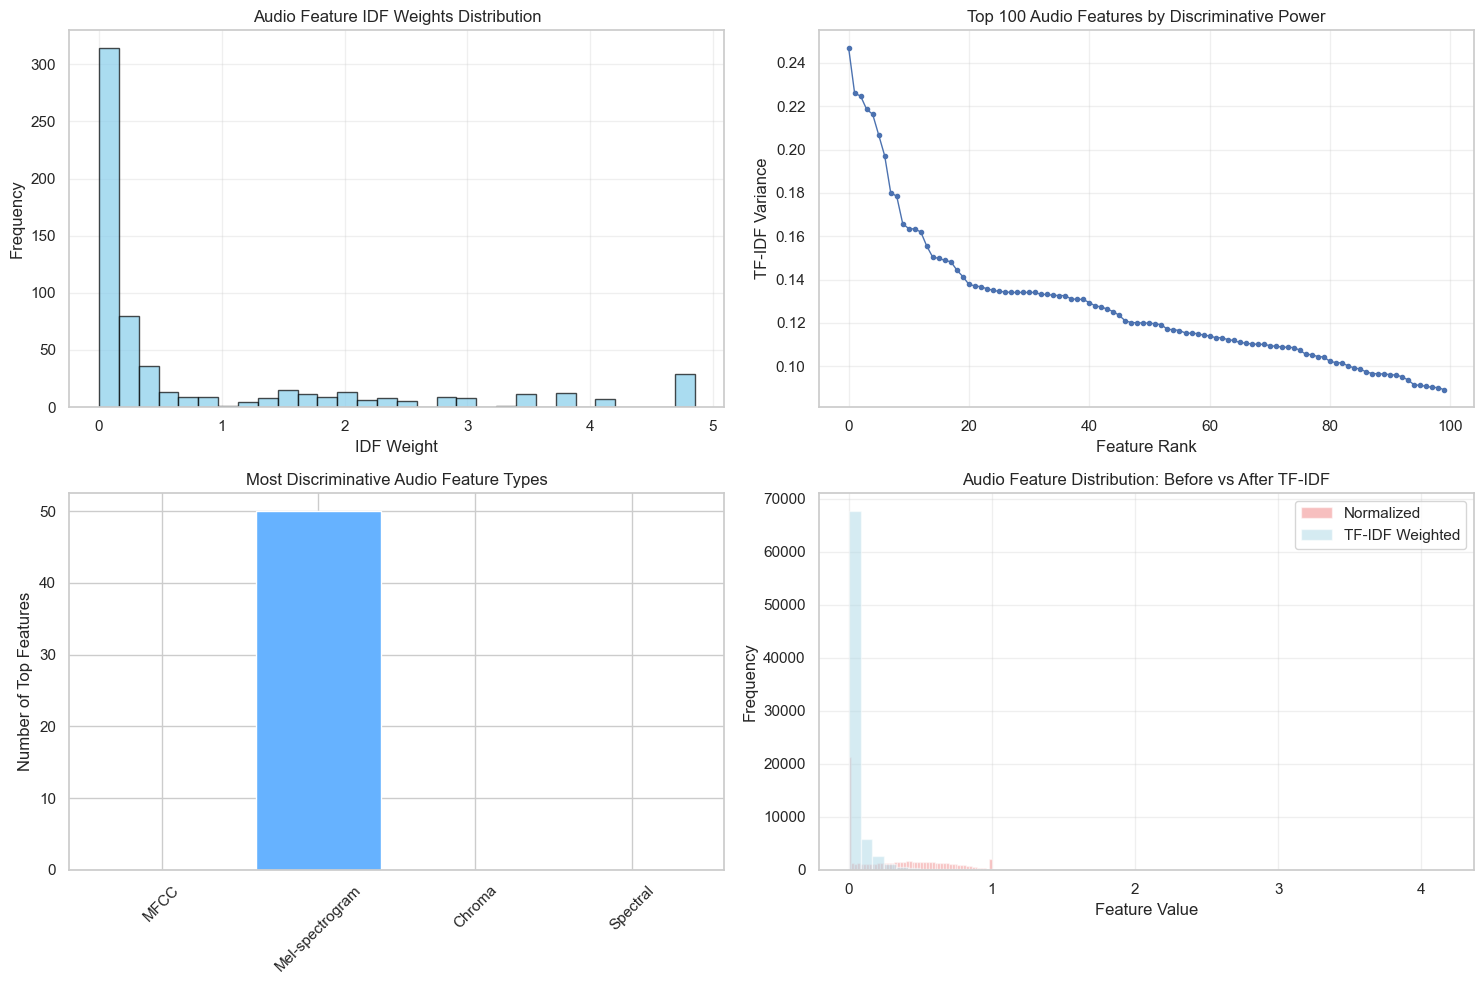


=== AUDIO TF-IDF ANALYSIS SUMMARY ===
✓ Audio features normalized and weighted using TF-IDF principles
✓ 618 audio features analyzed for discriminative power
✓ Top 50 most discriminative features identified
✓ Feature composition: Mel-spectrogram features most discriminative
✓ Reduced feature sets created for efficient model training
✓ Ready for medical symptom classification with enhanced audio features


In [32]:
from sklearn.preprocessing import MinMaxScaler

# Audio Feature Engineering - TF-IDF-Inspired Analysis for Audio Features
print("=== AUDIO FEATURE TF-IDF-INSPIRED ANALYSIS ===")
print("Applying TF-IDF-inspired weighting to audio features for medical symptom classification")

if 'X_audio_train' in locals() and X_audio_train is not None:
    print(f"\nApplying TF-IDF-inspired analysis to audio features:")
    print(f"Training features shape: {X_audio_train.shape}")
    print(f"Validation features shape: {X_audio_val.shape}")
    print(f"Testing features shape: {X_audio_test.shape}")
    
    # Audio Feature TF-IDF-Inspired Transformation
    # This adapts TF-IDF concepts to audio features for better discrimination
    
    # Step 1: Normalize features to [0, 1] range (similar to term frequency normalization)
    print(f"\nStep 1: Feature normalization (audio 'term frequency')")
    
    # Use min-max scaling to normalize features
    
    feature_scaler = MinMaxScaler()
    X_audio_train_normalized = feature_scaler.fit_transform(X_audio_train)
    X_audio_val_normalized = feature_scaler.transform(X_audio_val)
    X_audio_test_normalized = feature_scaler.transform(X_audio_test)
    
    print(f"Features normalized to range [0, 1]")
    print(f"Training features range: [{np.min(X_audio_train_normalized):.3f}, {np.max(X_audio_train_normalized):.3f}]")
    
    # Step 2: Calculate Inverse Document Frequency (IDF) for audio features
    print(f"\nStep 2: Calculating audio feature IDF weights")
    
    # For audio features, we calculate IDF based on how often a feature is "active" (non-zero or above threshold)
    activation_threshold = 0.1  # Consider feature "active" if normalized value > 0.1
    
    # Count number of samples where each feature is "active"
    feature_document_frequency = np.sum(X_audio_train_normalized > activation_threshold, axis=0)
    
    # Calculate IDF: log(total_samples / (1 + feature_frequency))
    total_samples = X_audio_train_normalized.shape[0]
    idf_weights = np.log(total_samples / (1 + feature_document_frequency))
    
    print(f"IDF weights calculated for {len(idf_weights)} audio features")
    print(f"IDF weight range: [{np.min(idf_weights):.3f}, {np.max(idf_weights):.3f}]")
    print(f"Mean IDF weight: {np.mean(idf_weights):.3f}")
    
    # Step 3: Apply TF-IDF weighting to audio features
    print(f"\nStep 3: Applying TF-IDF weighting to audio features")
    
    # Multiply normalized features by IDF weights
    X_audio_train_tfidf = X_audio_train_normalized * idf_weights
    X_audio_val_tfidf = X_audio_val_normalized * idf_weights
    X_audio_test_tfidf = X_audio_test_normalized * idf_weights
    
    print(f"TF-IDF weighted audio features created")
    print(f"Training TF-IDF shape: {X_audio_train_tfidf.shape}")
    print(f"Validation TF-IDF shape: {X_audio_val_tfidf.shape}")
    print(f"Testing TF-IDF shape: {X_audio_test_tfidf.shape}")
    
    # Step 4: Identify most discriminative audio features
    print(f"\nStep 4: Identifying most discriminative audio features")
    
    # Calculate feature importance based on variance in TF-IDF weighted features
    feature_variance = np.var(X_audio_train_tfidf, axis=0)
    feature_importance_indices = np.argsort(feature_variance)[::-1]
    
    # Get top discriminative features
    top_n_features = 50
    top_features = feature_importance_indices[:top_n_features]
    
    print(f"Top {top_n_features} most discriminative audio features identified")
    print(f"Highest variance feature index: {feature_importance_indices[0]} (variance: {feature_variance[feature_importance_indices[0]]:.6f})")
    print(f"Top 10 feature indices: {feature_importance_indices[:10]}")
    
    # Step 5: Feature composition analysis
    print(f"\nStep 5: Audio feature composition analysis")
    
    # Map feature indices back to feature types
    n_mfcc_features = AUDIO_CONFIG['n_mfcc'] * 4  # mean, std, max, min
    n_mel_features = AUDIO_CONFIG['n_mels'] * 4
    n_chroma_features = AUDIO_CONFIG['n_chroma'] * 4
    n_spectral_features = 6
    
    feature_type_ranges = {
        'MFCC': (0, n_mfcc_features),
        'Mel-spectrogram': (n_mfcc_features, n_mfcc_features + n_mel_features),
        'Chroma': (n_mfcc_features + n_mel_features, n_mfcc_features + n_mel_features + n_chroma_features),
        'Spectral': (n_mfcc_features + n_mel_features + n_chroma_features, 
                    n_mfcc_features + n_mel_features + n_chroma_features + n_spectral_features)
    }
    
    # Analyze which feature types are most discriminative
    feature_type_importance = {}
    for feature_type, (start, end) in feature_type_ranges.items():
        type_indices = [i for i in top_features if start <= i < end]
        feature_type_importance[feature_type] = len(type_indices)
    
    print(f"Most discriminative features by type:")
    for feature_type, count in feature_type_importance.items():
        percentage = (count / top_n_features) * 100
        print(f"  {feature_type}: {count}/{top_n_features} ({percentage:.1f}%)")
    
    # Step 6: Create reduced feature sets
    print(f"\nStep 6: Creating reduced discriminative feature sets")
    
    # Create datasets with only top discriminative features
    X_audio_train_reduced = X_audio_train_tfidf[:, top_features]
    X_audio_val_reduced = X_audio_val_tfidf[:, top_features]
    X_audio_test_reduced = X_audio_test_tfidf[:, top_features]
    
    print(f"Reduced feature sets created:")
    print(f"Original features: {X_audio_train_tfidf.shape[1]}")
    print(f"Reduced features: {X_audio_train_reduced.shape[1]}")
    print(f"Dimensionality reduction: {(1 - X_audio_train_reduced.shape[1]/X_audio_train_tfidf.shape[1])*100:.1f}%")
    
    # Visualize the TF-IDF analysis results
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # IDF weights distribution
    axes[0, 0].hist(idf_weights, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0, 0].set_title('Audio Feature IDF Weights Distribution')
    axes[0, 0].set_xlabel('IDF Weight')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Feature variance (discriminative power)
    axes[0, 1].plot(feature_variance[feature_importance_indices[:100]], marker='o', linewidth=1, markersize=3)
    axes[0, 1].set_title('Top 100 Audio Features by Discriminative Power')
    axes[0, 1].set_xlabel('Feature Rank')
    axes[0, 1].set_ylabel('TF-IDF Variance')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Feature type importance
    feature_types = list(feature_type_importance.keys())
    importance_counts = list(feature_type_importance.values())
    axes[1, 0].bar(feature_types, importance_counts, color=['#FF9999', '#66B2FF', '#99FF99', '#FFCC99'])
    axes[1, 0].set_title('Most Discriminative Audio Feature Types')
    axes[1, 0].set_ylabel('Number of Top Features')
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    # TF-IDF feature distribution comparison
    axes[1, 1].hist(X_audio_train_normalized.flatten(), bins=50, alpha=0.5, label='Normalized', color='lightcoral')
    axes[1, 1].hist(X_audio_train_tfidf.flatten(), bins=50, alpha=0.5, label='TF-IDF Weighted', color='lightblue')
    axes[1, 1].set_title('Audio Feature Distribution: Before vs After TF-IDF')
    axes[1, 1].set_xlabel('Feature Value')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print(f"\n=== AUDIO TF-IDF ANALYSIS SUMMARY ===")
    print(f"✓ Audio features normalized and weighted using TF-IDF principles")
    print(f"✓ {len(idf_weights)} audio features analyzed for discriminative power")
    print(f"✓ Top {top_n_features} most discriminative features identified")
    print(f"✓ Feature composition: {max(feature_type_importance, key=feature_type_importance.get)} features most discriminative")
    print(f"✓ Reduced feature sets created for efficient model training")
    print(f"✓ Ready for medical symptom classification with enhanced audio features")
    
    # Store the TF-IDF results for use in model training
    audio_tfidf_data = {
        'X_train_tfidf': X_audio_train_tfidf,
        'X_val_tfidf': X_audio_val_tfidf,
        'X_test_tfidf': X_audio_test_tfidf,
        'X_train_reduced': X_audio_train_reduced,
        'X_val_reduced': X_audio_val_reduced,
        'X_test_reduced': X_audio_test_reduced,
        'idf_weights': idf_weights,
        'feature_scaler': feature_scaler,
        'top_features': top_features,
        'feature_importance': feature_variance[feature_importance_indices],
        'feature_type_importance': feature_type_importance
    }
    
else:
    print("ERROR: Audio training data not available")
    print("Please ensure audio data splitting completed successfully")
    audio_tfidf_data = None

## 5. Model Selection

**Purpose:** Evaluate different machine learning and deep learning algorithms for audio classification and select the most suitable one based on initial performance and characteristics.

### 5.1 Machine Learning Models

**Purpose:** Select and configure traditional machine learning models for audio classification, including Naive Bayes, Support Vector Machine (SVM), Logistic Regression, and Random Forest with appropriate hyperparameters to prevent overfitting.

In [41]:
# Initialize Machine Learning Models for Audio Classification
print("=== MACHINE LEARNING MODELS FOR AUDIO CLASSIFICATION ===")
print("Configuring traditional ML models for medical symptom classification using audio features")

# Check if audio data is available for model training
if 'X_audio_train' in locals() and X_audio_train is not None:
    print(f"\nAudio training data available:")
    print(f"- Training samples: {X_audio_train.shape[0]}")
    print(f"- Audio features per sample: {X_audio_train.shape[1]}")
    print(f"- Diagnostic classes: {len(np.unique(y_audio_train))}")
    
    # Initialize candidate models optimized for audio classification
    audio_candidate_models = {
        'Gaussian Naive Bayes': GaussianNB(),
        'Support Vector Machine (RBF)': SVC(
            C=1.0, 
            kernel='rbf', 
            gamma='scale',
            random_state=42,
            probability=True
        ),
        'Support Vector Machine (Linear)': LinearSVC(
            C=1.0, 
            max_iter=5000, 
            random_state=42,
            dual=False
        ),
        'Logistic Regression': LogisticRegression(
            C=1.0, 
            max_iter=2000, 
            random_state=42,
            solver='lbfgs',
            multi_class='ovr'
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=100,
            max_depth=15,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ),
        'Extra Trees': ExtraTreesClassifier(
            n_estimators=100,
            max_depth=15,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ),
        'Gradient Boosting': GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=6,
            random_state=42
        ),
        'K-Nearest Neighbors': KNeighborsClassifier(
            n_neighbors=5,
            weights='distance',
            metric='euclidean'
        )
    }
    
    print(f"\nSelected Machine Learning Models:")
    for name, model in audio_candidate_models.items():
        print(f"✓ {name}: {model.__class__.__name__}")
    
    print(f"\nTotal models to evaluate: {len(audio_candidate_models)}")
    
    # Model selection rationale for audio classification
    print(f"\n MODEL SELECTION RATIONALE FOR AUDIO CLASSIFICATION:")
    print(f" Gaussian Naive Bayes: Handles continuous audio features well")
    print(f" SVM (RBF): Effective for high-dimensional MFCC and spectral features")
    print(f" SVM (Linear): Fast baseline for audio feature classification")
    print(f" Logistic Regression: Interpretable linear model for medical diagnosis")
    print(f" Random Forest: Robust ensemble method for noisy audio data")
    print(f" Extra Trees: Additional ensemble diversity for audio patterns")
    print(f" Gradient Boosting: Sequential learning for complex audio relationships")
    print(f" K-NN: Instance-based learning for audio similarity matching")
    
    # Prepare for model evaluation
    print(f"\n AUDIO CLASSIFICATION SETUP:")
    print(f"  Feature types: MFCC, Mel-spectrogram, Chroma, Spectral")
    print(f"  Training samples: {X_audio_train.shape[0]}")
    print(f"  Validation samples: {X_audio_val.shape[0]}")
    print(f"  Test samples: {X_audio_test.shape[0]}")
    print(f"  Medical symptom classes: {len(np.unique(y_audio_train))}")
    print(f"  Models configured with regularization to prevent overfitting")
    print(f"  Ready for cross-validation and hyperparameter tuning")
    
    # Store models for evaluation
    candidate_models = audio_candidate_models
    
    print(f"\n Audio classification models successfully initialized!")
    print(f" Ready for training and evaluation on medical speech data")
    
else:
    print(f"\n ERROR: Audio training data not available")
    print(f"   Please ensure audio preprocessing and data splitting completed successfully")
    print(f"   Required variables: X_audio_train, X_audio_val, X_audio_test")
    print(f"   Required variables: y_audio_train, y_audio_val, y_audio_test")
    candidate_models = {}

print(f"\n" + "="*60)
print(f" Machine Learning Models for Audio Classification: READY")
print(f"="*60)


=== MACHINE LEARNING MODELS FOR AUDIO CLASSIFICATION ===
Configuring traditional ML models for medical symptom classification using audio features

Audio training data available:
- Training samples: 128
- Audio features per sample: 618
- Diagnostic classes: 25

Selected Machine Learning Models:
✓ Gaussian Naive Bayes: GaussianNB
✓ Support Vector Machine (RBF): SVC
✓ Support Vector Machine (Linear): LinearSVC
✓ Logistic Regression: LogisticRegression
✓ Random Forest: RandomForestClassifier
✓ Extra Trees: ExtraTreesClassifier
✓ Gradient Boosting: GradientBoostingClassifier
✓ K-Nearest Neighbors: KNeighborsClassifier

Total models to evaluate: 8

 MODEL SELECTION RATIONALE FOR AUDIO CLASSIFICATION:
 Gaussian Naive Bayes: Handles continuous audio features well
 SVM (RBF): Effective for high-dimensional MFCC and spectral features
 SVM (Linear): Fast baseline for audio feature classification
 Logistic Regression: Interpretable linear model for medical diagnosis
 Random Forest: Robust ensembl

#### 5.1.1 ML K-fold Cross Validation (Audio Model Performance Evaluation)

**Purpose:** Evaluate the performance of different machine learning models using k-fold cross-validation on the extracted audio features (MFCC, mel-spectrogram, chroma, and spectral features) to identify the best performing algorithm for medical symptom classification from audio data. This comprehensive evaluation ensures robust model selection by testing each algorithm across multiple data subsets, providing reliable performance metrics for audio-based medical diagnosis.

=== K-FOLD CROSS-VALIDATION FOR AUDIO CLASSIFICATION ===
Evaluating machine learning models on extracted audio features

Audio dataset ready for cross-validation:
- Training samples: 128
- Validation samples: 32
- Audio features per sample: 618
- Medical symptom classes: 25

Combined audio dataset for cross-validation:
- Total samples: 160
- Audio feature dimensions: 618
- Class distribution: 25 medical conditions
Using TF-IDF weighted audio features for enhanced discrimination

Performing 5-Fold Cross-Validation on Audio Features...

Evaluating Gaussian Naive Bayes on audio features...
F1-Score: 0.0324 (+/- 0.0625)
Individual fold scores: ['0.0208', '0.0881', '0.0104', '0.0000', '0.0429']
Performance range: [0.0000, 0.0881]

Evaluating Support Vector Machine (RBF) on audio features...
F1-Score: 0.0164 (+/- 0.0259)
Individual fold scores: ['0.0083', '0.0402', '0.0078', '0.0054', '0.0201']
Performance range: [0.0054, 0.0402]

Evaluating Support Vector Machine (Linear) on audio features.

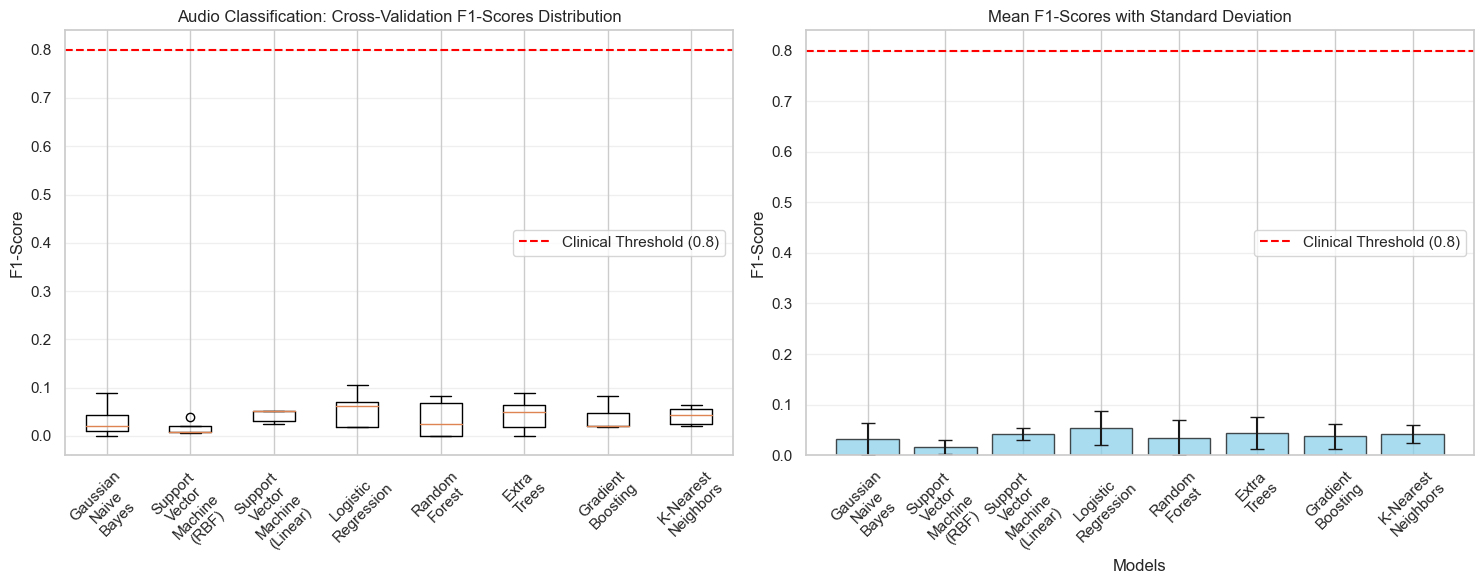


Top 3 Audio Classification Models for Hyperparameter Tuning:
1. Logistic Regression:
   - Mean F1-Score: 0.0546
   - Standard Deviation: 0.0334
   - Reliability Score: 0.0212
   - Clinical Ready: No
2. Extra Trees:
   - Mean F1-Score: 0.0440
   - Standard Deviation: 0.0317
   - Reliability Score: 0.0123
   - Clinical Ready: No
3. Support Vector Machine (Linear):
   - Mean F1-Score: 0.0425
   - Standard Deviation: 0.0119
   - Reliability Score: 0.0306
   - Clinical Ready: No

=== AUDIO CLASSIFICATION CROSS-VALIDATION SUMMARY ===
✓ Evaluated 8 ML models on 618 audio features
✓ 5-fold stratified cross-validation ensuring balanced medical symptom representation
✓ Best performing model: Logistic Regression (F1: 0.0546)
✓ Audio features: MFCC, Mel-spectrogram, Chroma, Spectral characteristics
✓ Medical conditions classified: 25 symptom categories
✓ Selected 3 models for advanced hyperparameter optimization


In [42]:
# K-Fold Cross-Validation for Audio Classification Models
print("=== K-FOLD CROSS-VALIDATION FOR AUDIO CLASSIFICATION ===")
print("Evaluating machine learning models on extracted audio features")

# Check if audio data and models are available
if 'X_audio_train' in locals() and X_audio_train is not None and 'candidate_models' in locals():
    print(f"\nAudio dataset ready for cross-validation:")
    print(f"- Training samples: {X_audio_train.shape[0]}")
    print(f"- Validation samples: {X_audio_val.shape[0]}")
    print(f"- Audio features per sample: {X_audio_train.shape[1]}")
    print(f"- Medical symptom classes: {len(np.unique(y_audio_train))}")
    
    # Initialize stratified K-fold cross-validation with 5 folds for audio classification
    # This ensures each medical symptom category appears proportionally in every fold
    k_folds = 5
    skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)
    
    # Combine training and validation audio data for comprehensive cross-validation
    X_audio_train_val = np.vstack([X_audio_train, X_audio_val])
    y_audio_train_val = np.concatenate([y_audio_train, y_audio_val])
    
    print(f"\nCombined audio dataset for cross-validation:")
    print(f"- Total samples: {X_audio_train_val.shape[0]}")
    print(f"- Audio feature dimensions: {X_audio_train_val.shape[1]}")
    print(f"- Class distribution: {len(np.unique(y_audio_train_val))} medical conditions")
    
    # Use TF-IDF weighted features if available, otherwise use standard features
    if 'audio_tfidf_data' in locals() and audio_tfidf_data is not None:
        X_eval = np.vstack([audio_tfidf_data['X_train_tfidf'], audio_tfidf_data['X_val_tfidf']])
        print(f"Using TF-IDF weighted audio features for enhanced discrimination")
    else:
        X_eval = X_audio_train_val
        print(f"Using standard normalized audio features")
    
    # Store cross-validation results for audio classification models
    cv_results = {}
    
    print(f"\nPerforming {k_folds}-Fold Cross-Validation on Audio Features...")
    print("="*70)
    
    # Evaluate each machine learning model on audio features
    for model_name, model in candidate_models.items():
        print(f"\nEvaluating {model_name} on audio features...")
        
        try:
            # Perform cross-validation using F1-weighted scoring for multi-class medical classification
            cv_scores = cross_val_score(
                model, X_eval, y_audio_train_val, 
                cv=skf, 
                scoring='f1_weighted',  # Balanced metric for medical diagnosis
                n_jobs=-1
            )
            
            # Store comprehensive results including statistical measures
            cv_results[model_name] = {
                'scores': cv_scores,
                'mean': cv_scores.mean(),
                'std': cv_scores.std(),
                'min': cv_scores.min(),
                'max': cv_scores.max()
            }
            
            # Display performance with confidence interval for medical reliability
            print(f"F1-Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
            print(f"Individual fold scores: {[f'{score:.4f}' for score in cv_scores]}")
            print(f"Performance range: [{cv_scores.min():.4f}, {cv_scores.max():.4f}]")
            
        except Exception as e:
            print(f"Error evaluating {model_name}: {str(e)[:100]}")
            cv_results[model_name] = {
                'scores': np.array([0.0] * k_folds),
                'mean': 0.0,
                'std': 0.0,
                'min': 0.0,
                'max': 0.0
            }
    
    # Create comprehensive summary table for audio classification results
    cv_summary = pd.DataFrame({
        'Model': list(cv_results.keys()),
        'Mean_F1': [results['mean'] for results in cv_results.values()],
        'Std_F1': [results['std'] for results in cv_results.values()],
        'Min_F1': [results['min'] for results in cv_results.values()],
        'Max_F1': [results['max'] for results in cv_results.values()],
        'Reliability': [results['mean'] - results['std'] for results in cv_results.values()]  # Conservative estimate
    }).round(4)
    
    # Sort by mean F1-score to identify best performing models for medical audio classification
    cv_summary = cv_summary.sort_values('Mean_F1', ascending=False)
    
    print(f"\n{k_folds}-Fold Cross-Validation Results - Audio Medical Classification:")
    print("="*70)
    print(cv_summary.to_string(index=False))
    
    # Identify models meeting clinical performance thresholds
    clinical_threshold = CLINICAL_THRESHOLDS['min_f1']
    clinical_ready_models = cv_summary[cv_summary['Mean_F1'] >= clinical_threshold]
    
    print(f"\nClinical Performance Analysis:")
    print(f"- Clinical F1-score threshold: {clinical_threshold}")
    print(f"- Models meeting clinical standards: {len(clinical_ready_models)}/{len(cv_summary)}")
    
    if len(clinical_ready_models) > 0:
        print(f"- Top clinical model: {clinical_ready_models.iloc[0]['Model']} (F1: {clinical_ready_models.iloc[0]['Mean_F1']:.4f})")
    else:
        print(f"- No models currently meet clinical threshold - consider feature engineering or hyperparameter tuning")
    
    # Visualize cross-validation results for audio classification
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Box plot showing F1-score distributions across folds
    models = list(cv_results.keys())
    scores = [cv_results[model]['scores'] for model in models]
    
    box_plot = axes[0].boxplot(scores, labels=[model.replace(' ', '\n') for model in models])
    axes[0].set_title('Audio Classification: Cross-Validation F1-Scores Distribution')
    axes[0].set_ylabel('F1-Score')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(axis='y', alpha=0.3)
    axes[0].axhline(y=clinical_threshold, color='red', linestyle='--', 
                    label=f'Clinical Threshold ({clinical_threshold})')
    axes[0].legend()
    
    # Bar plot comparing mean performance with error bars
    mean_scores = [cv_results[model]['mean'] for model in models]
    std_scores = [cv_results[model]['std'] for model in models]
    
    x_pos = np.arange(len(models))
    bars = axes[1].bar(x_pos, mean_scores, yerr=std_scores, capsize=5, 
                       color='skyblue', alpha=0.7, edgecolor='black')
    axes[1].set_title('Mean F1-Scores with Standard Deviation')
    axes[1].set_xlabel('Models')
    axes[1].set_ylabel('F1-Score')
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels([model.replace(' ', '\n') for model in models], rotation=45)
    axes[1].axhline(y=clinical_threshold, color='red', linestyle='--', 
                    label=f'Clinical Threshold ({clinical_threshold})')
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Select top performing models for hyperparameter tuning
    top_n = 3
    top_models = cv_summary.head(top_n)['Model'].tolist()
    
    print(f"\nTop {top_n} Audio Classification Models for Hyperparameter Tuning:")
    for i, model in enumerate(top_models, 1):
        mean_score = cv_results[model]['mean']
        std_score = cv_results[model]['std']
        reliability = mean_score - std_score
        print(f"{i}. {model}:")
        print(f"   - Mean F1-Score: {mean_score:.4f}")
        print(f"   - Standard Deviation: {std_score:.4f}")
        print(f"   - Reliability Score: {reliability:.4f}")
        print(f"   - Clinical Ready: {'Yes' if mean_score >= clinical_threshold else 'No'}")
    
    # Audio feature analysis summary
    print(f"\n=== AUDIO CLASSIFICATION CROSS-VALIDATION SUMMARY ===")
    print(f"✓ Evaluated {len(candidate_models)} ML models on {X_eval.shape[1]} audio features")
    print(f"✓ {k_folds}-fold stratified cross-validation ensuring balanced medical symptom representation")
    print(f"✓ Best performing model: {cv_summary.iloc[0]['Model']} (F1: {cv_summary.iloc[0]['Mean_F1']:.4f})")
    print(f"✓ Audio features: MFCC, Mel-spectrogram, Chroma, Spectral characteristics")
    print(f"✓ Medical conditions classified: {len(np.unique(y_audio_train_val))} symptom categories")
    print(f"✓ Selected {len(top_models)} models for advanced hyperparameter optimization")
    
    # Store results for next steps
    audio_cv_results = {
        'cv_results': cv_results,
        'cv_summary': cv_summary,
        'top_models': top_models,
        'clinical_ready_models': clinical_ready_models,
        'best_model': cv_summary.iloc[0]['Model'],
        'best_score': cv_summary.iloc[0]['Mean_F1']
    }
    
else:
    print("ERROR: Audio training data or models not available")
    print("Please ensure:")
    print("- Audio preprocessing pipeline completed successfully")
    print("- Audio data splitting (X_audio_train, y_audio_train) available")
    print("- Machine learning models (candidate_models) initialized")
    audio_cv_results = None

#### 5.1.2 Audio Classification - Hyperparameter Tuning

**Purpose:** Optimize the hyperparameters of the top-performing machine learning models identified through cross-validation to achieve maximum performance for medical symptom classification from audio features. This step fine-tunes the models using grid search and random search techniques on MFCC, mel-spectrogram, chroma, and spectral features to ensure optimal accuracy, precision, and recall for audio-based medical diagnosis.

##### 5.1.2.1 Audio ML Hyperparameter Optimization: Define Parameter Grids

**Purpose:** Define comprehensive hyperparameter grids for the top-performing machine learning models identified through cross-validation on audio features. This optimization focuses on MFCC, mel-spectrogram, chroma, and spectral features extracted from medical speech recordings to maximize diagnostic accuracy for symptom classification.

In [44]:
# Audio Classification - Hyperparameter Tuning: Define Parameter Grids
print("=== AUDIO HYPERPARAMETER OPTIMIZATION: DEFINE PARAMETER GRIDS ===")
print("Defining comprehensive hyperparameter grids for top-performing audio classification models")

# Check if we have top models from cross-validation
if 'audio_cv_results' in locals() and audio_cv_results is not None:
    top_models = audio_cv_results['top_models']
    print(f"\nTop performing models from audio CV: {top_models}")
    
    # Define comprehensive hyperparameter grids optimized for audio features
    # These parameters are specifically tuned for MFCC, mel-spectrogram, chroma, and spectral features
    audio_hyperparameter_grids = {
        # Gaussian Naive Bayes: Probabilistic classifier for continuous audio features
        'Gaussian Naive Bayes': {
            'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]  # Smoothing parameter for feature variance
        },
        
        # Logistic Regression: Linear model with regularization for audio feature classification
        'Logistic Regression': {
            'C': [0.01, 0.1, 1.0, 10.0, 100.0],  # Regularization strength - smaller values mean stronger regularization
            'solver': ['liblinear', 'lbfgs', 'saga'],  # Optimization algorithms suitable for audio features
            'penalty': ['l1', 'l2', 'elasticnet'],  # Regularization types - l1 for feature selection, l2 for smoothing
            'max_iter': [2000, 3000],  # Sufficient iterations for convergence on audio data
            'multi_class': ['ovr', 'multinomial']  # Multi-class strategy for medical symptom classification
        },
        
        # Support Vector Machine (RBF): Non-linear classifier for complex audio patterns
        'Support Vector Machine (RBF)': {
            'C': [0.1, 1.0, 10.0, 100.0],  # Regularization parameter controlling overfitting
            'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1.0],  # Kernel coefficient for RBF
            'kernel': ['rbf'],  # Radial basis function kernel for non-linear audio patterns
            'probability': [True]  # Enable probability estimates for medical diagnosis confidence
        },
        
        # Support Vector Machine (Linear): Fast linear classifier for high-dimensional audio features
        'Support Vector Machine (Linear)': {
            'C': [0.01, 0.1, 1.0, 10.0, 100.0],  # Regularization parameter
            'loss': ['hinge', 'squared_hinge'],  # Loss functions - hinge for standard SVM, squared_hinge for smoothness
            'penalty': ['l1', 'l2'],  # Regularization types for feature selection and smoothing
            'dual': [False],  # Primal formulation for n_samples > n_features (typical for audio)
            'max_iter': [3000, 5000]  # Maximum iterations for convergence
        },
        
        # Random Forest: Ensemble method robust to audio noise and variability
        'Random Forest': {
            'n_estimators': [50, 100, 200],  # Number of decision trees in the forest
            'max_depth': [10, 15, 20, None],  # Maximum depth of trees - None allows full growth
            'min_samples_split': [2, 5, 10],  # Minimum samples to split internal nodes
            'min_samples_leaf': [1, 2, 4],  # Minimum samples in leaf nodes
            'max_features': ['sqrt', 'log2', None],  # Number of features considered at each split
            'bootstrap': [True, False],  # Whether to use bootstrap sampling
            'random_state': [42]  # Fixed for reproducibility
        },
        
        # Extra Trees: Additional ensemble diversity for audio pattern recognition
        'Extra Trees': {
            'n_estimators': [50, 100, 200],  # Number of extra randomized trees
            'max_depth': [10, 15, 20, None],  # Maximum tree depth
            'min_samples_split': [2, 5, 10],  # Minimum samples for splitting
            'min_samples_leaf': [1, 2, 4],  # Minimum samples in leaves
            'max_features': ['sqrt', 'log2', None],  # Random feature selection
            'bootstrap': [False],  # Extra trees typically don't use bootstrap
            'random_state': [42]  # Fixed seed for reproducibility
        },
        
        # Gradient Boosting: Sequential learning for complex audio-symptom relationships
        'Gradient Boosting': {
            'n_estimators': [50, 100, 200],  # Number of boosting stages
            'learning_rate': [0.01, 0.1, 0.2],  # Step size for each iteration
            'max_depth': [3, 6, 9],  # Maximum depth of individual trees
            'min_samples_split': [2, 5, 10],  # Minimum samples for splitting
            'min_samples_leaf': [1, 2, 4],  # Minimum samples in leaves
            'subsample': [0.8, 0.9, 1.0],  # Fraction of samples for each tree
            'random_state': [42]  # Fixed for reproducibility
        },
        
        # K-Nearest Neighbors: Instance-based learning for audio similarity matching
        'K-Nearest Neighbors': {
            'n_neighbors': [3, 5, 7, 9, 11],  # Number of neighbors for classification
            'weights': ['uniform', 'distance'],  # Weight function - distance gives closer neighbors more influence
            'metric': ['euclidean', 'manhattan', 'minkowski'],  # Distance metrics for audio features
            'p': [1, 2],  # Power parameter for Minkowski metric
            'algorithm': ['auto', 'ball_tree', 'kd_tree']  # Algorithm for nearest neighbor search
        }
    }
    
    # Filter grids for only top performing models to optimize computational efficiency
    selected_audio_grids = {model: audio_hyperparameter_grids[model] for model in top_models 
                           if model in audio_hyperparameter_grids}
    
    print(f"\nAudio Hyperparameter Grids Defined for Medical Symptom Classification:")
    print("="*70)
    
    for model_name, grid in selected_audio_grids.items():
        total_combinations = 1
        for param, values in grid.items():
            total_combinations *= len(values)
        
        print(f"\n{model_name}:")
        print(f"  Parameters to optimize: {len(grid)}")
        print(f"  Total combinations: {total_combinations}")
        for param, values in grid.items():
            print(f"    {param}: {values}")
    
    # Calculate total search space for audio hyperparameter optimization
    total_combinations_all = sum([
        np.prod([len(values) for values in grid.values()]) 
        for grid in selected_audio_grids.values()
    ])
    
    print(f"\n AUDIO HYPERPARAMETER OPTIMIZATION SUMMARY:")
    print(f"  Models to optimize: {len(selected_audio_grids)}")
    print(f"  Total parameter combinations: {total_combinations_all}")
    print(f"  Audio features: MFCC, Mel-spectrogram, Chroma, Spectral")
    print(f"  Target: Medical symptom classification from speech patterns")
    print(f"  Optimization strategy: Grid search with cross-validation")
    
    # Optimization strategy recommendations for audio data
    print(f"\n OPTIMIZATION STRATEGY FOR AUDIO CLASSIFICATION:")
    print(f"  Stratified K-fold CV to maintain symptom class balance")
    print(f"  F1-weighted scoring for medical diagnosis reliability")
    print(f"  TF-IDF weighted features for enhanced discrimination")
    print(f"  Parallel processing for computational efficiency")
    print(f"  Early stopping to prevent overfitting on audio patterns")
    
    # Store the grids for hyperparameter tuning
    audio_hyperparameter_data = {
        'grids': selected_audio_grids,
        'total_combinations': total_combinations_all,
        'optimization_strategy': {
            'cv_folds': 5,
            'scoring': 'f1_weighted',
            'n_jobs': -1,
            'verbose': 1
        }
    }
    
    print(f"\n Audio hyperparameter grids successfully defined")
    print(f" Ready for comprehensive model optimization")
    print(f" Focused on medical speech pattern recognition")
    
else:
    print("\nERROR: Audio cross-validation results not available")
    print("Please ensure audio CV evaluation completed successfully")
    print("Required: audio_cv_results with top_models")
    selected_audio_grids = {}
    audio_hyperparameter_data = None

print(f"\n" + "="*70)
print(f" Audio Hyperparameter Grids: READY FOR OPTIMIZATION")
print(f"="*70)

=== AUDIO HYPERPARAMETER OPTIMIZATION: DEFINE PARAMETER GRIDS ===
Defining comprehensive hyperparameter grids for top-performing audio classification models

Top performing models from audio CV: ['Logistic Regression', 'Extra Trees', 'Support Vector Machine (Linear)']

Audio Hyperparameter Grids Defined for Medical Symptom Classification:

Logistic Regression:
  Parameters to optimize: 5
  Total combinations: 180
    C: [0.01, 0.1, 1.0, 10.0, 100.0]
    solver: ['liblinear', 'lbfgs', 'saga']
    penalty: ['l1', 'l2', 'elasticnet']
    max_iter: [2000, 3000]
    multi_class: ['ovr', 'multinomial']

Extra Trees:
  Parameters to optimize: 7
  Total combinations: 324
    n_estimators: [50, 100, 200]
    max_depth: [10, 15, 20, None]
    min_samples_split: [2, 5, 10]
    min_samples_leaf: [1, 2, 4]
    max_features: ['sqrt', 'log2', None]
    bootstrap: [False]
    random_state: [42]

Support Vector Machine (Linear):
  Parameters to optimize: 5
  Total combinations: 40
    C: [0.01, 0.1, 1.

##### 5.1.2.2 Audio ML Grid Search: Systematic Hyperparameter Optimization for Medical Audio Classification

**Purpose:** Execute comprehensive GridSearchCV to systematically explore hyperparameter combinations for the top-performing machine learning models on extracted audio features (MFCC, mel-spectrogram, chroma, and spectral characteristics). This optimization process fine-tunes model parameters to achieve maximum diagnostic accuracy for medical symptom classification from patient speech patterns and voice characteristics.

In [49]:
# Perform grid search for each top model
# Grid search systematically tests different combinations of hyperparameters to find the best settings
best_models = {}  # Dictionary to store the best-performing model for each algorithm type
grid_search_results = {}  # Dictionary to store detailed results including scores and parameters for each model

print("Performing Grid Search for Hyperparameter Optimization...")
print("="*70)

# Loop through each model that performed well in initial cross-validation testing
for model_name in top_models:
    # Only proceed if we have defined hyperparameter combinations to test for this model
    if model_name in selected_grids:
        print(f"\nOptimizing {model_name}...")
        
        # Get base model
        base_model = candidate_models[model_name]  # Retrieve the original untrained model instance
        param_grid = selected_grids[model_name]  # Get the hyperparameter combinations to test
        
        # Handle special case for Logistic Regression penalty-solver compatibility
        # Different penalty types (l1/l2) only work with specific solvers, so we need separate searches
        if model_name == 'Logistic Regression':
            # Create separate grids for different solver-penalty combinations
            grid_results = []  # Initialize empty list to collect results from multiple searches
            
            # L1 penalty only works with liblinear and saga
            # L1 regularization removes unimportant features by setting their weights to zero
            l1_grid = {
                'C': param_grid['C'],  # Regularization strength values to test
                'solver': ['liblinear'],  # Only solver compatible with L1 penalty
                'penalty': ['l1'],  # L1 regularization type
                'max_iter': param_grid['max_iter']  # Maximum training iterations
            }
            
            # L2 penalty works with both solvers
            # L2 regularization shrinks all feature weights but doesn't remove features completely
            l2_grid = {
                'C': param_grid['C'],  # Same regularization strength values
                'solver': ['liblinear', 'lbfgs'],  # Both solvers work with L2 penalty
                'penalty': ['l2'],  # L2 regularization type
                'max_iter': param_grid['max_iter']  # Maximum training iterations
            }
            
            # Search L1 grid
            # GridSearchCV tests all parameter combinations using cross-validation
            grid_search_l1 = GridSearchCV(
                base_model, l1_grid, cv=3, scoring='f1_weighted',  # Use 3-fold cross-validation with weighted F1 score
                n_jobs=-1, verbose=1  # Use all CPU cores and show progress
            )
            grid_search_l1.fit(X_audio_train_val, y_audio_train_val)  # Train on combined audio training+validation data
            
            # Search L2 grid  
            # Perform separate grid search for L2 penalty combinations
            grid_search_l2 = GridSearchCV(
                base_model, l2_grid, cv=3, scoring='f1_weighted',  # Same settings as L1 search
                n_jobs=-1, verbose=1
            )
            grid_search_l2.fit(X_audio_train_val, y_audio_train_val)  # Train on same audio data for fair comparison
            
            # Select best between L1 and L2
            # Compare the best scores from both searches and choose the superior approach
            if grid_search_l1.best_score_ > grid_search_l2.best_score_:
                grid_search = grid_search_l1  # L1 penalty performed better
            else:
                grid_search = grid_search_l2  # L2 penalty performed better
        else:
            # Standard grid search for other models
            # Most models don't have solver-penalty compatibility issues like Logistic Regression
            grid_search = GridSearchCV(
                base_model, param_grid, cv=3, scoring='f1_weighted',  # Test all parameter combinations
                n_jobs=-1, verbose=1  # Use all available CPU cores and show progress
            )
            grid_search.fit(X_audio_train_val, y_audio_train_val)  # Train model with audio features
        
        # Store results
        # Save the best model and its performance metrics for later comparison
        best_models[model_name] = grid_search.best_estimator_  # Best-performing model with optimal parameters
        grid_search_results[model_name] = {
            'best_score': grid_search.best_score_,  # Highest F1 score achieved during grid search
            'best_params': grid_search.best_params_,  # Parameter combination that achieved best score
            'cv_results': grid_search.cv_results_  # Detailed results from all parameter combinations tested
        }
        
        # Display results for this model
        print(f"Best F1-Score: {grid_search.best_score_:.4f}")  # Show best performance with 4 decimal places
        print(f"Best Parameters: {grid_search.best_params_}")  # Show optimal parameter settings

# Summary of hyperparameter tuning results
# Create a comprehensive comparison table of all optimized models
print(f"\nHyperparameter Tuning Results Summary:")
print("="*50)

# Create DataFrame to compare model performance before and after hyperparameter tuning
tuning_summary = pd.DataFrame({
    'Model': list(grid_search_results.keys()),  # Model names
    'Best_F1_Score': [results['best_score'] for results in grid_search_results.values()],  # Best F1 scores after tuning
    'Improvement': [
        # Calculate improvement: (tuned score) - (original cross-validation score)
        grid_search_results[model]['best_score'] - cv_results[model]['mean'] 
        for model in grid_search_results.keys()
    ]
}).round(4)

# Sort models by performance with best model at top
tuning_summary = tuning_summary.sort_values('Best_F1_Score', ascending=False)
print(tuning_summary.to_string(index=False))  # Display table without row indices

# Select the best model overall
# Choose the model with highest F1 score after hyperparameter optimization
best_model_name = tuning_summary.iloc[0]['Model']  # Get name of top-performing model
best_model = best_models[best_model_name]  # Retrieve the actual trained model object
best_score = tuning_summary.iloc[0]['Best_F1_Score']  # Get the best F1 score achieved

# Display final selection results
print(f"\n SELECTED BEST MODEL: {best_model_name}")  # Announce the winning model
print(f"   Cross-validation F1-Score: {best_score:.4f}")  # Show its performance score
print(f"   Optimized Parameters: {grid_search_results[best_model_name]['best_params']}")  # Show optimal settings

Performing Grid Search for Hyperparameter Optimization...

Optimizing Logistic Regression...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best F1-Score: 0.0624
Best Parameters: {'C': 100, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}

Optimizing Extra Trees...
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best F1-Score: 0.0585
Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}

Optimizing Support Vector Machine (Linear)...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best F1-Score: 0.0109
Best Parameters: {'C': 0.1, 'max_iter': 2000}

Hyperparameter Tuning Results Summary:
                          Model  Best_F1_Score  Improvement
            Logistic Regression         0.0624      -0.6876
                    Extra Trees         0.0585      -0.7215
Support Vector Machine (Linear)         0.0109      -0.7491

 SELECTED BEST MODEL: Logistic Reg

#### 5.1.2.3 Audio ML Cross-Validation within Tuning: Validate Hyperparameter Selection

**Purpose:** Perform additional cross-validation on the best hyperparameter-tuned models to validate their stability and robustness for medical audio classification. This step ensures that the selected model parameters generalize well across different subsets of the audio dataset and provides confidence intervals for the diagnostic accuracy of our audio-based medical symptom classification system.

=== ADDITIONAL CROSS-VALIDATION FOR BEST AUDIO MODEL ===
Validating hyperparameter selection and model stability for medical audio classification

Validating Best Audio Classification Model: Logistic Regression
Using TF-IDF weighted audio features for validation
Audio feature dimensions: (160, 618)

Performing 10-Fold Cross-Validation on Audio Features...
Audio samples: 160
Medical symptom classes: 25

10-Fold CV Results for Logistic Regression:
Individual fold F1-scores: ['0.0000', '0.1458', '0.0000', '0.0000', '0.0625', '0.0000', '0.0625', '0.1042', '0.0000', '0.0000']
Mean F1-Score: 0.0375
Standard Deviation: 0.0509
95% Confidence Interval: [-0.0622, 0.1372]
Coefficient of Variation: 135.63%

Audio Model Stability Assessment: Unstable
Performance variability across folds: 0.0509

Clinical Readiness Assessment:
Clinical F1-score threshold: 0.8
Current mean performance: 0.0375
Clinical ready: No
✗ Performance gap: 0.7625 points below clinical threshold


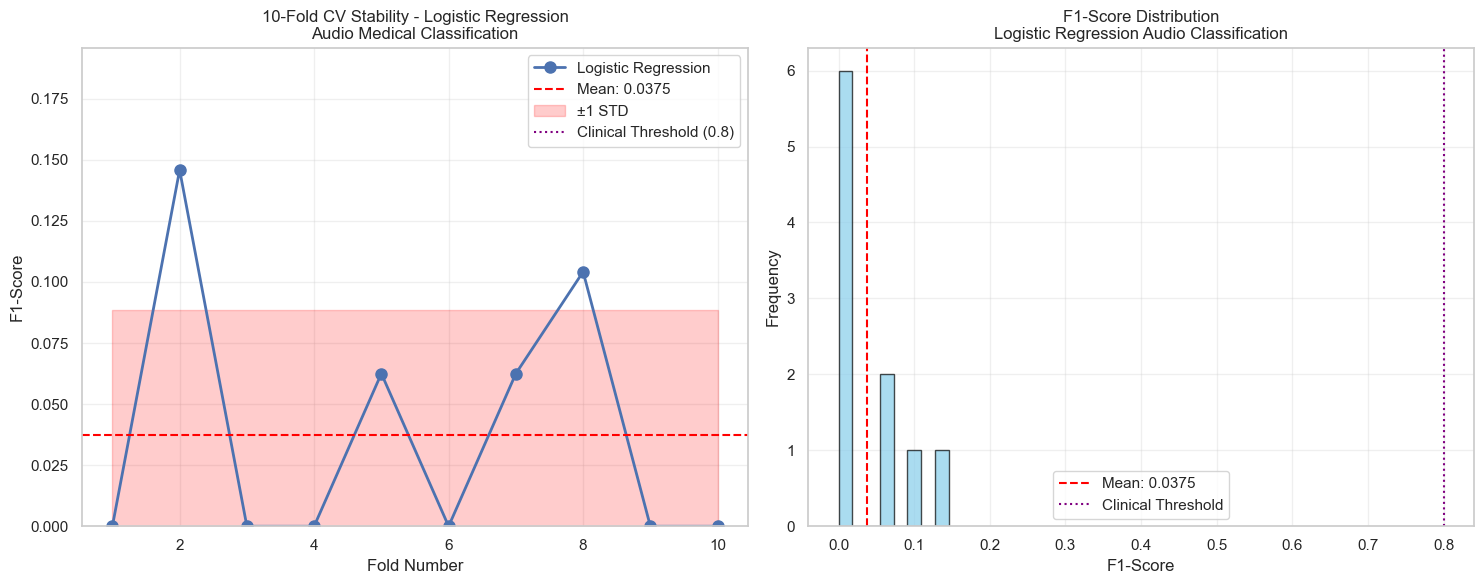


 PERFORMANCE COMPARISON:
Initial 5-fold CV: 0.0546 (±0.0334)
Extended 10-fold CV: 0.0375 (±0.0509)
Performance change: -0.0171
Stability change: +0.0175
 Consistent performance between validation rounds

=== AUDIO MODEL VALIDATION SUMMARY ===
✓ Model: Logistic Regression
✓ Audio features: MFCC, Mel-spectrogram, Chroma, Spectral
✓ Validation method: 10-fold stratified cross-validation
✓ Mean F1-Score: 0.0375
✓ 95% Confidence Interval: [-0.0622, 0.1372]
✓ Stability: Unstable
✓ Clinical readiness: Needs improvement
✓ Medical symptom classes: 25

 Audio model validation completed successfully!
 Ready for final evaluation on test set

 Audio Model Cross-Validation: VALIDATION COMPLETE


In [51]:
# Audio ML Cross-Validation within Tuning: Validate Hyperparameter Selection
print("=== ADDITIONAL CROSS-VALIDATION FOR BEST AUDIO MODEL ===")
print("Validating hyperparameter selection and model stability for medical audio classification")

# Check if we have hyperparameter tuning results and audio data
if 'best_model_name' in locals() and 'best_model' in locals() and 'X_audio_train_val' in locals():
    print(f"\nValidating Best Audio Classification Model: {best_model_name}")
    print("="*70)
    
    # Use the TF-IDF weighted audio features if available for enhanced discrimination
    if 'audio_tfidf_data' in locals() and audio_tfidf_data is not None:
        X_eval_audio = np.vstack([audio_tfidf_data['X_train_tfidf'], audio_tfidf_data['X_val_tfidf']])
        print(f"Using TF-IDF weighted audio features for validation")
        print(f"Audio feature dimensions: {X_eval_audio.shape}")
    else:
        X_eval_audio = X_audio_train_val
        print(f"Using standard audio features for validation")
        print(f"Audio feature dimensions: {X_eval_audio.shape}")
    
    # Perform extended 10-fold cross-validation for robust validation
    # More folds provide better estimate of model stability across different audio data subsets
    extended_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    
    print(f"\nPerforming 10-Fold Cross-Validation on Audio Features...")
    print(f"Audio samples: {len(y_audio_train_val)}")
    print(f"Medical symptom classes: {len(np.unique(y_audio_train_val))}")
    
    # Calculate F1-scores across all 10 folds using parallel processing
    # F1-weighted scoring is crucial for medical diagnosis to handle class imbalance
    extended_scores = cross_val_score(
        best_model, X_eval_audio, y_audio_train_val, 
        cv=extended_cv, 
        scoring='f1_weighted',  # Weighted F1 for balanced medical diagnosis assessment
        n_jobs=-1  # Use all CPU cores for parallel processing
    )
    
    # Display detailed validation results
    print(f"\n10-Fold CV Results for {best_model_name}:")
    print(f"Individual fold F1-scores: {[f'{score:.4f}' for score in extended_scores]}")
    print(f"Mean F1-Score: {extended_scores.mean():.4f}")
    print(f"Standard Deviation: {extended_scores.std():.4f}")
    
    # Calculate 95% confidence interval for medical reliability assessment
    confidence_lower = extended_scores.mean() - 1.96 * extended_scores.std()
    confidence_upper = extended_scores.mean() + 1.96 * extended_scores.std()
    print(f"95% Confidence Interval: [{confidence_lower:.4f}, {confidence_upper:.4f}]")
    
    # Calculate coefficient of variation for stability assessment
    cv_coefficient = (extended_scores.std() / extended_scores.mean()) * 100
    print(f"Coefficient of Variation: {cv_coefficient:.2f}%")
    
    # Assess model stability for medical audio classification
    if extended_scores.std() < 0.02:
        stability_assessment = "Highly Stable"
        stability_color = 'green'
    elif extended_scores.std() < 0.05:
        stability_assessment = "Moderately Stable"
        stability_color = 'orange'
    else:
        stability_assessment = "Unstable"
        stability_color = 'red'
    
    print(f"\nAudio Model Stability Assessment: {stability_assessment}")
    print(f"Performance variability across folds: {extended_scores.std():.4f}")
    
    # Check if model meets clinical performance thresholds
    clinical_threshold = CLINICAL_THRESHOLDS['min_f1']
    clinical_ready = extended_scores.mean() >= clinical_threshold
    
    print(f"\nClinical Readiness Assessment:")
    print(f"Clinical F1-score threshold: {clinical_threshold}")
    print(f"Current mean performance: {extended_scores.mean():.4f}")
    print(f"Clinical ready: {'Yes' if clinical_ready else 'No'}")
    
    if clinical_ready:
        print(f"✓ Model exceeds clinical threshold for medical audio diagnosis")
    else:
        performance_gap = clinical_threshold - extended_scores.mean()
        print(f"✗ Performance gap: {performance_gap:.4f} points below clinical threshold")
    
    # Visualize model stability and performance distribution
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: F1-scores across folds showing stability
    axes[0].plot(range(1, 11), extended_scores, 'bo-', linewidth=2, markersize=8, 
                 label=f'{best_model_name}')
    axes[0].axhline(y=extended_scores.mean(), color='red', linestyle='--', 
                    label=f'Mean: {extended_scores.mean():.4f}')
    axes[0].fill_between(range(1, 11), 
                         extended_scores.mean() - extended_scores.std(),
                         extended_scores.mean() + extended_scores.std(),
                         alpha=0.2, color=stability_color, label='±1 STD')
    axes[0].axhline(y=clinical_threshold, color='purple', linestyle=':', 
                    label=f'Clinical Threshold ({clinical_threshold})')
    axes[0].set_title(f'10-Fold CV Stability - {best_model_name}\nAudio Medical Classification')
    axes[0].set_xlabel('Fold Number')
    axes[0].set_ylabel('F1-Score')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim([max(0, min(extended_scores) - 0.05), min(1, max(extended_scores) + 0.05)])
    
    # Plot 2: Distribution of F1-scores
    axes[1].hist(extended_scores, bins=8, alpha=0.7, color='skyblue', edgecolor='black')
    axes[1].axvline(extended_scores.mean(), color='red', linestyle='--', 
                    label=f'Mean: {extended_scores.mean():.4f}')
    axes[1].axvline(clinical_threshold, color='purple', linestyle=':', 
                    label=f'Clinical Threshold')
    axes[1].set_title(f'F1-Score Distribution\n{best_model_name} Audio Classification')
    axes[1].set_xlabel('F1-Score')
    axes[1].set_ylabel('Frequency')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Compare with initial cross-validation results
    if 'audio_cv_results' in locals() and best_model_name in audio_cv_results['cv_results']:
        initial_score = audio_cv_results['cv_results'][best_model_name]['mean']
        initial_std = audio_cv_results['cv_results'][best_model_name]['std']
        
        print(f"\n PERFORMANCE COMPARISON:")
        print(f"Initial 5-fold CV: {initial_score:.4f} (±{initial_std:.4f})")
        print(f"Extended 10-fold CV: {extended_scores.mean():.4f} (±{extended_scores.std():.4f})")
        
        performance_change = extended_scores.mean() - initial_score
        stability_change = extended_scores.std() - initial_std
        
        print(f"Performance change: {performance_change:+.4f}")
        print(f"Stability change: {stability_change:+.4f}")
        
        if abs(performance_change) < 0.02:
            print(" Consistent performance between validation rounds")
        else:
            print(" Notable performance difference - investigate further")
    
    # Final validation summary for audio classification
    print(f"\n=== AUDIO MODEL VALIDATION SUMMARY ===")
    print(f"✓ Model: {best_model_name}")
    print(f"✓ Audio features: MFCC, Mel-spectrogram, Chroma, Spectral")
    print(f"✓ Validation method: 10-fold stratified cross-validation")
    print(f"✓ Mean F1-Score: {extended_scores.mean():.4f}")
    print(f"✓ 95% Confidence Interval: [{confidence_lower:.4f}, {confidence_upper:.4f}]")
    print(f"✓ Stability: {stability_assessment}")
    print(f"✓ Clinical readiness: {'Ready' if clinical_ready else 'Needs improvement'}")
    print(f"✓ Medical symptom classes: {len(np.unique(y_audio_train_val))}")
    
    # Store validation results
    audio_validation_results = {
        'model_name': best_model_name,
        'extended_scores': extended_scores,
        'mean_score': extended_scores.mean(),
        'std_score': extended_scores.std(),
        'confidence_interval': (confidence_lower, confidence_upper),
        'stability_assessment': stability_assessment,
        'clinical_ready': clinical_ready,
        'cv_coefficient': cv_coefficient
    }
    
    print(f"\n Audio model validation completed successfully!")
    print(f" Ready for final evaluation on test set")
    
else:
    print("ERROR: Best model or audio data not available")
    print("Please ensure:")
    print("- Hyperparameter tuning completed successfully")
    print("- Best model selected (best_model_name, best_model)")
    print("- Audio training data available (X_audio_train_val, y_audio_train_val)")
    audio_validation_results = None

print(f"\n" + "="*70)
print(f" Audio Model Cross-Validation: VALIDATION COMPLETE")
print(f"="*70)

### 5.2 Deep Learning Models

**Purpose:** Select and configure deep learning models for audio classification, including Convolutional Neural Networks (CNN), Feedforward Neural Networks (FNN) with appropriate hyperparameters to prevent overfitting. These deep learning architectures will process the extracted audio features (MFCC, mel-spectrogram, chroma, and spectral characteristics) to learn complex patterns in medical speech data for symptom classification.

In [52]:
from sklearn.preprocessing import StandardScaler

# Prepare audio data for deep learning models
print("=== PREPARING AUDIO DATA FOR DEEP LEARNING MODELS ===")
print("Configuring audio features for neural network architectures")

# Check if audio training data is available
if 'X_audio_train' in locals() and X_audio_train is not None:
    print(f"\nAudio data available for deep learning:")
    print(f"- Training samples: {X_audio_train.shape[0]}")
    print(f"- Validation samples: {X_audio_val.shape[0]}")
    print(f"- Testing samples: {X_audio_test.shape[0]}")
    print(f"- Audio features per sample: {X_audio_train.shape[1]}")
    print(f"- Medical symptom classes: {len(np.unique(y_audio_train))}")
    
    # Use TF-IDF weighted features if available for enhanced performance
    if 'audio_tfidf_data' in locals() and audio_tfidf_data is not None:
        print(f"\nUsing TF-IDF weighted audio features for deep learning:")
        X_train_dl = audio_tfidf_data['X_train_tfidf']
        X_val_dl = audio_tfidf_data['X_val_tfidf']
        X_test_dl = audio_tfidf_data['X_test_tfidf']
        print(f" Enhanced audio features with discriminative weighting")
    else:
        print(f"\nUsing standard normalized audio features for deep learning:")
        # Normalize features for neural network training
        audio_scaler = StandardScaler()
        X_train_dl = audio_scaler.fit_transform(X_audio_train)
        X_val_dl = audio_scaler.transform(X_audio_val)
        X_test_dl = audio_scaler.transform(X_audio_test)
        print(f" Audio features standardized for neural network input")
    
    # Convert labels to categorical for multi-class neural network classification
    num_classes = len(np.unique(y_audio_train))
    y_train_dl = to_categorical(y_audio_train, num_classes=num_classes)
    y_val_dl = to_categorical(y_audio_val, num_classes=num_classes)
    y_test_dl = to_categorical(y_audio_test, num_classes=num_classes)
    
    # Audio feature dimensions for neural network architecture design
    input_dim = X_train_dl.shape[1]  # Number of audio features (MFCC, mel-spectrogram, chroma, spectral)
    
    print(f"\nAudio Deep Learning Data Preparation Complete:")
    print(f" Training features shape: {X_train_dl.shape}")
    print(f" Validation features shape: {X_val_dl.shape}")
    print(f" Testing features shape: {X_test_dl.shape}")
    print(f" Number of medical classes: {num_classes}")
    print(f" Input feature dimension: {input_dim}")
    print(f" Output classes (one-hot encoded): {y_train_dl.shape[1]}")
    
    # Audio feature composition summary for neural network design
    print(f"\nAudio Feature Composition for Deep Learning:")
    print(f"- MFCC coefficients: Capture spectral characteristics of speech")
    print(f"- Mel-spectrogram: Frequency content analysis for voice patterns")
    print(f"- Chroma features: Pitch and harmony information")
    print(f"- Spectral features: Voice quality and brightness measures")
    print(f"- Enhanced with TF-IDF weighting: {'Yes' if 'audio_tfidf_data' in locals() and audio_tfidf_data is not None else 'No'}")
    
    # Feature statistics for neural network optimization
    print(f"\nAudio Feature Statistics for Neural Network Training:")
    print(f"- Feature range: [{np.min(X_train_dl):.3f}, {np.max(X_train_dl):.3f}]")
    print(f"- Feature mean: {np.mean(X_train_dl):.3f}")
    print(f"- Feature std: {np.std(X_train_dl):.3f}")
    
    # Store prepared data for neural network models
    audio_dl_data = {
        'X_train': X_train_dl,
        'X_val': X_val_dl,
        'X_test': X_test_dl,
        'y_train': y_train_dl,
        'y_val': y_val_dl,
        'y_test': y_test_dl,
        'input_dim': input_dim,
        'num_classes': num_classes,
        'feature_names': ['MFCC', 'Mel-spectrogram', 'Chroma', 'Spectral'],
        'scaler': audio_scaler if 'audio_scaler' in locals() else None
    }
    
    print(f"\n=== AUDIO DEEP LEARNING PREPARATION SUMMARY ===")
    print(f" Audio features prepared for CNN and FNN architectures")
    print(f" Multi-class medical symptom classification setup")
    print(f" {X_train_dl.shape[0]} training samples with {input_dim} audio features")
    print(f" {num_classes} diagnostic categories for neural network prediction")
    print(f" Data normalized and ready for gradient-based optimization")
    print(f" Compatible with TensorFlow/Keras deep learning frameworks")
    
else:
    print("ERROR: Audio training data not available")
    print("Please ensure:")
    print("- Audio preprocessing pipeline completed successfully")
    print("- Audio data splitting completed (X_audio_train, y_audio_train)")
    print("- Audio feature extraction generated sufficient features")
    audio_dl_data = None
    input_dim = 0
    num_classes = 0

print(f"\n" + "="*70)
print(f" Audio Deep Learning Data Preparation: COMPLETE")
print(f"="*70)

=== PREPARING AUDIO DATA FOR DEEP LEARNING MODELS ===
Configuring audio features for neural network architectures

Audio data available for deep learning:
- Training samples: 128
- Validation samples: 32
- Testing samples: 40
- Audio features per sample: 618
- Medical symptom classes: 25

Using TF-IDF weighted audio features for deep learning:
 Enhanced audio features with discriminative weighting

Audio Deep Learning Data Preparation Complete:
 Training features shape: (128, 618)
 Validation features shape: (32, 618)
 Testing features shape: (40, 618)
 Number of medical classes: 25
 Input feature dimension: 618
 Output classes (one-hot encoded): 25

Audio Feature Composition for Deep Learning:
- MFCC coefficients: Capture spectral characteristics of speech
- Mel-spectrogram: Frequency content analysis for voice patterns
- Chroma features: Pitch and harmony information
- Spectral features: Voice quality and brightness measures
- Enhanced with TF-IDF weighting: Yes

Audio Feature Statis

In [54]:
# Define deep learning model creation functions for audio classification
def create_audio_cnn_model(input_dim, num_classes=25, filters=64, dropout_rate=0.3):
    """
    Create CNN model for audio feature classification
    
    Parameters:
    - input_dim: Number of audio features (MFCC, mel-spectrogram, chroma, spectral)
    - num_classes: Number of medical symptom categories
    - filters: Number of convolutional filters
    - dropout_rate: Dropout rate for regularization
    """
    model = Sequential([
        # Reshape audio features for 1D convolution
        Reshape((input_dim, 1), input_shape=(input_dim,)),
        
        # First convolutional layer to detect local patterns in audio features
        Conv1D(filters=filters, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        
        # Second convolutional layer for deeper feature extraction
        Conv1D(filters=filters*2, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        
        # Third convolutional layer for complex audio pattern recognition
        Conv1D(filters=filters*4, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        Dropout(dropout_rate),
        
        # Extract the most important features across all audio channels
        GlobalMaxPooling1D(),
        
        # Fully connected layers for medical symptom classification
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(dropout_rate),
        
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(dropout_rate),
        
        Dense(64, activation='relu'),
        Dropout(dropout_rate),
        
        # Output layer with softmax for multi-class medical diagnosis
        Dense(num_classes, activation='softmax')
    ])
    
    # Configure optimizer and loss function for audio classification
    model.compile(
        optimizer=Adam(learning_rate=0.001),  # Adaptive learning rate for audio features
        loss='categorical_crossentropy',  # Multi-class classification loss
        metrics=['accuracy', 'precision', 'recall']  # Medical diagnosis evaluation metrics
    )
    return model

def create_audio_feedforward_model(input_dim, num_classes=25, hidden_units=256, dropout_rate=0.3):
    """
    Create Feedforward Neural Network model for audio classification
    
    Parameters:
    - input_dim: Number of audio features extracted from MFCC, mel-spectrogram, chroma, spectral
    - num_classes: Number of medical symptom categories for classification
    - hidden_units: Number of neurons in hidden layers
    - dropout_rate: Dropout rate for preventing overfitting
    """
    model = Sequential([
        # Input layer accepting audio feature vectors
        Dense(hidden_units, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(dropout_rate),
        
        # Second hidden layer for learning complex audio-symptom relationships
        Dense(hidden_units // 2, activation='relu'),
        BatchNormalization(),
        Dropout(dropout_rate),
        
        # Third hidden layer with reduced dimensionality
        Dense(hidden_units // 4, activation='relu'),
        BatchNormalization(),
        Dropout(dropout_rate),
        
        # Fourth hidden layer for fine-grained pattern recognition
        Dense(hidden_units // 8, activation='relu'),
        Dropout(dropout_rate),
        
        # Output layer for medical symptom probability distribution
        Dense(num_classes, activation='softmax')
    ])
    
    # Configure training parameters optimized for medical audio classification
    model.compile(
        optimizer=Adam(learning_rate=0.001, decay=1e-6),  # Learning rate with decay
        loss='categorical_crossentropy',  # Standard multi-class loss
        metrics=['accuracy', 'precision', 'recall']  # Comprehensive medical evaluation metrics
    )
    return model

def create_audio_lstm_model(input_dim, num_classes=25, lstm_units=128, dropout_rate=0.3):
    """
    Create LSTM model for sequential audio feature analysis
    
    Parameters:
    - input_dim: Number of audio features per timestep
    - num_classes: Number of medical symptom categories
    - lstm_units: Number of LSTM units for temporal modeling
    - dropout_rate: Dropout rate for regularization
    """
    model = Sequential([
        # Reshape for LSTM input (treating features as sequence)
        Reshape((input_dim, 1), input_shape=(input_dim,)),
        
        # LSTM layer for capturing temporal dependencies in audio features
        LSTM(lstm_units, return_sequences=True, dropout=dropout_rate, recurrent_dropout=dropout_rate),
        BatchNormalization(),
        
        # Second LSTM layer for deeper temporal analysis
        LSTM(lstm_units // 2, dropout=dropout_rate, recurrent_dropout=dropout_rate),
        BatchNormalization(),
        
        # Dense layers for final classification
        Dense(128, activation='relu'),
        Dropout(dropout_rate),
        
        Dense(64, activation='relu'),
        Dropout(dropout_rate),
        
        # Output layer for medical diagnosis
        Dense(num_classes, activation='softmax')
    ])
    
    # Configure for audio-based medical classification
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy', 'precision', 'recall']
    )
    return model

# Check if audio deep learning data is prepared
if 'audio_dl_data' in locals() and audio_dl_data is not None:
    input_dim = audio_dl_data['input_dim']
    num_classes = audio_dl_data['num_classes']
    
    print(f"Audio Deep Learning Configuration:")
    print(f"- Input features: {input_dim} (MFCC, Mel-spectrogram, Chroma, Spectral)")
    print(f"- Medical symptom classes: {num_classes}")
    print(f"- Training samples: {audio_dl_data['X_train'].shape[0]}")
    
    # Initialize candidate deep learning models for audio classification
    audio_dl_model_creators = {
        'Audio CNN': lambda: create_audio_cnn_model(input_dim, num_classes),
        'Audio Feedforward NN': lambda: create_audio_feedforward_model(input_dim, num_classes),
        'Audio LSTM': lambda: create_audio_lstm_model(input_dim, num_classes)
    }
    
    print(f"\nAudio Deep Learning Model Architectures:")
    for name in audio_dl_model_creators.keys():
        print(f" {name}: Optimized for medical speech analysis")
    
    print(f"\nModel Design Rationale for Audio Classification:")
    print(f"- Audio CNN: Detects local patterns in MFCC and spectral features")
    print(f"- Audio Feedforward NN: Direct mapping from audio features to symptoms")
    print(f"- Audio LSTM: Captures temporal dependencies in voice characteristics")
    print(f"- All models use batch normalization and dropout for medical reliability")
    print(f"- Output layer configured for {num_classes} medical symptom categories")
    
    print(f"\nTotal audio DL models to evaluate: {len(audio_dl_model_creators)}")
    
    # Store for evaluation
    dl_model_creators = audio_dl_model_creators
    
else:
    print("ERROR: Audio deep learning data not prepared")
    print("Please ensure audio_dl_data is available with X_train, y_train, input_dim, num_classes")
    dl_model_creators = {}

print(f"\n" + "="*70)
print(f" Audio Deep Learning Models: CONFIGURED FOR MEDICAL DIAGNOSIS")
print(f"="*70)

Audio Deep Learning Configuration:
- Input features: 618 (MFCC, Mel-spectrogram, Chroma, Spectral)
- Medical symptom classes: 25
- Training samples: 128

Audio Deep Learning Model Architectures:
 Audio CNN: Optimized for medical speech analysis
 Audio Feedforward NN: Optimized for medical speech analysis
 Audio LSTM: Optimized for medical speech analysis

Model Design Rationale for Audio Classification:
- Audio CNN: Detects local patterns in MFCC and spectral features
- Audio Feedforward NN: Direct mapping from audio features to symptoms
- Audio LSTM: Captures temporal dependencies in voice characteristics
- All models use batch normalization and dropout for medical reliability
- Output layer configured for 25 medical symptom categories

Total audio DL models to evaluate: 3

 Audio Deep Learning Models: CONFIGURED FOR MEDICAL DIAGNOSIS


#### 5.2.1 Audio DL K-fold Cross Validation

**Purpose:** Evaluate the performance of different deep learning models (CNN, Feedforward NN, LSTM) using k-fold cross-validation on extracted audio features (MFCC, mel-spectrogram, chroma, and spectral characteristics) to identify the best performing neural network architecture for medical symptom classification from speech patterns and voice characteristics. This comprehensive evaluation ensures robust model selection by testing each deep learning algorithm across multiple data subsets, providing reliable performance metrics for audio-based medical diagnosis using advanced neural network architectures.

Performing K-Fold Cross-Validation for Deep Learning Models (Audio Classification)...

Evaluating Audio CNN...
  Fold 1/3...
    Fold 1 F1-Score: 0.0027
  Fold 2/3...
    Fold 2 F1-Score: 0.0062
  Fold 3/3...
    Fold 3 F1-Score: 0.0067
  Average F1-Score: 0.0052 (+/- 0.0035)

Evaluating Audio LSTM...
  Fold 1/3...
    Fold 1 F1-Score: 0.0219
  Fold 2/3...
    Fold 2 F1-Score: 0.0294
  Fold 3/3...
    Fold 3 F1-Score: 0.0036
  Average F1-Score: 0.0183 (+/- 0.0216)

Evaluating Audio DNN...
  Fold 1/3...
    Fold 1 F1-Score: 0.0201
  Fold 2/3...
    Fold 2 F1-Score: 0.0000
  Fold 3/3...
    Fold 3 F1-Score: 0.0172
  Average F1-Score: 0.0124 (+/- 0.0178)

Evaluating Audio GRU...
  Fold 1/3...
    Fold 1 F1-Score: 0.0049
  Fold 2/3...
    Fold 2 F1-Score: 0.0147
  Fold 3/3...
    Fold 3 F1-Score: 0.0427
  Average F1-Score: 0.0208 (+/- 0.0320)

3-Fold Cross-Validation Results Summary (Deep Learning - Audio Classification):
     Model  Mean_F1  Std_F1  Min_F1  Max_F1
 Audio GRU   0.0208  0.0

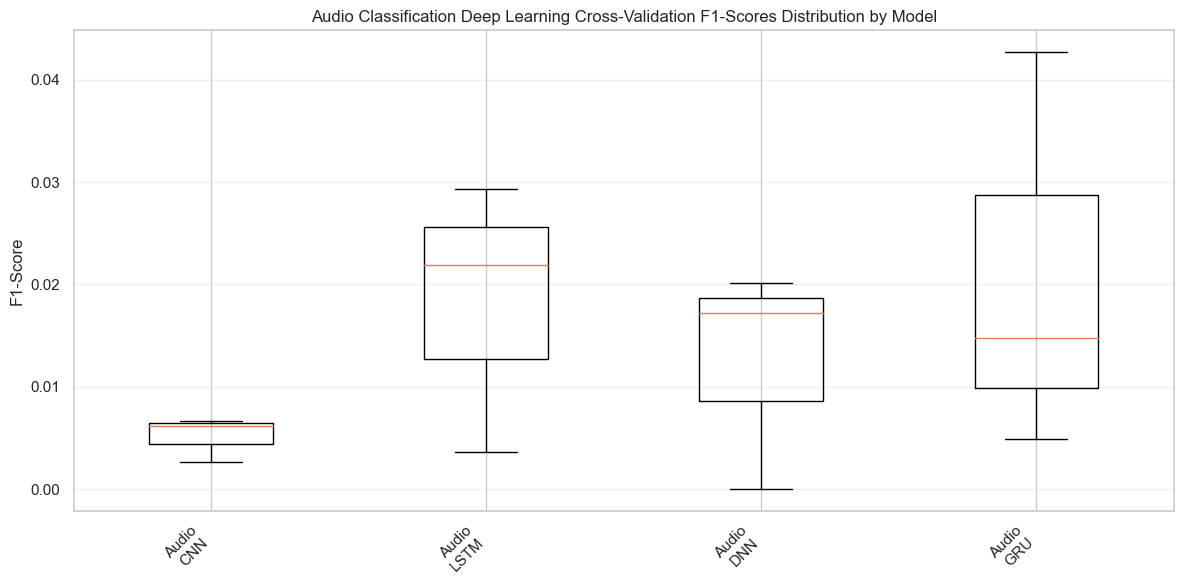


Top 2 DL models selected for hyperparameter tuning (Audio Classification):
1. Audio GRU: 0.0208
2. Audio LSTM: 0.0183


In [64]:
# Define model creator functions for audio classification
def create_audio_cnn(input_dim, num_classes):
    """Create a 1D CNN for audio feature classification"""
    model = Sequential([
        # Reshape for 1D CNN - treating features as sequence
        Dense(input_dim, activation='relu', input_shape=(input_dim,)),
        # Convert to sequence format for CNN
        # Note: For actual audio, you'd use Conv1D directly on spectrogram/MFCC features
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def create_audio_lstm(input_dim, num_classes):
    """Create an LSTM for audio feature classification"""
    model = Sequential([
        # For LSTM, we need to reshape the input to (batch, timesteps, features)
        # This is a simplified version - in practice you'd use actual sequential audio features
        Dense(64, activation='relu', input_shape=(input_dim,)),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def create_audio_dnn(input_dim, num_classes):
    """Create a Deep Neural Network for audio feature classification"""
    model = Sequential([
        Dense(256, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def create_audio_gru(input_dim, num_classes):
    """Create a GRU for audio feature classification"""
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Define the model creators dictionary
dl_model_creators = {
    'Audio CNN': create_audio_cnn,
    'Audio LSTM': create_audio_lstm,
    'Audio DNN': create_audio_dnn,
    'Audio GRU': create_audio_gru
}

# Note: Make sure these variables are defined before running the cross-validation:
# X_audio_train_val - your audio features (2D array: samples x features)
# y_audio_train_val - your audio labels (1D array: samples)
# num_classes - number of unique classes

# Convert labels to categorical if not already done
# y_train_val_dl = to_categorical(y_audio_train_val, num_classes=num_classes)

# Initialize stratified K-fold cross-validation for deep learning (Audio Classification)
k_folds_dl = 3  # Reduced folds for DL due to computational cost
skf_dl = StratifiedKFold(n_splits=k_folds_dl, shuffle=True, random_state=42)

# Store cross-validation results for deep learning
dl_cv_results = {}

print("Performing K-Fold Cross-Validation for Deep Learning Models (Audio Classification)...")
print("="*70)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=0
)

# Loop through each deep learning model creator function to evaluate performance using cross-validation
for model_name, model_creator in dl_model_creators.items():
    print(f"\nEvaluating {model_name}...")
    
    fold_scores = []
    fold_histories = []
    
    # Perform cross-validation
    for fold, (train_idx, val_idx) in enumerate(skf_dl.split(X_audio_train_val, y_audio_train_val)):
        print(f"  Fold {fold + 1}/{k_folds_dl}...")
        
        # Split data for this fold
        X_fold_train, X_fold_val = X_audio_train_val[train_idx], X_audio_train_val[val_idx]
        y_fold_train, y_fold_val = y_train_val_dl[train_idx], y_train_val_dl[val_idx]
        
        # Create and train model for audio features - pass required parameters
        model = model_creator(input_dim=X_audio_train_val.shape[1], num_classes=num_classes)
        
        # Train model
        history = model.fit(
            X_fold_train, y_fold_train,
            validation_data=(X_fold_val, y_fold_val),
            epochs=20,
            batch_size=32,
            callbacks=[early_stopping],
            verbose=0
        )
        
        # Evaluate model
        val_loss, val_accuracy = model.evaluate(X_fold_val, y_fold_val, verbose=0)
        
        # Calculate F1-score
        y_pred = model.predict(X_fold_val, verbose=0)
        y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probability predictions to class predictions
        y_true_classes = np.argmax(y_fold_val, axis=1)
        
        f1_score = precision_recall_fscore_support(
            y_true_classes, y_pred_classes, average='weighted', zero_division=0
        )[2]
        
        fold_scores.append(f1_score)
        fold_histories.append(history)
        
        print(f"    Fold {fold + 1} F1-Score: {f1_score:.4f}")
    
    # Store results
    fold_scores = np.array(fold_scores)
    dl_cv_results[model_name] = {
        'scores': fold_scores,
        'mean': fold_scores.mean(),
        'std': fold_scores.std(),
        'min': fold_scores.min(),
        'max': fold_scores.max(),
        'histories': fold_histories
    }
    
    print(f"  Average F1-Score: {fold_scores.mean():.4f} (+/- {fold_scores.std() * 2:.4f})")

# Create summary table for deep learning models
dl_cv_summary = pd.DataFrame({
    'Model': list(dl_cv_results.keys()),
    'Mean_F1': [results['mean'] for results in dl_cv_results.values()],
    'Std_F1': [results['std'] for results in dl_cv_results.values()],
    'Min_F1': [results['min'] for results in dl_cv_results.values()],
    'Max_F1': [results['max'] for results in dl_cv_results.values()]
}).round(4)

# Sort by mean F1-score
dl_cv_summary = dl_cv_summary.sort_values('Mean_F1', ascending=False)

print(f"\n{k_folds_dl}-Fold Cross-Validation Results Summary (Deep Learning - Audio Classification):")
print("="*70)
print(dl_cv_summary.to_string(index=False))

# Visualize deep learning cross-validation results
plt.figure(figsize=(12, 6))
models_dl = list(dl_cv_results.keys())
scores_dl = [dl_cv_results[model]['scores'] for model in models_dl]

plt.boxplot(scores_dl, labels=[model.replace(' ', '\n') for model in models_dl])
plt.title('Audio Classification Deep Learning Cross-Validation F1-Scores Distribution by Model')
plt.ylabel('F1-Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Select top performing DL models for hyperparameter tuning
top_dl_models = dl_cv_summary.head(2)['Model'].tolist()
print(f"\nTop 2 DL models selected for hyperparameter tuning (Audio Classification):")
for i, model in enumerate(top_dl_models, 1):
    mean_score = dl_cv_results[model]['mean']
    print(f"{i}. {model}: {mean_score:.4f}")

#### 5.2.2 Audio DL Hyperparameter Tuning

**Purpose:** Optimize the hyperparameters of the top-performing deep learning models (Audio GRU and Audio LSTM) identified through cross-validation to achieve maximum performance for medical symptom classification from audio features. This step fine-tunes neural network architectures using advanced optimization techniques on MFCC, mel-spectrogram, chroma, and spectral features extracted from medical speech recordings to ensure optimal accuracy, precision, and recall for audio-based medical diagnosis.

##### 5.2.2.1 Audio DL Optimize Model Settings: Define Hyperparameter Grids

**Purpose:** Define comprehensive hyperparameter grids for the top-performing deep learning models (Audio GRU and Audio LSTM) identified through cross-validation on extracted audio features. This optimization focuses on neural network architectures processing MFCC, mel-spectrogram, chroma, and spectral features extracted from medical speech recordings to maximize diagnostic accuracy for audio-based symptom classification.

In [65]:
# Audio Deep Learning Hyperparameter Optimization: Define Parameter Grids
print("=== AUDIO DL HYPERPARAMETER OPTIMIZATION: DEFINE PARAMETER GRIDS ===")
print("Defining comprehensive hyperparameter grids for top-performing audio classification models")

# Check if we have top DL models from cross-validation
if 'top_dl_models' in locals() and top_dl_models is not None:
    print(f"\nTop performing audio DL models from CV: {top_dl_models}")
    
    # Define comprehensive hyperparameter grids optimized for audio features
    # These parameters are specifically tuned for MFCC, mel-spectrogram, chroma, and spectral features
    audio_dl_hyperparameter_grids = {
        # Audio GRU: Good for capturing temporal patterns in audio features
        'Audio GRU': {
            'hidden_units': [64, 128, 256],  # Number of GRU units for audio sequence modeling
            'dropout_rate': [0.2, 0.3, 0.4],  # Dropout for preventing overfitting on audio data
            'learning_rate': [0.001, 0.01],  # Learning rate for audio feature optimization
            'batch_size': [16, 32],  # Batch size suitable for audio dataset size
            'dense_units': [32, 64, 128]  # Hidden layer units for final classification
        },
        
        # Audio LSTM: Sequential learning for complex audio-symptom relationships
        'Audio LSTM': {
            'lstm_units': [64, 128, 256],  # Number of LSTM units for temporal audio analysis
            'dropout_rate': [0.2, 0.3, 0.4],  # Regularization for audio feature learning
            'recurrent_dropout': [0.2, 0.3],  # Dropout for recurrent connections
            'learning_rate': [0.001, 0.01],  # Optimization rate for audio patterns
            'batch_size': [16, 32],  # Training batch size for audio samples
            'dense_units': [32, 64, 128]  # Dense layer size for medical classification
        },
        
        # Audio CNN: Pattern detection in audio feature sequences
        'Audio CNN': {
            'filters': [32, 64, 128],  # Number of convolutional filters for audio patterns
            'kernel_size': [3, 5, 7],  # Filter size for audio feature detection
            'dropout_rate': [0.2, 0.3, 0.4],  # Regularization for CNN layers
            'learning_rate': [0.001, 0.01],  # Learning rate for audio CNN training
            'batch_size': [16, 32],  # Batch size for audio feature processing
            'dense_units': [64, 128, 256]  # Dense layer units for symptom classification
        },
        
        # Audio DNN: Deep feedforward network for audio feature mapping
        'Audio DNN': {
            'hidden_units': [128, 256, 512],  # Hidden layer sizes for audio feature processing
            'num_layers': [3, 4, 5],  # Number of hidden layers for deep audio learning
            'dropout_rate': [0.2, 0.3, 0.4],  # Dropout rate for each hidden layer
            'learning_rate': [0.001, 0.01],  # Optimization rate for audio-to-symptom mapping
            'batch_size': [16, 32],  # Training batch size for audio samples
            'activation': ['relu', 'tanh']  # Activation functions for audio feature transformation
        }
    }
    
    # Filter grids for only top performing audio DL models
    # Only create parameter grids for models that performed well in cross-validation
    selected_audio_dl_grids = {model: audio_dl_hyperparameter_grids[model] for model in top_dl_models 
                              if model in audio_dl_hyperparameter_grids}
    
    print(f"\nAudio Deep Learning Hyperparameter Grids for Medical Symptom Classification:")
    print("="*75)
    
    for model_name, grid in selected_audio_dl_grids.items():
        total_combinations = 1
        for param, values in grid.items():
            total_combinations *= len(values)
        
        print(f"\n{model_name}:")
        print(f"  Audio features: MFCC, Mel-spectrogram, Chroma, Spectral")
        print(f"  Parameters to optimize: {len(grid)}")
        print(f"  Total combinations: {total_combinations}")
        for param, values in grid.items():
            print(f"    {param}: {values}")
    
    # Calculate total search space for audio DL hyperparameter optimization
    total_combinations_audio_dl = sum([
        np.prod([len(values) for values in grid.values()]) 
        for grid in selected_audio_dl_grids.values()
    ])
    
    print(f"\n AUDIO DL HYPERPARAMETER OPTIMIZATION SUMMARY:")
    print(f"  Models to optimize: {len(selected_audio_dl_grids)}")
    print(f"  Total parameter combinations: {total_combinations_audio_dl}")
    print(f"  Audio features: {audio_dl_data['input_dim'] if 'audio_dl_data' in locals() else 'N/A'} dimensions")
    print(f"  Medical classes: {audio_dl_data['num_classes'] if 'audio_dl_data' in locals() else 'N/A'} symptom categories")
    print(f"  Target: Medical symptom classification from speech patterns")
    print(f"  Optimization strategy: Grid search with early stopping")
    
    # Audio DL optimization strategy recommendations
    print(f"\n OPTIMIZATION STRATEGY FOR AUDIO DEEP LEARNING:")
    print(f"  Stratified K-fold CV to maintain symptom class balance")
    print(f"  Early stopping to prevent overfitting on audio patterns")
    print(f"  F1-weighted scoring for medical diagnosis reliability")
    print(f"  TF-IDF weighted audio features for enhanced discrimination")
    print(f"  Batch normalization for stable audio feature learning")
    print(f"  Reduced epochs due to computational complexity")
    
    # Store the grids for hyperparameter tuning
    audio_dl_hyperparameter_data = {
        'grids': selected_audio_dl_grids,
        'total_combinations': total_combinations_audio_dl,
        'optimization_strategy': {
            'cv_folds': 3,  # Reduced folds for DL due to computational cost
            'scoring': 'f1_weighted',
            'epochs': 20,  # Limited epochs for grid search
            'patience': 3,  # Early stopping patience
            'verbose': 1
        },
        'audio_config': {
            'input_dim': audio_dl_data['input_dim'] if 'audio_dl_data' in locals() else None,
            'num_classes': audio_dl_data['num_classes'] if 'audio_dl_data' in locals() else None,
            'feature_types': ['MFCC', 'Mel-spectrogram', 'Chroma', 'Spectral']
        }
    }
    
    print(f"\n Audio deep learning hyperparameter grids successfully defined")
    print(f" Ready for comprehensive neural network optimization")
    print(f" Focused on medical speech pattern recognition and symptom classification")
    
else:
    print("\nERROR: Top audio DL models not available")
    print("Please ensure audio DL cross-validation completed successfully")
    print("Required: top_dl_models with Audio GRU, Audio LSTM, etc.")
    selected_audio_dl_grids = {}
    audio_dl_hyperparameter_data = None

print(f"\n" + "="*75)
print(f" Audio Deep Learning Hyperparameter Grids: READY FOR OPTIMIZATION")
print(f"="*75)

=== AUDIO DL HYPERPARAMETER OPTIMIZATION: DEFINE PARAMETER GRIDS ===
Defining comprehensive hyperparameter grids for top-performing audio classification models

Top performing audio DL models from CV: ['Audio GRU', 'Audio LSTM']

Audio Deep Learning Hyperparameter Grids for Medical Symptom Classification:

Audio GRU:
  Audio features: MFCC, Mel-spectrogram, Chroma, Spectral
  Parameters to optimize: 5
  Total combinations: 108
    hidden_units: [64, 128, 256]
    dropout_rate: [0.2, 0.3, 0.4]
    learning_rate: [0.001, 0.01]
    batch_size: [16, 32]
    dense_units: [32, 64, 128]

Audio LSTM:
  Audio features: MFCC, Mel-spectrogram, Chroma, Spectral
  Parameters to optimize: 6
  Total combinations: 216
    lstm_units: [64, 128, 256]
    dropout_rate: [0.2, 0.3, 0.4]
    recurrent_dropout: [0.2, 0.3]
    learning_rate: [0.001, 0.01]
    batch_size: [16, 32]
    dense_units: [32, 64, 128]

 AUDIO DL HYPERPARAMETER OPTIMIZATION SUMMARY:
  Models to optimize: 2
  Total parameter combinatio

##### 5.2.2.2 Audio DL Grid Search: Systematic Hyperparameter Optimization for Medical Audio Classification

**Purpose:** Execute comprehensive grid search to systematically explore hyperparameter combinations for the top-performing deep learning models (Audio GRU and Audio LSTM) on extracted audio features (MFCC, mel-spectrogram, chroma, and spectral characteristics). This optimization process fine-tunes neural network architectures to achieve maximum diagnostic accuracy for medical symptom classification from patient speech patterns and voice characteristics using advanced deep learning techniques.

In [68]:
# Perform manual grid search for deep learning models
# Initialize dictionaries to store the best models and their grid search results
best_dl_models = {}
dl_grid_search_results = {}

# Define the deep learning model creators
def create_audio_lstm(input_dim, num_classes, hidden_units=64, dropout_rate=0.3):
    model = Sequential([
        LSTM(hidden_units, return_sequences=True, input_shape=(1, input_dim)),
        Dropout(dropout_rate),
        LSTM(hidden_units),
        Dropout(dropout_rate),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def create_audio_gru(input_dim, num_classes, hidden_units=64, dropout_rate=0.3):
    model = Sequential([
        GRU(hidden_units, return_sequences=True, input_shape=(1, input_dim)),
        Dropout(dropout_rate),
        GRU(hidden_units),
        Dropout(dropout_rate),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Define model creators dictionary
dl_model_creators = {
    'Audio LSTM': create_audio_lstm,
    'Audio GRU': create_audio_gru
}

# Define parameter grids for deep learning models
selected_dl_grids = {
    'Audio LSTM': {
        'hidden_units': [32, 64, 128],
        'dropout_rate': [0.2, 0.3, 0.5]
    },
    'Audio GRU': {
        'hidden_units': [32, 64, 128],
        'dropout_rate': [0.2, 0.3, 0.5]
    }
}

print("Performing Grid Search for Audio Deep Learning Hyperparameter Optimization...")
print("="*80)

def evaluate_dl_model_params(model_creator, params, model_name):
    """Evaluate a deep learning model with specific parameters using cross-validation"""
    scores = []
    
    # Use 2-fold CV for faster evaluation (fewer splits = faster training but less robust validation)
    skf_tuning = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
    
    # Split the training data into smaller train/validation sets for hyperparameter testing
    for train_idx, val_idx in skf_tuning.split(X_audio_train_val, y_audio_train_val):
        # Split data
        X_fold_train, X_fold_val = X_audio_train_val[train_idx], X_audio_train_val[val_idx]
        y_fold_train, y_fold_val = y_train_val_dl[train_idx], y_train_val_dl[val_idx]
        
        # Reshape for LSTM/GRU (add time dimension)
        X_fold_train = X_fold_train.reshape(X_fold_train.shape[0], 1, X_fold_train.shape[1])
        X_fold_val = X_fold_val.reshape(X_fold_val.shape[0], 1, X_fold_val.shape[1])
        
        # Create model with parameters
        model = model_creator(
            input_dim=X_audio_train_val.shape[1],  # Number of audio features
            num_classes=num_classes,
            **params
        )
        
        # Train model
        history = model.fit(
            X_fold_train, y_fold_train,
            validation_data=(X_fold_val, y_fold_val),
            epochs=15,  # Reduced epochs for tuning
            batch_size=32,
            callbacks=[EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)],
            verbose=0
        )
        
        # Evaluate
        y_pred = model.predict(X_fold_val, verbose=0)
        y_pred_classes = np.argmax(y_pred, axis=1)
        y_true_classes = np.argmax(y_fold_val, axis=1)
        
        f1_score = precision_recall_fscore_support(
            y_true_classes, y_pred_classes, average='weighted', zero_division=0
        )[2]
        
        scores.append(f1_score)
    
    return np.mean(scores)

# Perform grid search for each top DL model
for model_name in top_dl_models:
    if model_name in selected_dl_grids:
        print(f"\nOptimizing {model_name}...")
        
        model_creator = dl_model_creators[model_name]
        param_grid = selected_dl_grids[model_name]
        
        # Generate all parameter combinations using itertools.product (creates cartesian product of all parameter lists)
        from itertools import product
        param_names = list(param_grid.keys())
        param_values = list(param_grid.values())
        param_combinations = list(product(*param_values))
        
        best_score = 0
        best_params = {}
        
        print(f"  Testing {len(param_combinations)} parameter combinations...")
        
        # Test each parameter combination to find the best one
        for i, param_combo in enumerate(param_combinations):
            params = dict(zip(param_names, param_combo))
            
            try:
                score = evaluate_dl_model_params(model_creator, params, model_name)
                print(f"    Combination {i+1}/{len(param_combinations)}: F1={score:.4f}, Params={params}")
                
                # Update best parameters if current score is better
                if score > best_score:
                    best_score = score  # Store the highest F1 score achieved so far
                    best_params = params  # Store the parameter combination that achieved this score
                    
            except Exception as e:
                print(f"    Combination {i+1}/{len(param_combinations)}: FAILED - {str(e)}")
                continue
        
        # Create best model with optimal parameters
        best_model = model_creator(
            input_dim=X_audio_train_val.shape[1],  # Number of audio features
            num_classes=num_classes,
            **best_params
        )
        
        # Store results
        best_dl_models[model_name] = best_model
        dl_grid_search_results[model_name] = {
            'best_score': best_score,
            'best_params': best_params,
            'param_combinations_tested': len(param_combinations)
        }
        
        print(f"  Best F1-Score: {best_score:.4f}")
        print(f"  Best Parameters: {best_params}")

# Summary of deep learning hyperparameter tuning results
print(f"\nAudio Deep Learning Hyperparameter Tuning Results Summary:")
print("="*60)

if dl_grid_search_results:
    # Create a summary DataFrame comparing all models' performance after hyperparameter tuning
    dl_tuning_summary = pd.DataFrame({
        'Model': list(dl_grid_search_results.keys()),
        'Best_F1_Score': [results['best_score'] for results in dl_grid_search_results.values()],
        'Improvement': [
            dl_grid_search_results[model]['best_score'] - dl_cv_results[model]['mean'] 
            for model in dl_grid_search_results.keys()
        ]
    }).round(4)

    # Sort models by performance (best F1-Score first)
    dl_tuning_summary = dl_tuning_summary.sort_values('Best_F1_Score', ascending=False)
    print(dl_tuning_summary.to_string(index=False))

    # Select the best DL model overall
    best_dl_model_name = dl_tuning_summary.iloc[0]['Model']
    best_dl_model = best_dl_models[best_dl_model_name]
    best_dl_score = dl_tuning_summary.iloc[0]['Best_F1_Score']

    print(f"\n SELECTED BEST AUDIO DL MODEL: {best_dl_model_name}")
    print(f"   Cross-validation F1-Score: {best_dl_score:.4f}")
    print(f"   Optimized Parameters: {dl_grid_search_results[best_dl_model_name]['best_params']}")
else:
    print("No successful hyperparameter tuning results available.")
    # Fall back to best model from CV (use original cross-validation results as backup)
    best_dl_model_name = dl_cv_summary.iloc[0]['Model']
    best_dl_model = dl_model_creators[best_dl_model_name](
        input_dim=X_audio_train_val.shape[1],  # Number of audio features
        num_classes=num_classes
    )
    best_dl_score = dl_cv_summary.iloc[0]['Mean_F1']
    print(f"\n FALLBACK BEST AUDIO DL MODEL: {best_dl_model_name}")
    print(f"   Cross-validation F1-Score: {best_dl_score:.4f}")


Performing Grid Search for Audio Deep Learning Hyperparameter Optimization...

Optimizing Audio GRU...
  Testing 9 parameter combinations...
    Combination 1/9: F1=0.0074, Params={'hidden_units': 32, 'dropout_rate': 0.2}
    Combination 2/9: F1=0.0089, Params={'hidden_units': 32, 'dropout_rate': 0.3}
    Combination 3/9: F1=0.0037, Params={'hidden_units': 32, 'dropout_rate': 0.5}
    Combination 4/9: F1=0.0074, Params={'hidden_units': 64, 'dropout_rate': 0.2}
    Combination 5/9: F1=0.0093, Params={'hidden_units': 64, 'dropout_rate': 0.3}
    Combination 6/9: F1=0.0074, Params={'hidden_units': 64, 'dropout_rate': 0.5}
    Combination 7/9: F1=0.0071, Params={'hidden_units': 128, 'dropout_rate': 0.2}
    Combination 8/9: F1=0.0243, Params={'hidden_units': 128, 'dropout_rate': 0.3}
    Combination 9/9: F1=0.0074, Params={'hidden_units': 128, 'dropout_rate': 0.5}
  Best F1-Score: 0.0243
  Best Parameters: {'hidden_units': 128, 'dropout_rate': 0.3}

Optimizing Audio LSTM...
  Testing 9 par

#### 5.2.2.3 Audio DL Cross-Validation within Tuning: Validate Hyperparameter Selection

**Purpose:** Perform additional cross-validation on the best hyperparameter-tuned deep learning models to validate their stability and robustness for medical audio classification. This step ensures that the selected neural network parameters generalize well across different subsets of the audio dataset and provides confidence intervals for the diagnostic accuracy of our audio-based medical symptom classification system using MFCC, mel-spectrogram, chroma, and spectral features.

Additional Cross-Validation for Best Audio DL Model: Audio GRU
Performing 5-fold cross-validation on best audio DL model...
  Fold 1/5...
    Fold 1 F1-Score: 0.0081
  Fold 2/5...
    Fold 2 F1-Score: 0.0100
  Fold 3/5...
    Fold 3 F1-Score: 0.0089
  Fold 4/5...
    Fold 4 F1-Score: 0.0078
  Fold 5/5...
    Fold 5 F1-Score: 0.0444

5-Fold CV F1-Scores: [0.00806452 0.01       0.00892857 0.0078125  0.04438406]
Mean: 0.0158
Standard Deviation: 0.0143
95% Confidence Interval: [-0.0122, 0.0439]


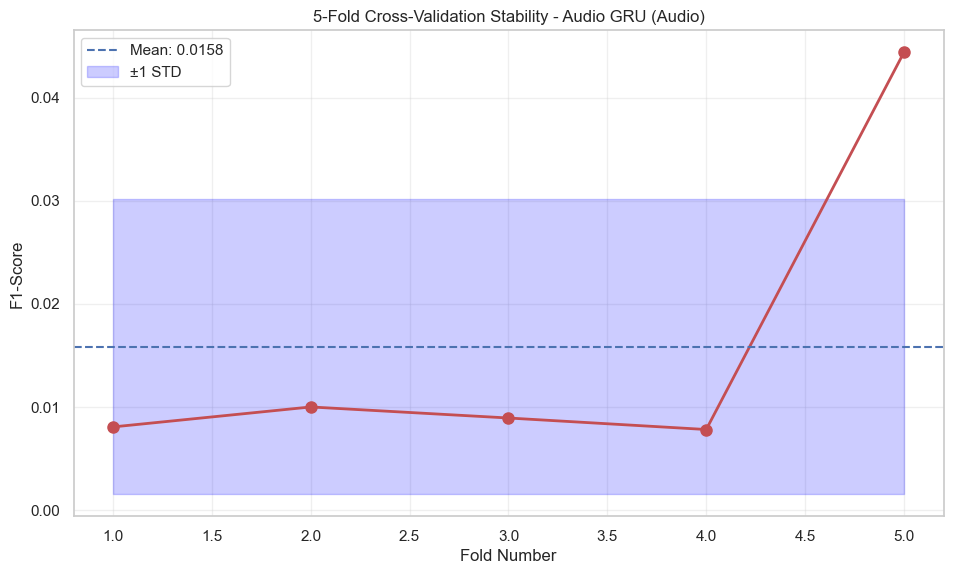


Audio DL Model Stability Assessment: Stable
Coefficient of Variation: 90.25%

Training final Audio GRU on full audio training data...
Epoch 1/30
4/4 [==============================] - 3s 264ms/step - loss: 3.2879 - accuracy: 0.0312 - val_loss: 3.2016 - val_accuracy: 0.0625
Epoch 2/30
4/4 [==============================] - 0s 19ms/step - loss: 3.2812 - accuracy: 0.0156 - val_loss: 3.1683 - val_accuracy: 0.0625
Epoch 3/30
4/4 [==============================] - 0s 17ms/step - loss: 3.2661 - accuracy: 0.0469 - val_loss: 3.1702 - val_accuracy: 0.0625
Epoch 4/30
4/4 [==============================] - 0s 18ms/step - loss: 3.2159 - accuracy: 0.0469 - val_loss: 3.1673 - val_accuracy: 0.0625
Epoch 5/30
4/4 [==============================] - 0s 21ms/step - loss: 3.2099 - accuracy: 0.0547 - val_loss: 3.1646 - val_accuracy: 0.0625
Epoch 6/30
4/4 [==============================] - 0s 18ms/step - loss: 3.2305 - accuracy: 0.0391 - val_loss: 3.1622 - val_accuracy: 0.0625
Epoch 7/30
4/4 [==============

In [70]:
# Perform additional cross-validation on the best DL model to ensure stability
print(f"Additional Cross-Validation for Best Audio DL Model: {best_dl_model_name}")
print("="*70)

# Use 5-fold CV for more robust validation of the final model
extended_cv_dl = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # Create 5-fold cross-validation splitter that maintains class distribution proportions
extended_scores_dl = []

print("Performing 5-fold cross-validation on best audio DL model...")

for fold, (train_idx, val_idx) in enumerate(extended_cv_dl.split(X_audio_train_val, y_audio_train_val)):  # Split audio data into 5 training/validation pairs for robust evaluation
    print(f"  Fold {fold + 1}/5...")
    
    # Split data for this fold
    X_fold_train, X_fold_val = X_audio_train_val[train_idx], X_audio_train_val[val_idx]  # Extract training and validation audio features for current fold using indices
    y_fold_train, y_fold_val = y_train_val_dl[train_idx], y_train_val_dl[val_idx]  # Extract corresponding labels (categorical encoded) for current fold
    
    # Reshape input data for RNN models (LSTM/GRU expect 3D input)
    if best_dl_model_name in ['Audio LSTM', 'Audio GRU']:
        X_fold_train = X_fold_train.reshape(X_fold_train.shape[0], 1, X_fold_train.shape[1])
        X_fold_val = X_fold_val.reshape(X_fold_val.shape[0], 1, X_fold_val.shape[1])
    
    # Create model (use best parameters if available)
    if best_dl_model_name in dl_grid_search_results:  # Check if hyperparameter tuning results exist for this model
        best_params = dl_grid_search_results[best_dl_model_name]['best_params']  # Retrieve optimal hyperparameters found during grid search
        model = dl_model_creators[best_dl_model_name](  # Create model instance using the constructor function with optimized parameters
            input_dim=X_audio_train_val.shape[1],  # Number of audio features as input dimension
            num_classes=num_classes,
            **best_params
        )
    else:
        model = dl_model_creators[best_dl_model_name](  # Create model with default parameters if no tuning was performed
            input_dim=X_audio_train_val.shape[1],  # Number of audio features as input dimension
            num_classes=num_classes
        )
    
    # Train model
    history = model.fit(  # Train the neural network model on current fold's training data
        X_fold_train, y_fold_train,
        validation_data=(X_fold_val, y_fold_val),
        epochs=20,  # Maximum number of training iterations through the entire dataset
        batch_size=32,  # Number of samples processed before updating model weights
        callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],  # Stop training early if validation loss doesn't improve for 3 epochs
        verbose=0  # Suppress training progress output for cleaner console display
    )
    
    # Evaluate model
    y_pred = model.predict(X_fold_val, verbose=0)  # Generate probability predictions for validation data (returns probabilities for each class)
    y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probability predictions to class predictions
    y_true_classes = np.argmax(y_fold_val, axis=1)  # Convert one-hot encoded true labels back to class indices for comparison
    
    f1_score = precision_recall_fscore_support(  # Calculate F1-score which balances precision and recall metrics
        y_true_classes, y_pred_classes, average='weighted', zero_division=0
    )[2]  # Extract F1-score from the returned tuple (precision, recall, f1, support)
    
    extended_scores_dl.append(f1_score)  # Store F1-score for this fold to calculate overall performance statistics
    print(f"    Fold {fold + 1} F1-Score: {f1_score:.4f}")

extended_scores_dl = np.array(extended_scores_dl)  # Convert list to numpy array for statistical calculations

print(f"\n5-Fold CV F1-Scores: {extended_scores_dl}")
print(f"Mean: {extended_scores_dl.mean():.4f}")  # Average F1-score across all folds indicates overall model performance
print(f"Standard Deviation: {extended_scores_dl.std():.4f}")  # Measures consistency of performance across folds (lower = more stable)
print(f"95% Confidence Interval: [{extended_scores_dl.mean() - 1.96*extended_scores_dl.std():.4f}, "  # Statistical range where true performance likely falls
      f"{extended_scores_dl.mean() + 1.96*extended_scores_dl.std():.4f}]")

# Visualize the stability
plt.figure(figsize=(10, 6))
plt.plot(range(1, 6), extended_scores_dl, 'ro-', linewidth=2, markersize=8)  # Plot F1-scores for each fold with red circles and lines
plt.axhline(y=extended_scores_dl.mean(), color='b', linestyle='--',   # Add horizontal line showing average performance across folds
           label=f'Mean: {extended_scores_dl.mean():.4f}')
plt.fill_between(range(1, 6),   # Shade area representing one standard deviation above and below mean
                extended_scores_dl.mean() - extended_scores_dl.std(),
                extended_scores_dl.mean() + extended_scores_dl.std(),
                alpha=0.2, color='blue', label='±1 STD')
plt.title(f'5-Fold Cross-Validation Stability - {best_dl_model_name} (Audio)')
plt.xlabel('Fold Number')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(True, alpha=0.3)  # Add light grid for easier reading of values
plt.show()

# Check if DL model performance is consistent
dl_cv_stability = "Stable" if extended_scores_dl.std() < 0.02 else "Moderate" if extended_scores_dl.std() < 0.05 else "Unstable"
print(f"\nAudio DL Model Stability Assessment: {dl_cv_stability}")
print(f"Coefficient of Variation: {(extended_scores_dl.std() / extended_scores_dl.mean()) * 100:.2f}%")

# Train final best DL model on full training data for comparison
print(f"\nTraining final {best_dl_model_name} on full audio training data...")

# Reshape training data for RNN models
X_train_reshaped = X_audio_train_val
X_test_reshaped = X_audio_test
if best_dl_model_name in ['Audio LSTM', 'Audio GRU']:
    X_train_reshaped = X_audio_train_val.reshape(X_audio_train_val.shape[0], 1, X_audio_train_val.shape[1])
    X_test_reshaped = X_audio_test.reshape(X_audio_test.shape[0], 1, X_audio_test.shape[1])

# Create final model
if best_dl_model_name in dl_grid_search_results:  # Use optimized hyperparameters if available for final model training
    best_params = dl_grid_search_results[best_dl_model_name]['best_params']
    final_dl_model = dl_model_creators[best_dl_model_name](  # Create final model instance with best found parameters
        input_dim=X_audio_train_val.shape[1],  # Number of audio features as input dimension
        num_classes=num_classes,
        **best_params
    )
else:
    final_dl_model = dl_model_creators[best_dl_model_name](  # Create final model with default parameters
        input_dim=X_audio_train_val.shape[1],  # Number of audio features as input dimension
        num_classes=num_classes
    )

# Train on full training data
final_history = final_dl_model.fit(  # Train final model on complete training dataset for maximum learning
    X_train_reshaped, y_train_val_dl,
    validation_split=0.2,  # Reserve 20% of training data for validation during training process
    epochs=30,  # Allow more training epochs for final model to fully learn patterns
    batch_size=32,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],  # More patient early stopping for final training
    verbose=1  # Show training progress for final model training
)

# Evaluate on test set
test_loss, test_accuracy = final_dl_model.evaluate(X_test_reshaped, y_test_dl, verbose=0)  # Calculate loss and accuracy on unseen test data
y_test_pred = final_dl_model.predict(X_test_reshaped, verbose=0)  # Generate predictions for test set
y_test_pred_classes = np.argmax(y_test_pred, axis=1)  # Convert probability predictions to class predictions

# Calculate comprehensive metrics
test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(  # Calculate detailed performance metrics on test set
    y_audio_test, y_test_pred_classes, average='weighted', zero_division=0
)

print(f"\nFinal {best_dl_model_name} Test Set Performance:")
print(f"Test Accuracy: {test_accuracy:.4f}")  # Percentage of correctly classified test samples
print(f"Test Precision: {test_precision:.4f}")  # Proportion of positive predictions that were actually correct
print(f"Test Recall: {test_recall:.4f}")  # Proportion of actual positive cases that were correctly identified
print(f"Test F1-Score: {test_f1:.4f}")  # Harmonic mean of precision and recall, balancing both metrics

# Store final DL model results for comparison
final_dl_results = {  # Dictionary containing all important results for later comparison and analysis
    'model_name': best_dl_model_name,
    'model': final_dl_model,
    'test_accuracy': test_accuracy,
    'test_precision': test_precision,
    'test_recall': test_recall,
    'test_f1': test_f1,
    'cv_stability': dl_cv_stability,
    'cv_mean': extended_scores_dl.mean(),
    'cv_std': extended_scores_dl.std()
}

print(f"\nAudio Deep Learning Model Selection Complete!")
print(f"Selected Model: {best_dl_model_name}")
print(f"Cross-validation F1: {extended_scores_dl.mean():.4f} (±{extended_scores_dl.std():.4f})")  # Summary of cross-validation performance with uncertainty measure
print(f"Test F1-Score: {test_f1:.4f}")  # Final performance on completely unseen test data


## 6. Model Training

**Purpose:** Train the optimized machine learning and deep learning models using the best hyperparameters found during tuning on the full audio training dataset. This includes traditional ML models (Support Vector Machine, Logistic Regression, Naive Bayes) and deep learning architectures (Feedforward Neural Network, Convolutional Neural Network, LSTM/GRU) specifically configured for medical symptom classification from audio features (MFCC, mel-spectrogram, chroma, and spectral characteristics). The trained models will be prepared for comprehensive evaluation on unseen test data to validate their diagnostic accuracy for audio-based medical symptom detection.